<a href="https://colab.research.google.com/github/joyhwp/lg_multimodal_cej_analysis/blob/main/02_eda_cej_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# CEJ_stage별 언급(행) 수 확인
cej_stage_counts = text_df['CEJ_stage'].value_counts(dropna=False)
cej_stage_ratio = (text_df['CEJ_stage'].value_counts(normalize=True, dropna=False) * 100).round(2)

cej_stage_summary = pd.DataFrame({
    'count': cej_stage_counts,
    'ratio_%': cej_stage_ratio
})

print(cej_stage_summary)

           count  ratio_%
CEJ_stage                
사용          5347    55.83
구매          2757    28.78
설치          1474    15.39


In [ ]:
print("=== image_df 컬럼명 ===")
for i, col in enumerate(image_df.columns, 1):
    print(f"{i}. {col}")

print("\nimage_df shape:", image_df.shape)
print("고유 review_id 수:", image_df['review_id'].nunique())

print("\n=== 각 컬럼 결측치 비율(%) ===")
print(
    (image_df.isnull().mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)

=== image_df 컬럼명 ===
1. review_id
2. review_order
3. review_text
4. rating
5. written_date
6. product_option
7. image_urls
8. image_paths
9. product_visible
10. visibility_level
11. visible_view
12. scene_type
13. space_type
14. placement_type
15. margin_left
16. margin_right
17. margin_top
18. size_fit_impression
19. interior_tone
20. main_colors
21. visible_furniture
22. visible_appliances
23. visible_materials
24. is_inside_visible
25. inside_description
26. visual_evidence

image_df shape: (2368, 26)
고유 review_id 수: 2368

=== 각 컬럼 결측치 비율(%) ===
inside_description     90.7
visible_appliances     64.8
visible_furniture       6.6
visible_materials       3.6
main_colors             3.0
is_inside_visible       0.6
visual_evidence         0.5
review_text             0.0
review_id               0.0
review_order            0.0
visibility_level        0.0
product_visible         0.0
image_paths             0.0
image_urls              0.0
product_option          0.0
written_date            0

In [ ]:
# =========================
# 1. 기본 구조 파악
# =========================
print("=== image_df 기본 정보 ===")
print("shape:", image_df.shape)
print("고유 review_id:", image_df['review_id'].nunique())

print("\n=== review_id당 이미지 수 분포 ===")
img_per_review = image_df.groupby('review_id').size()
print(img_per_review.value_counts().sort_index())

# review 하나당 평균 이미지 수
print("\n평균 이미지 수:", round(img_per_review.mean(), 2))


# =========================
# 2. 핵심 범주형 컬럼 분포
# =========================
cols_to_check = [
    'product_visible',
    'visibility_level',
    'visible_view',
    'scene_type',
    'space_type',
    'placement_type',
    'size_fit_impression',
    'interior_tone',
    'is_inside_visible'
]

for col in cols_to_check:
    print(f"\n=== {col} 분포 ===")
    print(
        image_df[col]
        .astype(str)
        .value_counts(dropna=False)
        .head(15)
    )


# =========================
# 3. 설치 관련 이미지 가능성 확인
# (설치/공간 문제 분석 가능 여부)
# =========================
print("\n=== 설치 분석용 핵심 컬럼 조합 ===")

# 공간 관련
print("\n[placement_type × size_fit_impression]")
print(
    pd.crosstab(
        image_df['placement_type'],
        image_df['size_fit_impression'],
        normalize='index'
    ).round(3) * 100
)

# 장면 유형
print("\n[scene_type × visible_view]")
print(
    pd.crosstab(
        image_df['scene_type'],
        image_df['visible_view'],
        normalize='index'
    ).round(3) * 100
)


# =========================
# 4. 텍스트와 연결 가능한 리뷰 수
# =========================
common_ids = set(text_df['review_id']) & set(image_df['review_id'])

print("\n=== 텍스트-이미지 연결 상태 ===")
print("공통 review_id:", len(common_ids))
print("텍스트만:", len(set(text_df['review_id']) - set(image_df['review_id'])))
print("이미지만:", len(set(image_df['review_id']) - set(text_df['review_id'])))


# =========================
# 5. 실제 이미지 분석 usable subset
# 제품 보이고 + 설치/외부샷 중심
# =========================
usable_image = image_df[
    (image_df['product_visible'].astype(str) != 'False') &
    (image_df['visible_view'].isin(['full', 'partial']))
]

print("\n=== 실제 분석 가능 이미지 subset ===")
print("행 수:", len(usable_image))
print("고유 리뷰 수:", usable_image['review_id'].nunique())

print("\nsize_fit_impression 분포:")
print(
    usable_image['size_fit_impression']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\nplacement_type 분포:")
print(
    usable_image['placement_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)


# =========================
# 6. visual_evidence 샘플 확인
# =========================
print("\n=== visual_evidence 샘플 ===")
for txt in image_df['visual_evidence'].dropna().head(10):
    print("-", txt)

=== image_df 기본 정보 ===
shape: (1369, 26)
고유 review_id: 1008

=== review_id당 이미지 수 분포 ===
1     780
2     152
3      47
4      16
5       7
6       3
7       1
10      2
Name: count, dtype: int64

평균 이미지 수: 1.36

=== product_visible 분포 ===
product_visible
True    1257
nan      104
높음         8
Name: count, dtype: int64

=== visibility_level 분포 ===
visibility_level
높음        1275
낮음          69
판단 어려움      22
중간           3
Name: count, dtype: int64

=== visible_view 분포 ===
visible_view
정면 위주     826
정면+측면     322
내부        125
부분 확대      72
측면 위주      14
판단 어려움      9
정면          1
Name: count, dtype: int64

=== scene_type 분포 ===
scene_type
설치공간    1081
내부수납     164
상세부위      64
외관        52
기타         4
배송설치       4
Name: count, dtype: int64

=== space_type 분포 ===
space_type
주방        1088
판단 어려움     193
기타          85
거실           3
Name: count, dtype: int64

=== placement_type 분포 ===
placement_type
벽면배치      744
가구사이배치    425
판단 어려움    183
빌트인형       15
독립형         2
Name: count, dty

In [ ]:
print(f"이미지 데이터 행 수: {len(image_df)}")
print(f"unique 리뷰 수: {image_df['review_id'].nunique()}")

# 핵심 컬럼 분포
image_cols = ['product_visible', 'visibility_level', 'space_type',
              'placement_type', 'interior_tone', 'size_fit_impression',
              'margin_top', 'is_inside_visible']

for col in image_cols:
    print(f"\n=== {col} ===")
    print(image_df[col].value_counts())

이미지 데이터 행 수: 2368
unique 리뷰 수: 2368

=== product_visible ===
product_visible
True    2361
높음         7
Name: count, dtype: int64

=== visibility_level ===
visibility_level
높음    2353
낮음       8
중간       7
Name: count, dtype: int64

=== space_type ===
space_type
주방        2068
기타         153
판단 어려움     134
다용도실         7
거실           6
Name: count, dtype: int64

=== placement_type ===
placement_type
벽면배치      1425
가구사이배치     811
판단 어려움      99
빌트인형        26
독립형          7
Name: count, dtype: int64

=== interior_tone ===
interior_tone
혼합        1415
화이트톤       535
베이지톤       166
판단 어려움     117
그레이톤       106
우드톤         24
블랙톤          4
브라운톤         1
Name: count, dtype: int64

=== size_fit_impression ===
size_fit_impression
적절함           2019
공간에 비해 적절함     190
판단 어려움         121
공간에 비해 큼        38
Name: count, dtype: int64

=== margin_top ===
margin_top
보통        1407
좁음         495
판단 어려움     286
여유 있음      163
가려져 있음      17
Name: count, dtype: int64

=== is_inside_visible ===
is_i

In [ ]:
inside_ids = image_df[
    image_df['is_inside_visible'] == True
]['review_id'].unique()

inside_text = text_df[
    text_df['review_id'].isin(inside_ids)
].copy()

print("내부 보이는 이미지 review 수:", len(inside_ids))
print("TEXT 행 수:", len(inside_text))

print("\n=== CEJ 단계 분포 ===")
print(
    inside_text['CEJ_stage']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("\n=== CEJ 단계별 고유 review 수 ===")
print(
    inside_text.groupby('CEJ_stage')['review_id']
    .nunique()
    .sort_values(ascending=False)
)

print("\n=== CEJ_item TOP20 ===")
print(
    inside_text['CEJ_item']
    .value_counts()
    .head(20)
)

spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

print("\n=== 사양 언급 비율 ===")
for spec in spec_cols:
    mentioned_col = f'{spec}_mentioned'
    if mentioned_col in inside_text.columns:
        total_reviews = inside_text['review_id'].nunique()
        spec_reviews = inside_text[
            inside_text[mentioned_col] == True
        ]['review_id'].nunique()

        rate = spec_reviews / total_reviews * 100 if total_reviews > 0 else 0
        print(f"{spec:<12}: {spec_reviews:>4}개 ({rate:>5.1f}%)")

print("\n=== 내부 사진 리뷰 sentiment 분포 ===")
print(
    inside_text['CEJ_sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

내부 보이는 이미지 review 수: 221
TEXT 행 수: 818

=== CEJ 단계 분포 ===
CEJ_stage
사용    56.2
구매    27.4
설치    16.4
Name: proportion, dtype: float64

=== CEJ 단계별 고유 review 수 ===
CEJ_stage
사용    199
구매    142
설치     88
Name: review_id, dtype: int64

=== CEJ_item TOP20 ===
CEJ_item
구매결정      84
디자인       55
용량        54
크기        35
가격        33
설치기사      32
편의성       28
공간배치      26
배송        22
설치        22
색상        19
매직스페이스    19
소음        16
유지관리      13
오토클로징      9
성능         7
만족         7
사용만족       6
구입         6
가성비        6
Name: count, dtype: int64

=== 사양 언급 비율 ===
디자인         :  103개 ( 46.6%)
색상          :   41개 ( 18.6%)
재질          :    7개 (  3.2%)
크기          :   66개 ( 29.9%)
용량          :   94개 ( 42.5%)
소음          :   16개 (  7.2%)
오토클로징       :    7개 (  3.2%)
매직스페이스      :   24개 ( 10.9%)
ThinQ       :    8개 (  3.6%)

=== 내부 사진 리뷰 sentiment 분포 ===
CEJ_sentiment
positive    79.9
negative    10.6
neutral      8.2
mixed        1.2
Name: proportion, dtype: float64


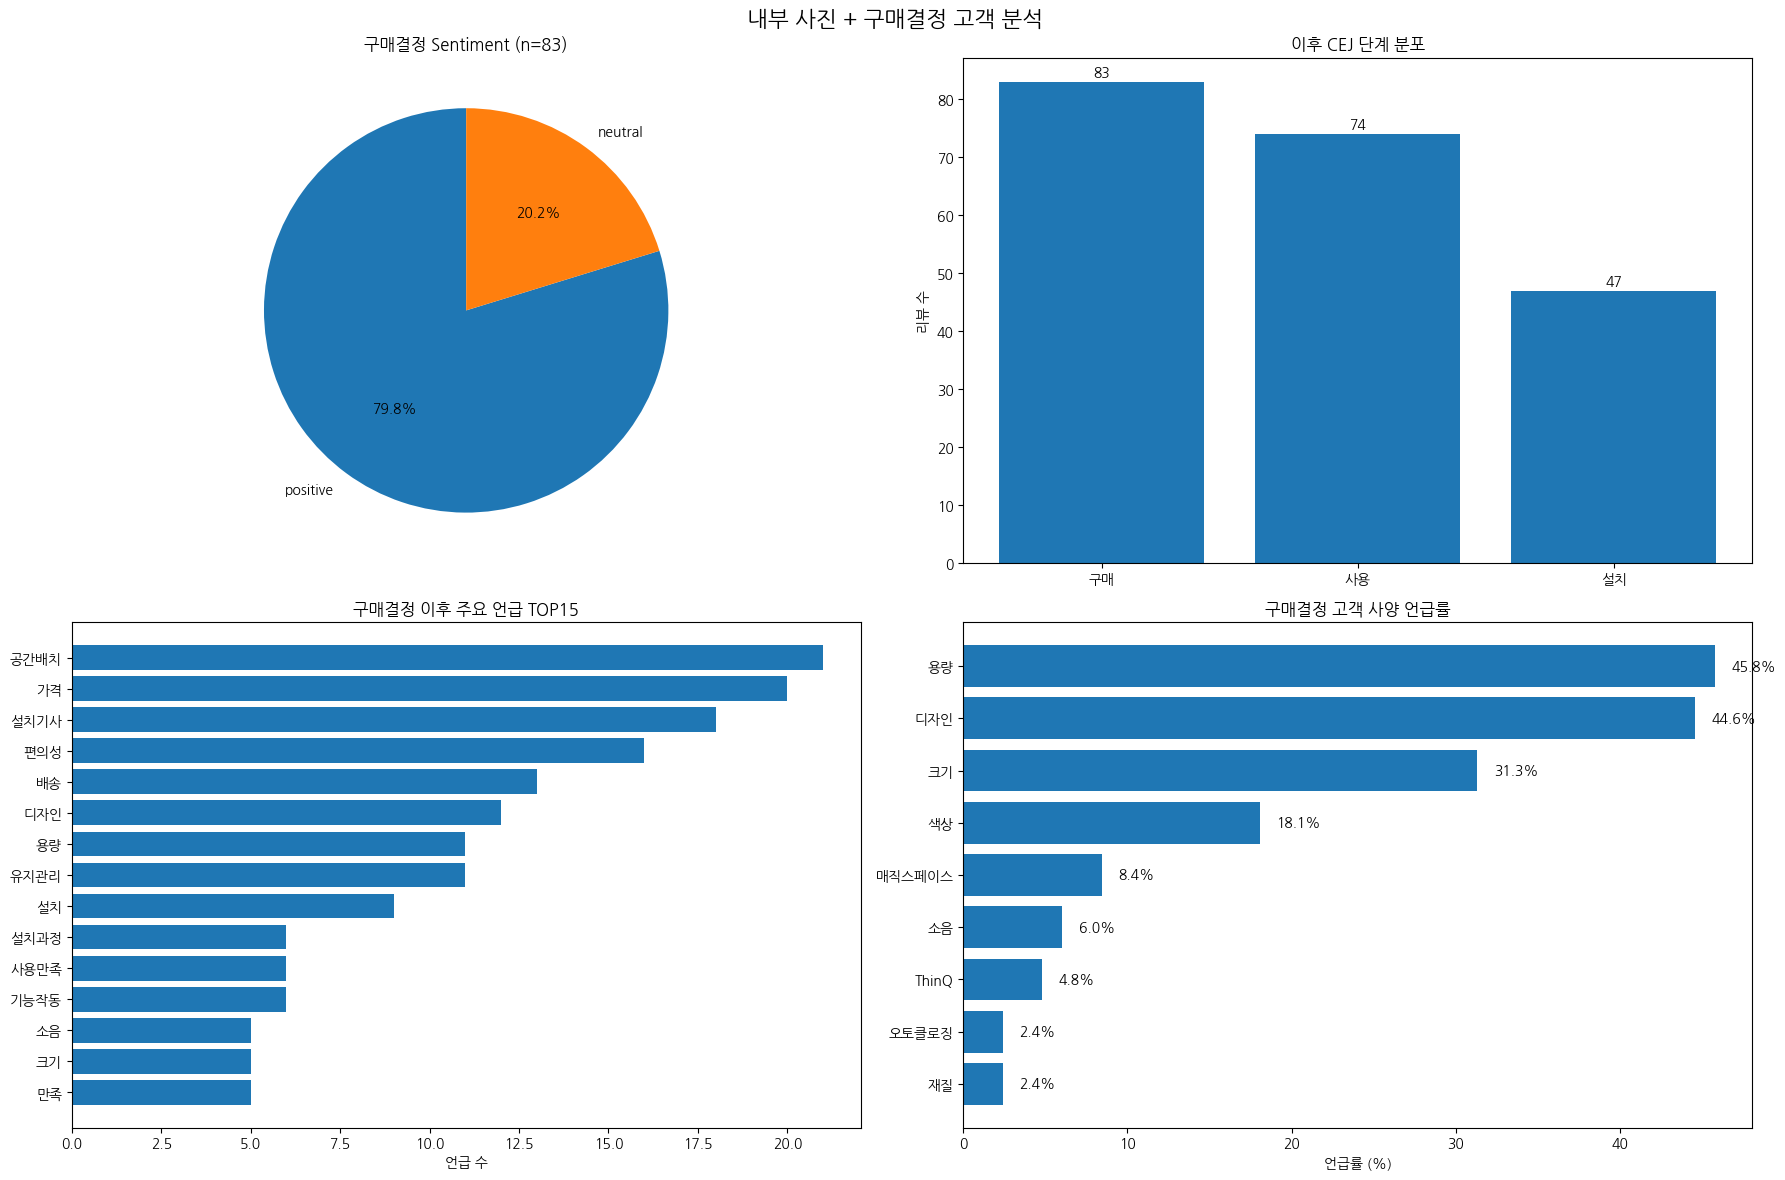

=== 구매결정 이후 주요 관심사 TOP10 ===
CEJ_item
공간배치    21
가격      20
설치기사    18
편의성     16
배송      13
디자인     12
용량      11
유지관리    11
설치       9
설치과정     6
Name: count, dtype: int64

=== 구매결정 고객 사양 언급률 ===
용량         45.8%
디자인        44.6%
크기         31.3%
색상         18.1%
매직스페이스     8.4%
소음         6.0%
ThinQ      4.8%
재질         2.4%
오토클로징      2.4%


In [ ]:
inside_ids = image_df[image_df['is_inside_visible'] == True]['review_id'].unique()

# 내부 사진 + 구매결정 언급 리뷰
buy_decision_df = text_df[
    (text_df['review_id'].isin(inside_ids)) &
    (text_df['CEJ_item'] == '구매결정')
].copy()

target_ids = buy_decision_df['review_id'].unique()

# 해당 리뷰 전체 CEJ 흐름
target_text = text_df[text_df['review_id'].isin(target_ids)].copy()

# =========================
# 1. 구매결정 sentiment
# =========================
decision_sent = buy_decision_df['CEJ_sentiment'].value_counts()

# =========================
# 2. 구매결정 고객의 전체 단계 분포
# =========================
stage_counts = (
    target_text
    .drop_duplicates(['review_id', 'CEJ_stage'])['CEJ_stage']
    .value_counts()
)

# =========================
# 3. 구매결정 고객의 이후 주요 item
# =========================
other_items = (
    target_text[target_text['CEJ_item'] != '구매결정']['CEJ_item']
    .value_counts()
    .head(15)
)

# =========================
# 4. 구매결정 고객 사양 언급률
# =========================
spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

review_level = target_text.drop_duplicates('review_id')

spec_rates = {}

for spec in spec_cols:
    col = f'{spec}_mentioned'
    if col in review_level.columns:
        spec_rates[spec] = review_level[col].mean() * 100

spec_rates = pd.Series(spec_rates).sort_values()

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('내부 사진 + 구매결정 고객 분석', fontsize=16)

# 구매결정 감정
axes[0,0].pie(
    decision_sent.values,
    labels=decision_sent.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0,0].set_title(f'구매결정 Sentiment (n={len(target_ids)})')

# 단계 분포
axes[0,1].bar(
    stage_counts.index,
    stage_counts.values
)
axes[0,1].set_title('이후 CEJ 단계 분포')
axes[0,1].set_ylabel('리뷰 수')

for i, v in enumerate(stage_counts.values):
    axes[0,1].text(i, v + 1, str(v), ha='center')

# 이후 주요 관심사
axes[1,0].barh(
    other_items.index[::-1],
    other_items.values[::-1]
)
axes[1,0].set_title('구매결정 이후 주요 언급 TOP15')
axes[1,0].set_xlabel('언급 수')

# 사양
axes[1,1].barh(
    spec_rates.index,
    spec_rates.values
)
axes[1,1].set_title('구매결정 고객 사양 언급률')
axes[1,1].set_xlabel('언급률 (%)')

for i, v in enumerate(spec_rates.values):
    axes[1,1].text(v + 1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

# =========================
# 구매결정 → 이후 전환
# =========================
print("=== 구매결정 이후 주요 관심사 TOP10 ===")
print(other_items.head(10))

print("\n=== 구매결정 고객 사양 언급률 ===")
for spec, rate in spec_rates.sort_values(ascending=False).items():
    print(f"{spec:<10} {rate:.1f}%")

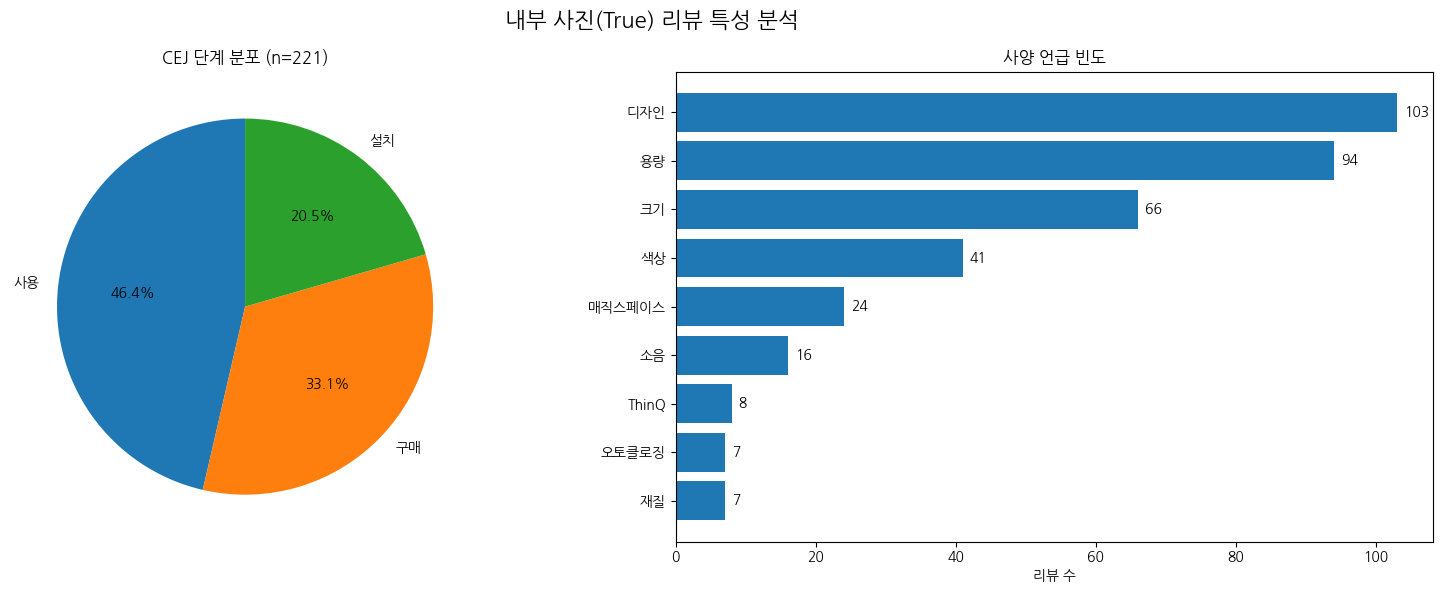

In [ ]:
inside_df = image_df[image_df['is_inside_visible'] == True].copy()

# review_id 기준 text 연결
inside_text = text_df[text_df['review_id'].isin(inside_df['review_id'].unique())].copy()

# =========================
# 1. CEJ 단계 분포
# =========================
stage_counts = inside_text.drop_duplicates(['review_id', 'CEJ_stage'])['CEJ_stage'].value_counts()

# =========================
# 2. 사양 언급 수
# =========================
spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

spec_counts = {}

review_level = inside_text.drop_duplicates('review_id')

for spec in spec_cols:
    col = f'{spec}_mentioned'
    if col in review_level.columns:
        spec_counts[spec] = review_level[col].sum()

spec_counts = pd.Series(spec_counts).sort_values(ascending=True)

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('내부 사진(True) 리뷰 특성 분석', fontsize=16)

# 단계 분포
axes[0].pie(
    stage_counts.values,
    labels=stage_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title(f'CEJ 단계 분포 (n={inside_df["review_id"].nunique()})')

# 사양 언급 분포
axes[1].barh(
    spec_counts.index,
    spec_counts.values
)
axes[1].set_title('사양 언급 빈도')
axes[1].set_xlabel('리뷰 수')

# 수치 표시
for i, v in enumerate(spec_counts.values):
    axes[1].text(v + 1, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

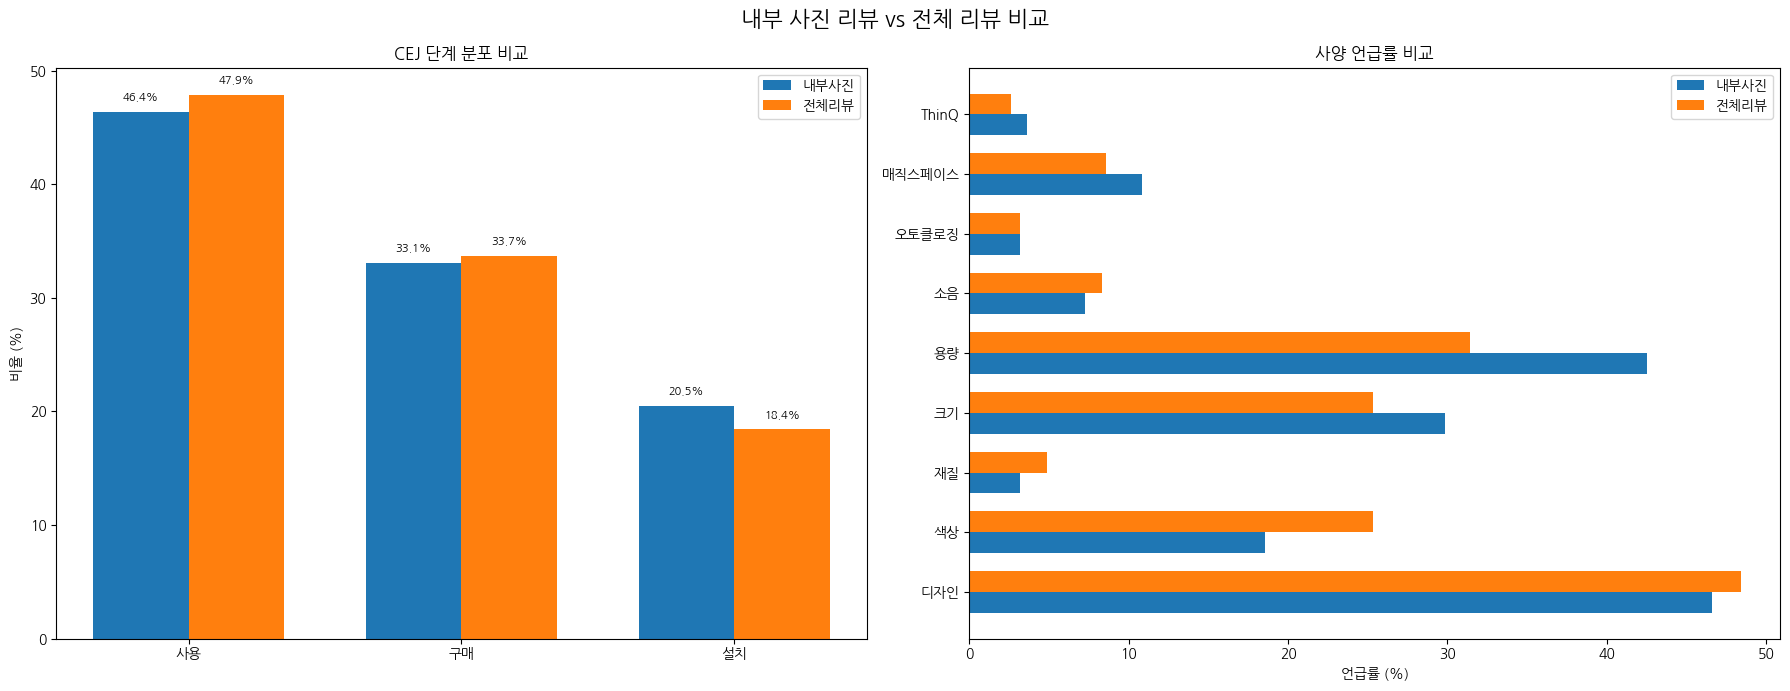

=== 내부 사진 리뷰 과대표현 사양 (전체 대비) ===
용량           ↑ 11.1%p
크기           ↑ 4.5%p
매직스페이스       ↑ 2.3%p
ThinQ        ↑ 1.0%p
오토클로징        ↓ 0.0%p
소음           ↓ 1.1%p
재질           ↓ 1.7%p
디자인          ↓ 1.9%p
색상           ↓ 6.8%p


In [ ]:
inside_ids = image_df[image_df['is_inside_visible'] == True]['review_id'].unique()
all_ids = text_df['review_id'].unique()

inside_text = text_df[text_df['review_id'].isin(inside_ids)].drop_duplicates('review_id')
all_text = text_df.drop_duplicates('review_id')

spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

# =========================
# 1. CEJ 단계 비교
# =========================
inside_stage = (
    text_df[text_df['review_id'].isin(inside_ids)]
    .drop_duplicates(['review_id', 'CEJ_stage'])['CEJ_stage']
    .value_counts(normalize=True) * 100
)

all_stage = (
    text_df
    .drop_duplicates(['review_id', 'CEJ_stage'])['CEJ_stage']
    .value_counts(normalize=True) * 100
)

stage_df = pd.DataFrame({
    '내부사진': inside_stage,
    '전체리뷰': all_stage
}).fillna(0)

# =========================
# 2. 사양 언급률 비교
# =========================
inside_spec = {}
all_spec = {}

for spec in spec_cols:
    col = f'{spec}_mentioned'
    if col in inside_text.columns:
        inside_spec[spec] = inside_text[col].mean() * 100
        all_spec[spec] = all_text[col].mean() * 100

spec_df = pd.DataFrame({
    '내부사진': pd.Series(inside_spec),
    '전체리뷰': pd.Series(all_spec)
}).fillna(0)

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('내부 사진 리뷰 vs 전체 리뷰 비교', fontsize=16)

# 단계 비교
x1 = range(len(stage_df))
width = 0.35

axes[0].bar(
    [i - width/2 for i in x1],
    stage_df['내부사진'],
    width=width,
    label='내부사진'
)

axes[0].bar(
    [i + width/2 for i in x1],
    stage_df['전체리뷰'],
    width=width,
    label='전체리뷰'
)

axes[0].set_xticks(list(x1))
axes[0].set_xticklabels(stage_df.index)
axes[0].set_ylabel('비율 (%)')
axes[0].set_title('CEJ 단계 분포 비교')
axes[0].legend()

for i, v in enumerate(stage_df['내부사진']):
    axes[0].text(i - width/2, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

for i, v in enumerate(stage_df['전체리뷰']):
    axes[0].text(i + width/2, v + 1, f'{v:.1f}%', ha='center', fontsize=8)

# 사양 비교
x2 = range(len(spec_df))

axes[1].barh(
    [i - width/2 for i in x2],
    spec_df['내부사진'],
    height=width,
    label='내부사진'
)

axes[1].barh(
    [i + width/2 for i in x2],
    spec_df['전체리뷰'],
    height=width,
    label='전체리뷰'
)

axes[1].set_yticks(list(x2))
axes[1].set_yticklabels(spec_df.index)
axes[1].set_xlabel('언급률 (%)')
axes[1].set_title('사양 언급률 비교')
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================
# 차이 출력
# =========================
print("=== 내부 사진 리뷰 과대표현 사양 (전체 대비) ===")
diff = (spec_df['내부사진'] - spec_df['전체리뷰']).sort_values(ascending=False)

for spec, val in diff.items():
    direction = "↑" if val > 0 else "↓"
    print(f"{spec:<12} {direction} {abs(val):.1f}%p")

In [ ]:
# 매칭 확인
print(space_ids[:5])
print(image_df['review_id'].head())

# 데이터 타입 확인
print(type(space_ids[0]))
print(type(image_df['review_id'].iloc[0]))

[707747 683115 673967 673277 653972]
0    693164
1    678135
2    639772
3    619410
4    612860
Name: review_id, dtype: int64
<class 'numpy.int64'>
<class 'numpy.int64'>


In [ ]:
# 실제 교집합 확인
space_set = set(space_ids)
image_set = set(image_df['review_id'].unique())

overlap = space_set & image_set
print(f"공간 페인포인트 리뷰: {len(space_set)}개")
print(f"이미지 데이터 리뷰: {len(image_set)}개")
print(f"교집합: {len(overlap)}개")

# install_df review_id도 확인
install_set = set(install_df['review_id'].unique())
install_image_overlap = install_set & image_set
print(f"\n설치 단계 리뷰: {len(install_set)}개")
print(f"설치 × 이미지 교집합: {len(install_image_overlap)}개")

공간 페인포인트 리뷰: 44개
이미지 데이터 리뷰: 2368개
교집합: 43개

설치 단계 리뷰: 296개
설치 × 이미지 교집합: 282개


In [ ]:
# 공간 페인포인트 이미지 데이터 직접 확인
space_image = image_df[image_df['review_id'].isin(space_ids)]
print(f"행 수: {len(space_image)}")
print("\n=== placement_type ===")
print(space_image['placement_type'].value_counts())
print("\n=== size_fit_impression ===")
print(space_image['size_fit_impression'].value_counts())
print("\n=== margin_top ===")
print(space_image['margin_top'].value_counts())
print("\n첫 3행 확인")
print(space_image[['review_id', 'placement_type', 'size_fit_impression', 'margin_top']].head(3))

행 수: 43

=== placement_type ===
placement_type
벽면배치      28
가구사이배치    14
판단 어려움     1
Name: count, dtype: int64

=== size_fit_impression ===
size_fit_impression
적절함           40
공간에 비해 적절함     2
판단 어려움         1
Name: count, dtype: int64

=== margin_top ===
margin_top
보통        28
좁음        11
판단 어려움     3
여유 있음      1
Name: count, dtype: int64

첫 3행 확인
      review_id placement_type size_fit_impression margin_top
1434     683115           벽면배치                 적절함         보통
1467     673967           벽면배치                 적절함         보통
1472     673277         가구사이배치                 적절함         좁음


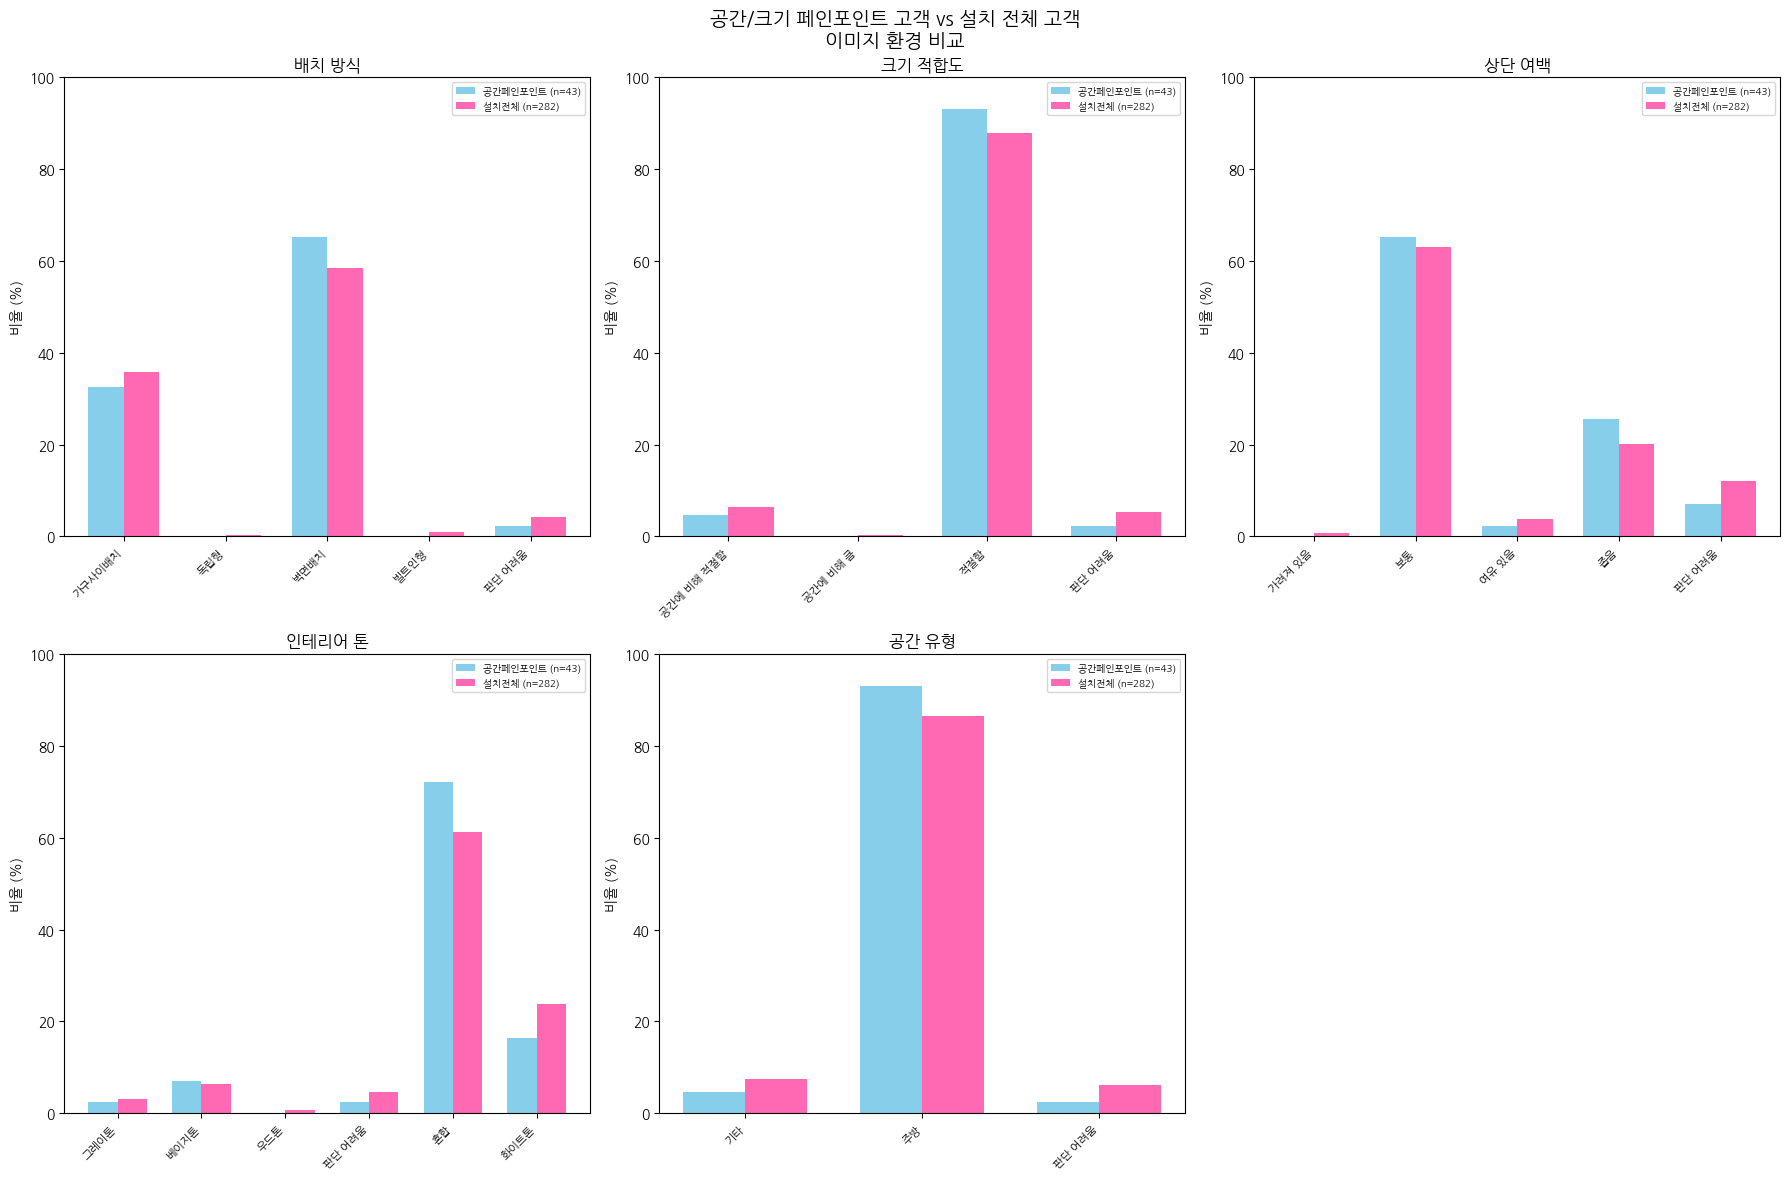

In [ ]:
# 공간 페인포인트 vs 설치 전체 비교 시각화
space_image = image_df[image_df['review_id'].isin(space_ids)]
all_install_image = image_df[image_df['review_id'].isin(install_df['review_id'].unique())]

compare_cols = {
    'placement_type': '배치 방식',
    'size_fit_impression': '크기 적합도',
    'margin_top': '상단 여백',
    'interior_tone': '인테리어 톤',
    'space_type': '공간 유형'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('공간/크기 페인포인트 고객 vs 설치 전체 고객\n이미지 환경 비교', fontsize=14)
axes = axes.flatten()

for i, (col, title) in enumerate(compare_cols.items()):
    pain_dist = space_image[col].value_counts(normalize=True) * 100
    all_dist = all_install_image[col].value_counts(normalize=True) * 100

    # 전체 카테고리 합치기
    all_cats = sorted(set(pain_dist.index) | set(all_dist.index))

    pain_vals = [pain_dist.get(c, 0) for c in all_cats]
    all_vals = [all_dist.get(c, 0) for c in all_cats]

    x = range(len(all_cats))
    width = 0.35

    axes[i].bar([xi - width/2 for xi in x], pain_vals, width=width,
                label=f'공간페인포인트 (n={len(space_image)})', color='#87CEEB')
    axes[i].bar([xi + width/2 for xi in x], all_vals, width=width,
                label=f'설치전체 (n={len(all_install_image)})', color='#FF69B4')

    axes[i].set_title(title)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(all_cats, rotation=45, ha='right', fontsize=8)
    axes[i].set_ylabel('비율 (%)')
    axes[i].set_ylim(0, 100)
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print("총 행 개수:", len(image_df))

# 첫 번째 행 전체 보기
row = image_df.iloc[0]

print("\n=== 첫 번째 행 전체 정보 ===")
for col in image_df.columns:
    print(f"{col}: {row[col]}")

총 행 개수: 2368

=== 첫 번째 행 전체 정보 ===
review_id: 693164
review_order: 1
review_text: 기존에 냉장고가 고장이 나서 급하게 구입했습니다 1등급에 오토클로징에 저렴한 가격에 좋은 제품 구매했습니다
rating: 5
written_date: 2026.04.10
product_option: 소재:네이처(메탈)|색상:베이지/베이지
image_urls: https://static.lge.co.kr/prod-mkt/itm/kr/upload/review/693164/20260410211141792_f4c86e19.jpg
image_paths: 693164_1.jpg
product_visible: True
visibility_level: 높음
visible_view: 정면+측면
scene_type: 설치공간
space_type: 주방
placement_type: 가구사이배치
margin_left: 보통
margin_right: 좁음
margin_top: 좁음
size_fit_impression: 적절함
interior_tone: 화이트톤
main_colors: 화이트|베이지|그레이|블랙
visible_furniture: 싱크대|상부장|하부장|창문|조리대|벽면 수납공간
visible_appliances: 오븐
visible_materials: 타일|유리|목재|금속
is_inside_visible: False
inside_description: nan
visual_evidence: 주방 공간에 냉장고가 다른 가구 사이에 배치되어 있으며, 왼쪽에는 싱크대와 창문, 오른쪽에는 빌트인 형태의 오븐 수납공간이 보입니다. 바닥과 벽, 수납장이 밝은 톤으로 구성되어 있고 냉장고 상단과 우측은 주변 구조물과 가까워 보입니다.


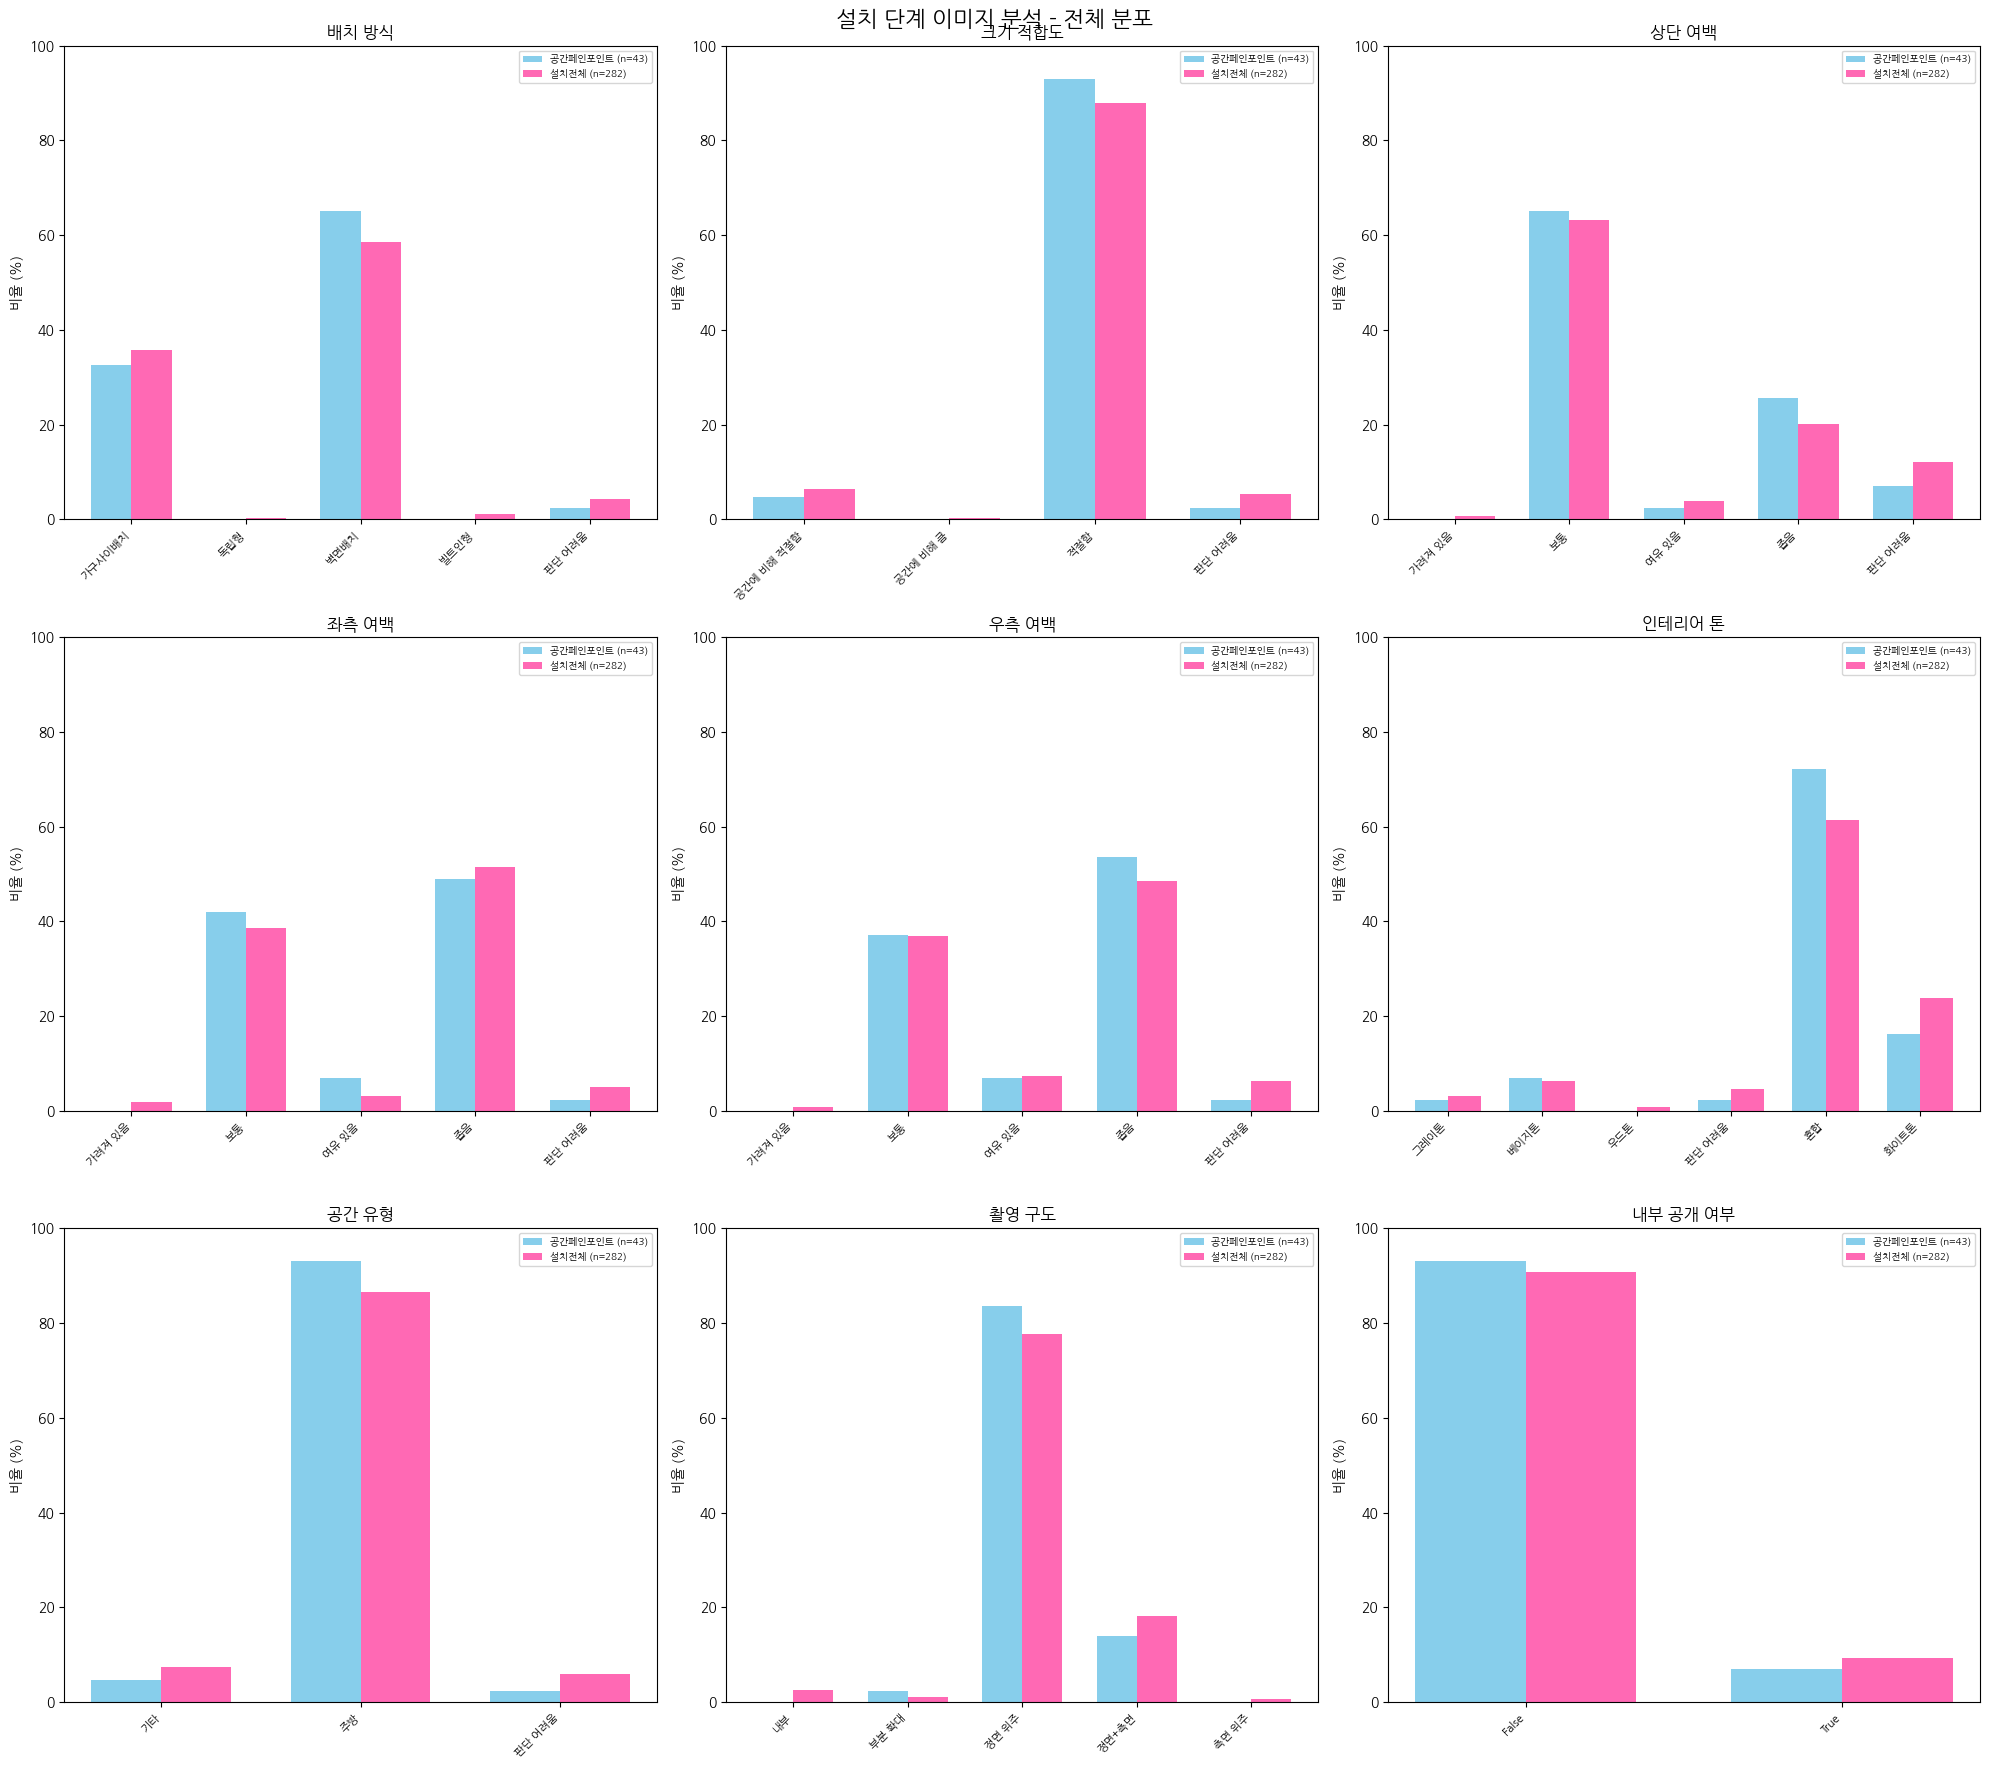


=== 게인포인트별 이미지 환경 분포 ===

[기사친절] n=96
  배치방식: {'벽면배치': 56, '가구사이배치': 31, '판단 어려움': 7, '빌트인형': 1, '독립형': 1}
  인테리어: {'혼합': 57, '화이트톤': 22, '판단 어려움': 6, '베이지톤': 6, '그레이톤': 4, '우드톤': 1}
  크기적합: {'적절함': 78, '공간에 비해 적절함': 10, '판단 어려움': 7, '공간에 비해 큼': 1}

[빠른설치] n=12
  배치방식: {'벽면배치': 6, '가구사이배치': 6}
  인테리어: {'혼합': 8, '화이트톤': 4}
  크기적합: {'적절함': 12}

[깔끔한설치] n=67
  배치방식: {'벽면배치': 42, '가구사이배치': 21, '판단 어려움': 2, '빌트인형': 1, '독립형': 1}
  인테리어: {'혼합': 38, '화이트톤': 14, '베이지톤': 7, '그레이톤': 5, '판단 어려움': 2, '우드톤': 1}
  크기적합: {'적절함': 57, '공간에 비해 적절함': 8, '판단 어려움': 2}

[폐가전수거] n=3
  배치방식: {'벽면배치': 3}
  인테리어: {'혼합': 2, '베이지톤': 1}
  크기적합: {'적절함': 2, '공간에 비해 큼': 1}

[설명충실] n=22
  배치방식: {'벽면배치': 15, '가구사이배치': 5, '판단 어려움': 2}
  인테리어: {'혼합': 12, '화이트톤': 6, '베이지톤': 2, '판단 어려움': 2}
  크기적합: {'적절함': 16, '공간에 비해 적절함': 3, '판단 어려움': 2, '공간에 비해 큼': 1}


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('설치 단계 이미지 분석 - 전체 분포', fontsize=16)
axes = axes.flatten()

all_install_image = image_df[image_df['review_id'].isin(install_df['review_id'].unique())]
space_image = image_df[image_df['review_id'].isin(space_ids)]

compare_cols = {
    'placement_type': '배치 방식',
    'size_fit_impression': '크기 적합도',
    'margin_top': '상단 여백',
    'margin_left': '좌측 여백',
    'margin_right': '우측 여백',
    'interior_tone': '인테리어 톤',
    'space_type': '공간 유형',
    'visible_view': '촬영 구도',
    'is_inside_visible': '내부 공개 여부'
}

for i, (col, title) in enumerate(compare_cols.items()):
    pain_dist = space_image[col].value_counts(normalize=True) * 100
    all_dist = all_install_image[col].value_counts(normalize=True) * 100

    all_cats = sorted(set(pain_dist.index) | set(all_dist.index))
    pain_vals = [pain_dist.get(c, 0) for c in all_cats]
    all_vals = [all_dist.get(c, 0) for c in all_cats]

    x = range(len(all_cats))
    width = 0.35

    axes[i].bar([xi - width/2 for xi in x], pain_vals, width=width,
                label=f'공간페인포인트 (n={len(space_image)})', color='#87CEEB')
    axes[i].bar([xi + width/2 for xi in x], all_vals, width=width,
                label=f'설치전체 (n={len(all_install_image)})', color='#FF69B4')

    axes[i].set_title(title)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(all_cats, rotation=45, ha='right', fontsize=8)
    axes[i].set_ylabel('비율 (%)')
    axes[i].set_ylim(0, 100)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

# 추가: 게인포인트 고객 이미지 분포도 비교
print("\n=== 게인포인트별 이미지 환경 분포 ===")
for gain_cat in GAIN_INSTALL.keys():
    gain_ids = install_df[
        install_df["gain_install"].apply(lambda x: gain_cat in x)
    ]['review_id'].unique()

    gain_image = image_df[image_df['review_id'].isin(gain_ids)]
    if len(gain_image) == 0:
        continue

    print(f"\n[{gain_cat}] n={len(gain_image)}")
    print(f"  배치방식: {gain_image['placement_type'].value_counts().to_dict()}")
    print(f"  인테리어: {gain_image['interior_tone'].value_counts().to_dict()}")
    print(f"  크기적합: {gain_image['size_fit_impression'].value_counts().to_dict()}")

In [ ]:
all_install_image = image_df[image_df['review_id'].isin(install_df['review_id'].unique())]
print(f"설치 단계 이미지: {len(all_install_image)}개")

# 텍스트 컬럼 확인
print("\n=== visible_furniture 샘플 ===")
print(all_install_image['visible_furniture'].dropna().head(10).values)

print("\n=== visible_appliances 샘플 ===")
print(all_install_image['visible_appliances'].dropna().head(10).values)

print("\n=== main_colors 샘플 ===")
print(all_install_image['main_colors'].dropna().head(10).values)

print("\n=== visual_evidence 샘플 ===")
print(all_install_image['visual_evidence'].dropna().head(5).values)

설치 단계 이미지: 282개

=== visible_furniture 샘플 ===
['상부장|바닥' '주방 수납장|벽면 선반/수납공간|바닥' '상부장|싱크대|조리대|수납장'
 '상부장|하부장|조리대|벽면 수납공간|거울/액자 형태의 장식물|스탠드형 거울' '벽면|창문|창문 블라인드' '문|수납장|벽면'
 '상부장|옆 수납장|벽면' '커튼|의자 일부|벽면' '벽면|문틀|바닥|수납공간 일부' '벽면|문틀|창문']

=== visible_appliances 샘플 ===
['정수기' '세탁기|정수기' '공기청정기' '가스레인지' '로봇청소기|청소기/충전기처럼 보이는 기기' '다른 냉장고 일부'
 '전자레인지' '커피머신' '오른쪽의 다른 냉장고' '정수기']

=== main_colors 샘플 ===
['화이트|블랙|회색' '화이트|베이지|우드톤|그레이' '화이트|회색|우드톤|검정' '화이트|베이지|블랙|우드'
 '화이트|연회색|짙은 회색|연한 베이지' '화이트|베이지|우드톤|그레이' '화이트|블랙|연한 우드' '흰색|검은색|파란색'
 '화이트|연회색|검정' '화이트|그레이|우드톤|블루']

=== visual_evidence 샘플 ===
['주방 벽면에 냉장고가 붙어 설치되어 있고, 좌우 여유는 크지 않아 보인다. 상부장과 타일 바닥이 함께 보이며, 냉장고 문이 열려 내부 수납칸이 드러난 상태다.'
 '주방 벽면에 냉장고가 붙어 설치되어 있고, 오른쪽은 문이 열려 있으며 왼쪽에는 다른 수납공간이 인접해 있다. 바닥은 우드톤이고 주변은 비교적 정돈된 실내 주방 환경으로 보인다.'
 '주방 공간에 냉장고가 벽면을 따라 배치되어 있고, 좌우와 상단에 큰 간섭 없이 설치된 모습입니다. 주변에는 상부장과 싱크대, 다른 가전 일부가 함께 보여 실제 주방 사용환경으로 보입니다.'
 '주방 벽면에 냉장고가 배치되어 있고 상부장 아래 공간에 들어가 있는 형태로 보인다. 좌우 측면 여유는 보통 수준이며 상단은 상부장과 가까워 좁아 보이고, 주변에는 주방 가구와 생활 소품이 함께 보인다

In [ ]:
from collections import Counter

def count_pipe_separated(series):
    all_items = []
    for val in series.dropna():
        items = [x.strip() for x in str(val).split('|')]
        all_items.extend(items)
    return Counter(all_items)

# 1. 동반 가전 빈도
appliance_counts = count_pipe_separated(all_install_image['visible_appliances'])
print("=== 동반 가전 Top 15 ===")
for k, v in appliance_counts.most_common(15):
    print(f"  {k}: {v}개")

# 2. 주변 색상 빈도
color_counts = count_pipe_separated(all_install_image['main_colors'])
print("\n=== 주변 색상 Top 15 ===")
for k, v in color_counts.most_common(15):
    print(f"  {k}: {v}개")

# 3. 주변 가구 빈도
furniture_counts = count_pipe_separated(all_install_image['visible_furniture'])
print("\n=== 주변 가구 Top 15 ===")
for k, v in furniture_counts.most_common(15):
    print(f"  {k}: {v}개")

=== 동반 가전 Top 15 ===
  정수기: 24개
  전자레인지: 18개
  전기밥솥: 13개
  가스레인지: 8개
  커피머신: 7개
  공기청정기: 4개
  전기포트: 4개
  세탁기: 3개
  다른 냉장고: 3개
  오븐: 3개
  후드: 3개
  다른 냉장고 일부: 2개
  밥솥: 2개
  인덕션: 2개
  싱크볼: 2개

=== 주변 색상 Top 15 ===
  화이트: 224개
  베이지: 152개
  블랙: 129개
  그레이: 86개
  우드톤: 82개
  회색: 54개
  흰색: 42개
  검정: 33개
  브라운: 28개
  연한 베이지: 27개
  연회색: 24개
  우드: 20개
  연한 우드: 17개
  연한 회색: 12개
  연한 우드톤: 11개

=== 주변 가구 Top 15 ===
  상부장: 133개
  벽면: 100개
  조리대: 90개
  하부장: 79개
  바닥: 71개
  문틀: 38개
  수납장: 30개
  벽면 수납장: 29개
  선반: 25개
  창문: 24개
  싱크대: 20개
  벽면 수납공간: 14개
  문: 11개
  오픈 선반: 8개
  붙박이장/수납장: 8개


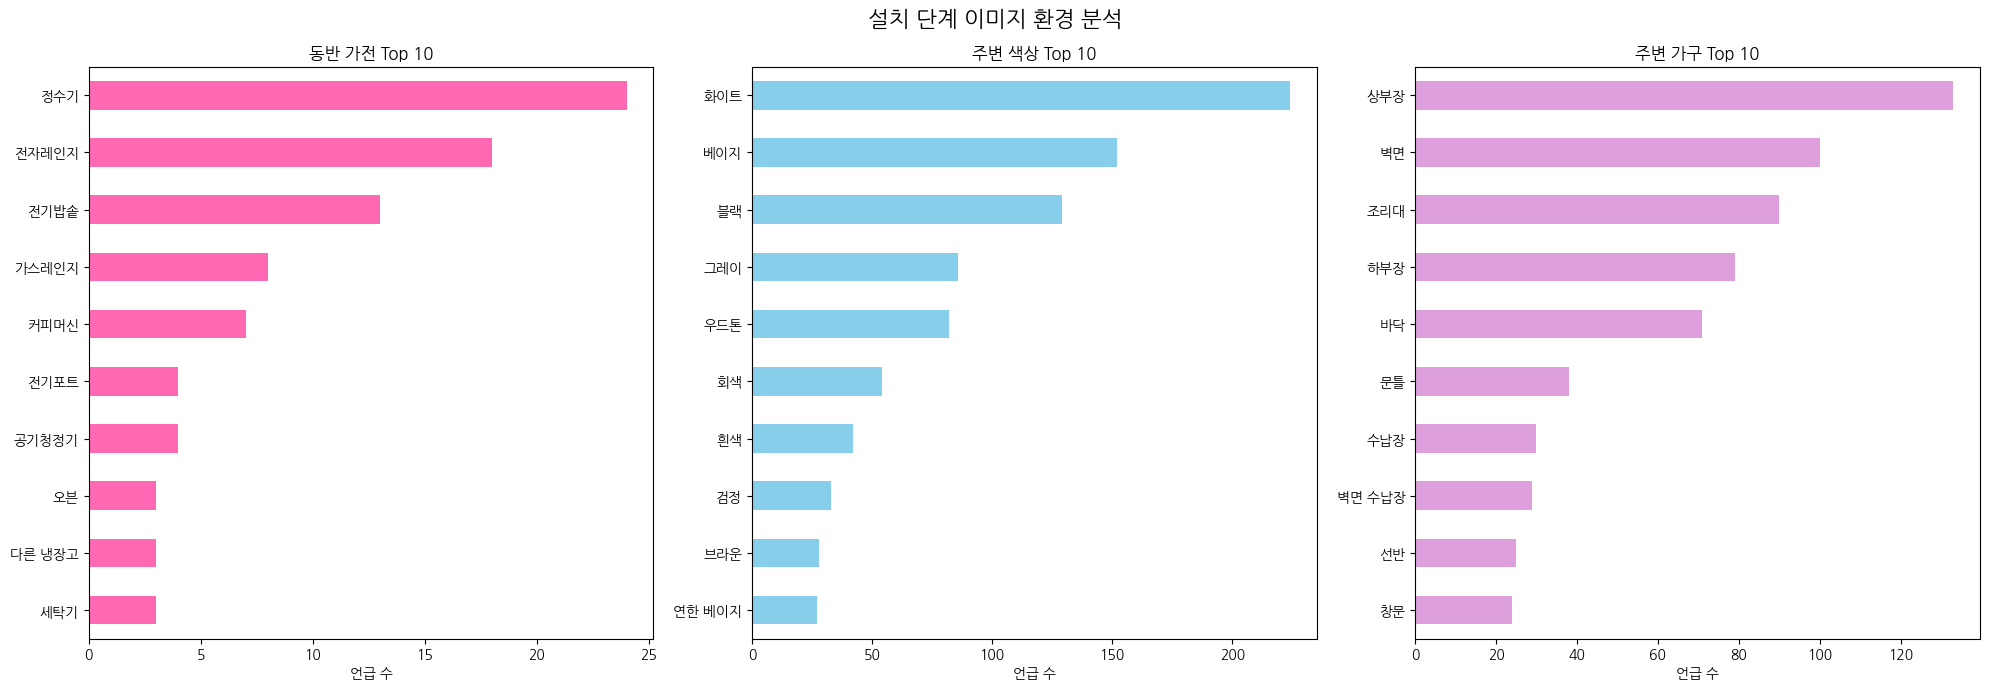

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('설치 단계 이미지 환경 분석', fontsize=16)

# 1. 동반 가전
appliance_series = pd.Series(dict(appliance_counts.most_common(10)))
appliance_series.sort_values().plot(kind='barh', ax=axes[0], color='#FF69B4')
axes[0].set_title('동반 가전 Top 10')
axes[0].set_xlabel('언급 수')

# 2. 주변 색상
color_series = pd.Series(dict(color_counts.most_common(10)))
color_series.sort_values().plot(kind='barh', ax=axes[1], color='#87CEEB')
axes[1].set_title('주변 색상 Top 10')
axes[1].set_xlabel('언급 수')

# 3. 주변 가구
furniture_series = pd.Series(dict(furniture_counts.most_common(10)))
furniture_series.sort_values().plot(kind='barh', ax=axes[2], color='#DDA0DD')
axes[2].set_title('주변 가구 Top 10')
axes[2].set_xlabel('언급 수')

plt.tight_layout()
plt.show()

In [ ]:
# 색상 sentiment × 주변 색상 연결
# 화이트 환경에서 색상 만족도가 높은가?

# main_colors에 화이트 포함된 리뷰
white_env = all_install_image[
    all_install_image['main_colors'].str.contains('화이트', na=False)
]['review_id'].unique()

# 그 리뷰들의 색상 sentiment
white_sentiment = text_df[
    text_df['review_id'].isin(white_env)
]['색상_sentiment'].value_counts(normalize=True) * 100

# main_colors에 화이트 없는 리뷰
non_white_env = all_install_image[
    ~all_install_image['main_colors'].str.contains('화이트', na=False)
]['review_id'].unique()

non_white_sentiment = text_df[
    text_df['review_id'].isin(non_white_env)
]['색상_sentiment'].value_counts(normalize=True) * 100

print("=== 화이트 환경 색상 sentiment ===")
print(white_sentiment.round(1))
print("\n=== 비화이트 환경 색상 sentiment ===")
print(non_white_sentiment.round(1))

=== 화이트 환경 색상 sentiment ===
색상_sentiment
positive    99.0
neutral      1.0
Name: proportion, dtype: float64

=== 비화이트 환경 색상 sentiment ===
색상_sentiment
positive    78.5
neutral     10.8
mixed       10.8
Name: proportion, dtype: float64


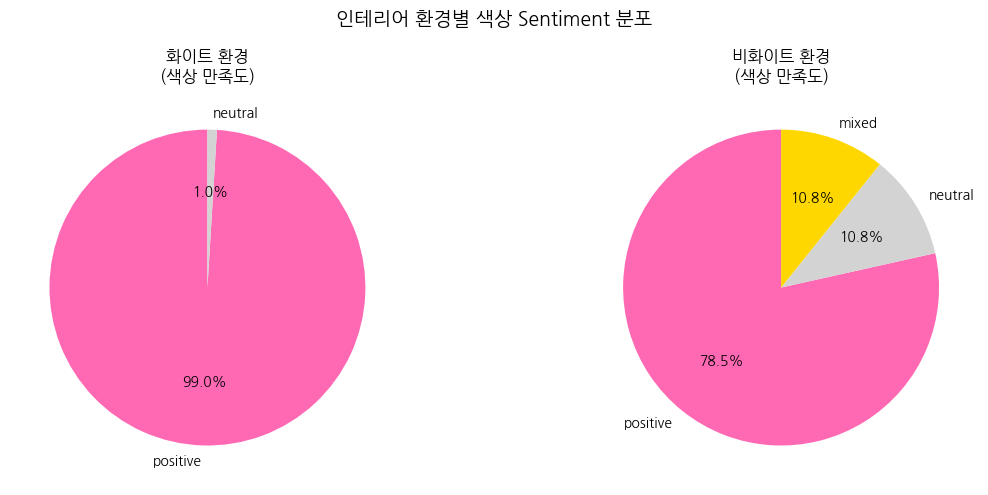

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('인테리어 환경별 색상 Sentiment 분포', fontsize=14)

colors_map = {
    'positive': '#FF69B4',
    'negative': '#87CEEB',
    'neutral': '#D3D3D3',
    'mixed': '#FFD700'
}

for i, (label, sentiment) in enumerate([
    ('화이트 환경', white_sentiment),
    ('비화이트 환경', non_white_sentiment)
]):
    colors = [colors_map.get(c, '#D3D3D3') for c in sentiment.index]
    axes[i].pie(sentiment.values, labels=sentiment.index,
                colors=colors, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{label}\n(색상 만족도)')

plt.tight_layout()
plt.show()

In [ ]:
# 기본 구조
print(f"전체 행 수: {len(text_df)}")
print(f"unique 리뷰 수: {text_df['review_id'].nunique()}")
print(f"리뷰당 평균 행 수: {len(text_df) / text_df['review_id'].nunique():.1f}")

# CEJ_item 분포
print("\n=== CEJ_item 분포 ===")
print(text_df['CEJ_item'].value_counts().head(20))

# CEJ_stage 분포
print("\n=== CEJ_stage 분포 ===")
print(text_df['CEJ_stage'].value_counts())

# image_df 구조
print("\n=== image_df 구조 ===")
print(image_df.shape)
print(image_df.columns.tolist())

전체 행 수: 9566
unique 리뷰 수: 2827
리뷰당 평균 행 수: 3.4

=== CEJ_item 분포 ===
CEJ_item
구매결정      917
디자인       719
용량        590
가격        386
크기        356
색상        316
설치기사      294
배송        285
공간배치      255
설치        254
편의성       223
소음        217
만족        185
매직스페이스    183
성능        167
유지관리      124
구입        107
가성비        98
오토클로징      92
사용         79
Name: count, dtype: int64

=== CEJ_stage 분포 ===
CEJ_stage
사용    5341
구매    2751
설치    1474
Name: count, dtype: int64

=== image_df 구조 ===
(4104, 26)
['review_id', 'review_order', 'review_text', 'rating', 'written_date', 'product_option', 'image_urls', 'image_paths', 'product_visible', 'visibility_level', 'visible_view', 'scene_type', 'space_type', 'placement_type', 'margin_left', 'margin_right', 'margin_top', 'size_fit_impression', 'interior_tone', 'main_colors', 'visible_furniture', 'visible_appliances', 'visible_materials', 'is_inside_visible', 'inside_description', 'visual_evidence']


In [ ]:
# CEJ_stage별 CEJ_item 분포
for stage in ['구매', '설치', '사용']:
    print(f"\n=== {stage} 단계 Top 10 ===")
    subset = text_df[text_df['CEJ_stage'] == stage]
    print(subset['CEJ_item'].value_counts().head(10))


=== 구매 단계 Top 10 ===
CEJ_item
구매결정     917
가격       386
배송       231
구입       107
가성비       95
구매        69
AS기대감     44
만족        35
환급        29
용량        26
Name: count, dtype: int64

=== 설치 단계 Top 10 ===
CEJ_item
설치기사    294
설치      253
공간배치    250
초기세팅     64
설치과정     62
배송       52
반입       40
이사       39
크기       26
설명       24
Name: count, dtype: int64

=== 사용 단계 Top 10 ===
CEJ_item
디자인       705
용량        563
크기        324
색상        293
편의성       223
소음        216
매직스페이스    175
성능        164
만족        150
유지관리      124
Name: count, dtype: int64


In [ ]:
stage_counts = text_df.groupby('review_id')['CEJ_stage'].nunique()

multi_stage_reviews = (stage_counts >= 2).sum()
total_reviews = stage_counts.shape[0]

ratio = multi_stage_reviews / total_reviews * 100

print(f"전체 리뷰 수: {total_reviews}개")
print(f"2개 이상 단계 포함 리뷰 수: {multi_stage_reviews}개")
print(f"비율: {ratio:.2f}%")

전체 리뷰 수: 2827개
2개 이상 단계 포함 리뷰 수: 1754개
비율: 62.04%


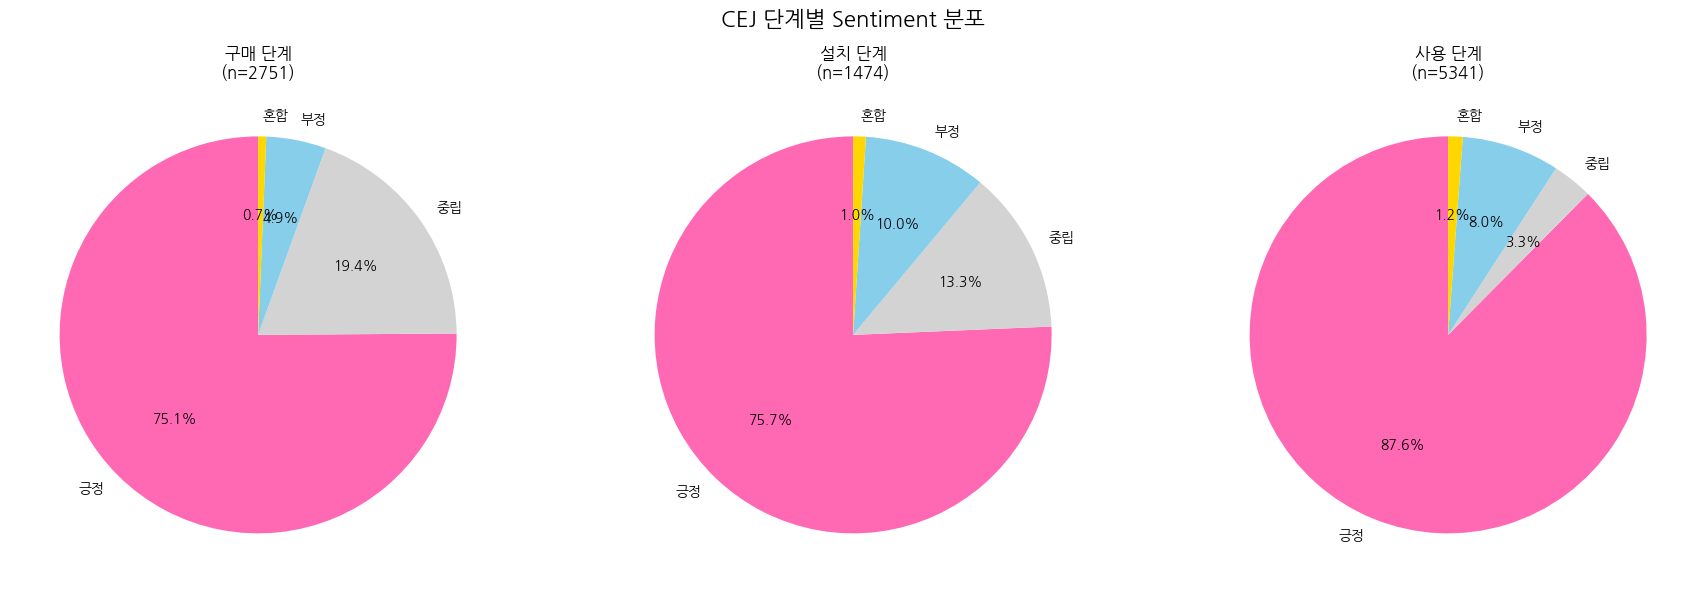

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('CEJ 단계별 Sentiment 분포\n', fontsize=16)

stages = ['구매', '설치', '사용']
colors = ['#FF69B4', '#D3D3D3', '#87CEEB', '#FFD700']
labels = ['긍정', '중립', '부정', '혼합']

for i, stage in enumerate(stages):
    subset = text_df[text_df['CEJ_stage'] == stage]
    counts = subset['CEJ_sentiment'].value_counts()

    # 순서 맞추기
    ordered = [counts.get(s, 0) for s in ['positive', 'neutral', 'negative', 'mixed']]

    axes[i].pie(
        ordered,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(f'{stage} 단계\n(n={len(subset)})')

plt.tight_layout()
plt.show()


========== 구매 → 설치 단계 관계 ==========

공통 리뷰 수: 777


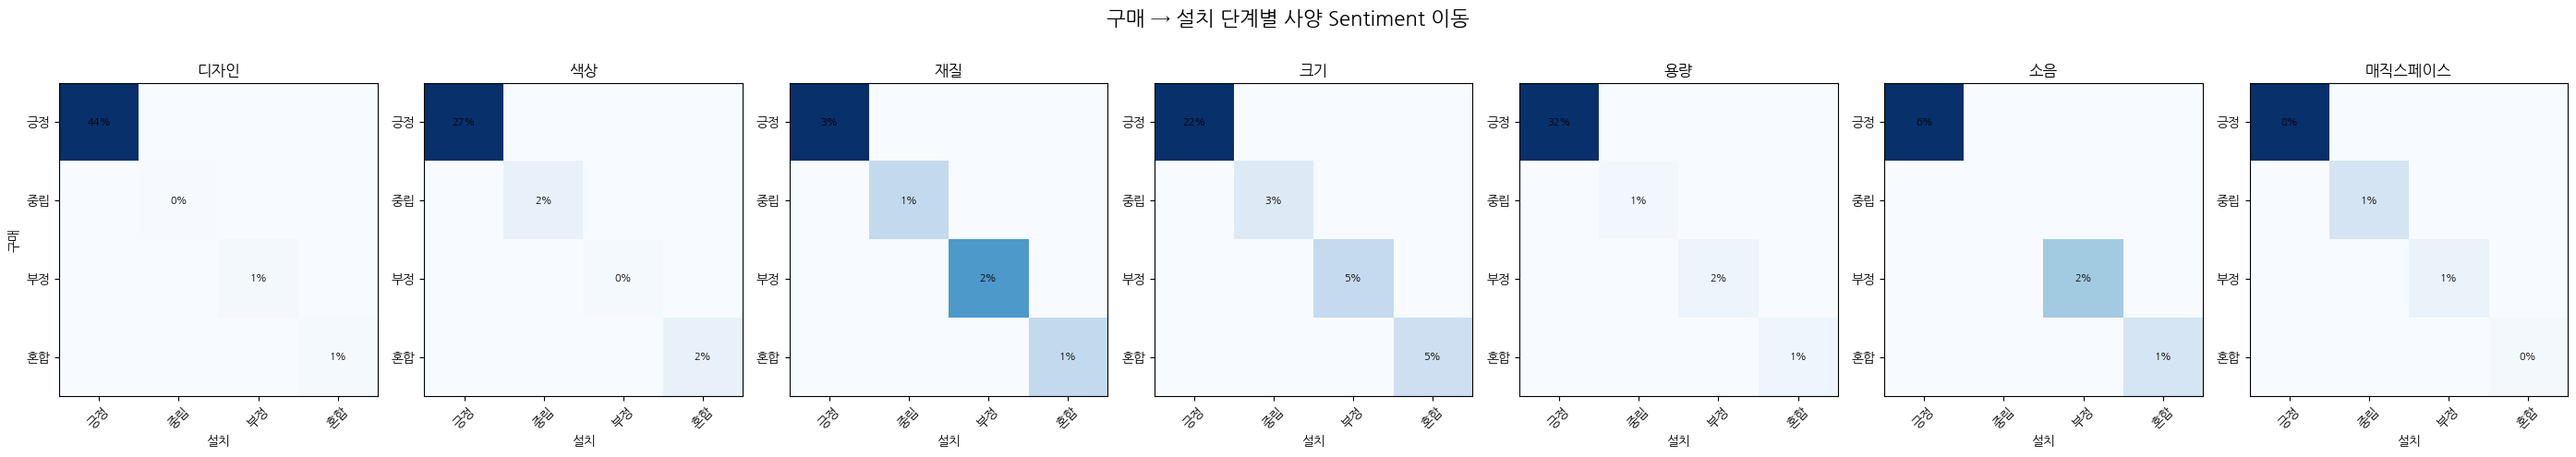


========== 설치 → 사용 단계 관계 ==========

공통 리뷰 수: 799


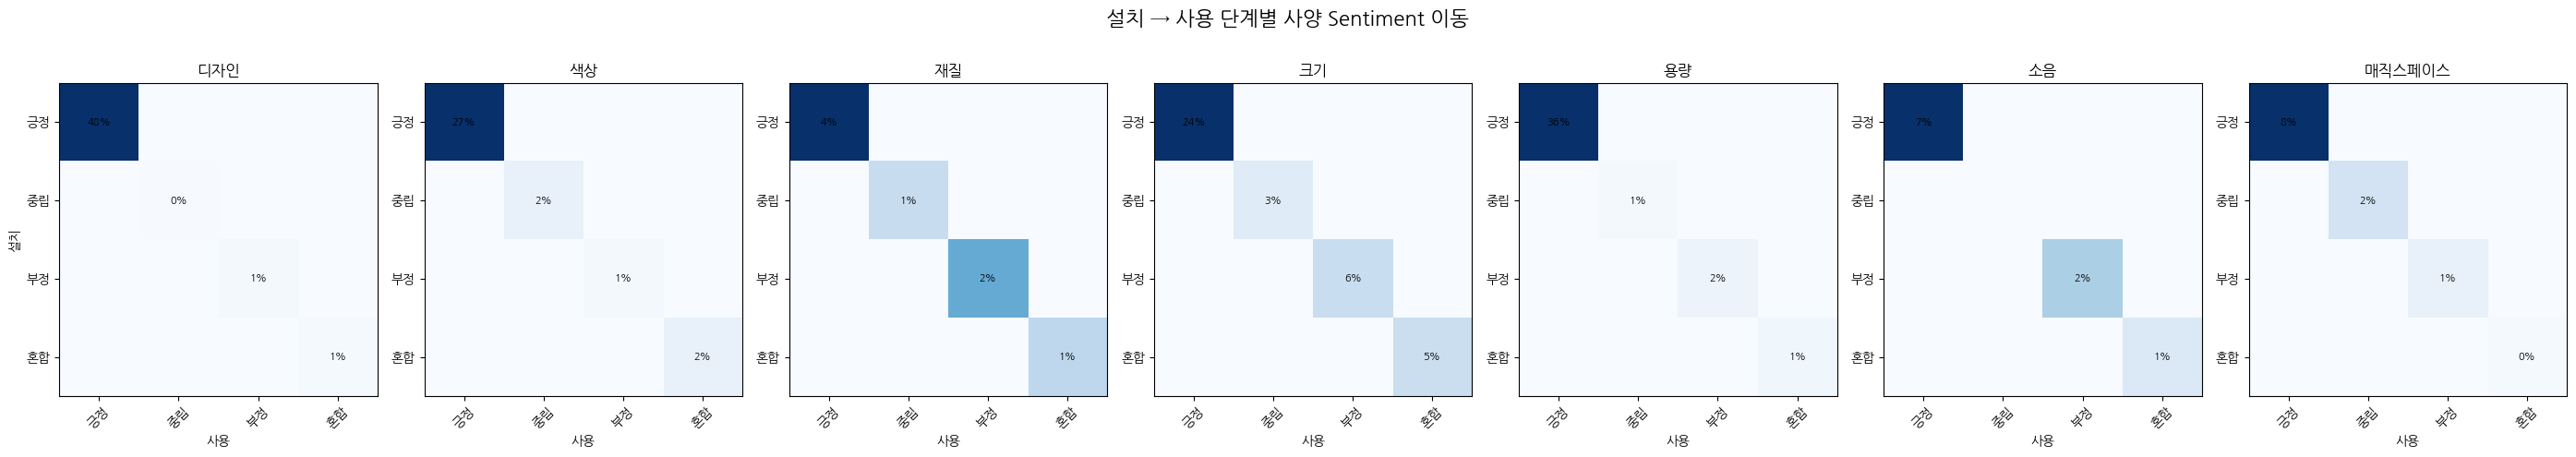

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================
# 단계 간 관계 분석:
# 행 = 이전 단계 / 열 = 다음 단계
# 각 셀 = 같은 review_id에서 특정 사양 sentiment 조합
# 예: 설치(부정) → 사용(긍정)
# =========================================

spec_cols_vis = ['디자인', '색상', '재질', '크기', '용량', '소음', '매직스페이스']

# 분석할 단계쌍
stage_pairs = [
    ('구매', '설치'),
    ('설치', '사용')
]

# sentiment 축
sentiments = ['positive', 'neutral', 'negative', 'mixed']
sentiment_kor = {
    'positive': '긍정',
    'neutral': '중립',
    'negative': '부정',
    'mixed': '혼합'
}


for prev_stage, next_stage in stage_pairs:

    print(f"\n========== {prev_stage} → {next_stage} 단계 관계 ==========\n")

    # 단계별 review_id 단위로 축약
    prev_df = (
        text_df[text_df["CEJ_stage"] == prev_stage]
        .drop_duplicates("review_id")
        .copy()
    )

    next_df = (
        text_df[text_df["CEJ_stage"] == next_stage]
        .drop_duplicates("review_id")
        .copy()
    )

    # 공통 review만
    common_ids = set(prev_df["review_id"]) & set(next_df["review_id"])

    prev_df = prev_df[prev_df["review_id"].isin(common_ids)]
    next_df = next_df[next_df["review_id"].isin(common_ids)]

    # review_id 기준 병합
    merged = pd.merge(
        prev_df,
        next_df,
        on="review_id",
        suffixes=(f"_{prev_stage}", f"_{next_stage}")
    )

    print(f"공통 리뷰 수: {len(merged)}")


    # =========================================
    # 사양별 heatmap
    # =========================================
    fig, axes = plt.subplots(
        1,
        len(spec_cols_vis),
        figsize=(4 * len(spec_cols_vis), 5)
    )

    fig.suptitle(
        f"{prev_stage} → {next_stage} 단계별 사양 Sentiment 이동",
        fontsize=16
    )

    if len(spec_cols_vis) == 1:
        axes = [axes]


    for idx, spec in enumerate(spec_cols_vis):

        prev_col = f"{spec}_sentiment_{prev_stage}"
        next_col = f"{spec}_sentiment_{next_stage}"

        ax = axes[idx]

        # 컬럼 없으면 skip
        if prev_col not in merged.columns or next_col not in merged.columns:
            ax.axis("off")
            continue


        # sentiment matrix 생성
        matrix = pd.DataFrame(
            0,
            index=sentiments,
            columns=sentiments
        )

        for s1 in sentiments:
            for s2 in sentiments:
                count = merged[
                    (merged[prev_col] == s1) &
                    (merged[next_col] == s2)
                ].shape[0]

                matrix.loc[s1, s2] = count


        # 비율화 (%)
        if len(merged) > 0:
            matrix_pct = matrix / len(merged) * 100
        else:
            matrix_pct = matrix


        # heatmap
        im = ax.imshow(
            matrix_pct.values,
            cmap="Blues",
            aspect="auto"
        )

        ax.set_xticks(range(len(sentiments)))
        ax.set_xticklabels(
            [sentiment_kor[s] for s in sentiments],
            rotation=45
        )

        ax.set_yticks(range(len(sentiments)))
        ax.set_yticklabels(
            [sentiment_kor[s] for s in sentiments]
        )

        ax.set_title(spec)

        ax.set_xlabel(f"{next_stage}")
        if idx == 0:
            ax.set_ylabel(f"{prev_stage}")

        # 수치 표시
        for i in range(len(sentiments)):
            for j in range(len(sentiments)):
                val = matrix_pct.values[i, j]

                if val > 0:
                    ax.text(
                        j,
                        i,
                        f"{val:.0f}%",
                        ha="center",
                        va="center",
                        fontsize=8
                    )


    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()

In [ ]:
import pandas as pd

# =========================================
# review_id 단위로 CEJ_sentiment 혼합 여부 분석
# (한 리뷰 안에 positive / negative / neutral / mixed가 어떻게 섞이는지)
# =========================================

# 1. review_id별 sentiment 집합
review_sentiment_summary = (
    text_df.groupby("review_id")["CEJ_sentiment"]
    .apply(lambda x: sorted(set(x.dropna())))
    .reset_index()
)

# 2. 조합 문자열화
review_sentiment_summary["sentiment_combo"] = review_sentiment_summary[
    "CEJ_sentiment"
].apply(lambda x: " + ".join(x))

# 3. 빈도 계산
combo_counts = (
    review_sentiment_summary["sentiment_combo"]
    .value_counts()
    .reset_index()
)

combo_counts.columns = ["sentiment_combo", "review_count"]

# 4. 비율
combo_counts["ratio_%"] = (
    combo_counts["review_count"] / combo_counts["review_count"].sum() * 100
).round(2)


# =========================================
# 출력
# =========================================
print("=== 한 리뷰 내 감정 조합 빈도 ===\n")
print(combo_counts)


# =========================================
# 핵심: 긍/부 동시 존재 리뷰
# =========================================
mixed_pos_neg = review_sentiment_summary[
    review_sentiment_summary["CEJ_sentiment"].apply(
        lambda x: ("positive" in x) and ("negative" in x)
    )
]

print("\n=== 긍정 + 부정 동시 존재 리뷰 ===")
print(f"리뷰 수: {len(mixed_pos_neg)}개")
print(
    f"비율: {len(mixed_pos_neg) / len(review_sentiment_summary) * 100:.2f}%"
)


# =========================================
# 샘플 리뷰 보기
# =========================================
sample_ids = mixed_pos_neg["review_id"].head(10)

print("\n=== 긍/부 혼합 리뷰 샘플 ===\n")

for idx, rid in enumerate(sample_ids, start=1):

    review_rows = text_df[text_df["review_id"] == rid]

    print(f"[{idx}] review_id: {rid}")
    print(f"전체 리뷰: {review_rows.iloc[0]['review_text']}\n")

    for _, row in review_rows.iterrows():
        print(
            f" - {row['CEJ_stage']} | {row['CEJ_sentiment']} | "
            f"{row['CEJ_item']} | {row['CEJ_evidence']}"
        )

    print("-" * 80)

=== 한 리뷰 내 감정 조합 빈도 ===

                          sentiment_combo  review_count  ratio_%
0                                positive          1844    65.23
1                      neutral + positive           484    17.12
2                     negative + positive           206     7.29
3           negative + neutral + positive           130     4.60
4                        mixed + positive            40     1.41
5                                 neutral            26     0.92
6                                negative            25     0.88
7                      negative + neutral            19     0.67
8             mixed + negative + positive            18     0.64
9              mixed + neutral + positive            13     0.46
10  mixed + negative + neutral + positive             8     0.28
11                       mixed + negative             6     0.21
12                                  mixed             4     0.14
13                                                    2     0.07


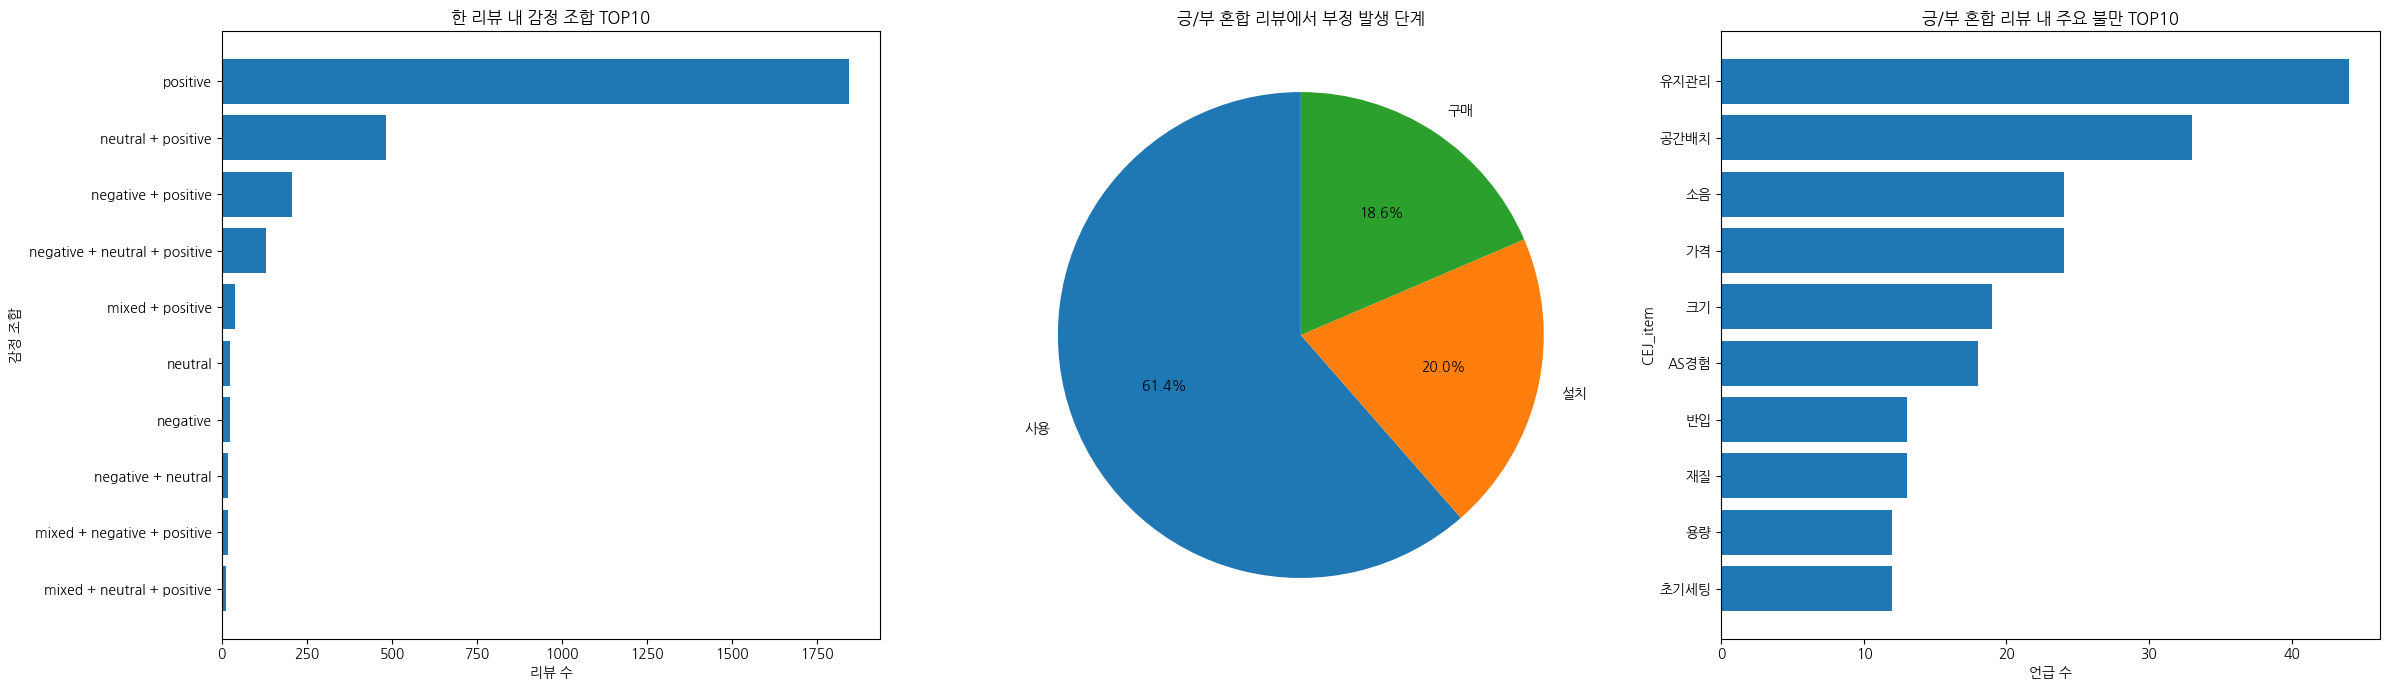

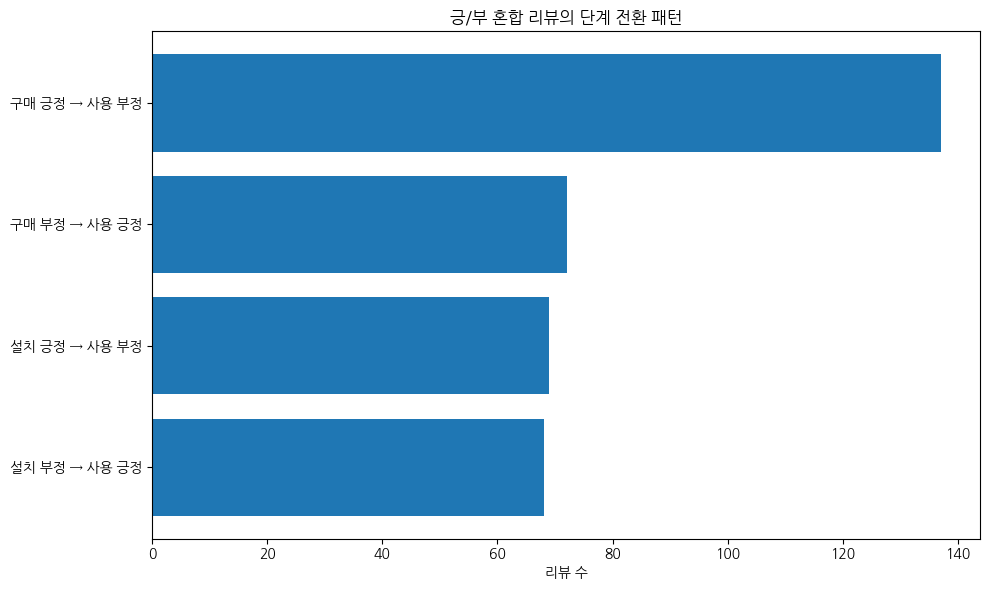

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# =========================================
# 1. 감정 조합 분포 (전체)
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Top sentiment combo
top_combo = combo_counts.head(10).copy()

axes[0].barh(
    top_combo["sentiment_combo"][::-1],
    top_combo["review_count"][::-1]
)

axes[0].set_title("한 리뷰 내 감정 조합 TOP10")
axes[0].set_xlabel("리뷰 수")
axes[0].set_ylabel("감정 조합")


# =========================================
# 2. 긍/부 혼합 리뷰 단계별 negative 발생 위치
# =========================================
mixed_ids = set(mixed_pos_neg["review_id"])

mixed_df = text_df[text_df["review_id"].isin(mixed_ids)]

negative_stage_counts = (
    mixed_df[mixed_df["CEJ_sentiment"] == "negative"]["CEJ_stage"]
    .value_counts()
)

axes[1].pie(
    negative_stage_counts.values,
    labels=negative_stage_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("긍/부 혼합 리뷰에서 부정 발생 단계")


# =========================================
# 3. 긍/부 혼합 리뷰 negative item TOP10
# =========================================
negative_items = (
    mixed_df[mixed_df["CEJ_sentiment"] == "negative"]["CEJ_item"]
    .value_counts()
    .head(10)
)

axes[2].barh(
    negative_items.index[::-1],
    negative_items.values[::-1]
)

axes[2].set_title("긍/부 혼합 리뷰 내 주요 불만 TOP10")
axes[2].set_xlabel("언급 수")
axes[2].set_ylabel("CEJ_item")


plt.tight_layout()
plt.show()


# =========================================
# 4. 단계 전환 매트릭스
# 설치 부정 → 사용 긍정 / 구매 부정 → 사용 긍정 등
# =========================================

transition_patterns = {
    "구매 부정 → 사용 긍정": 0,
    "설치 부정 → 사용 긍정": 0,
    "구매 긍정 → 사용 부정": 0,
    "설치 긍정 → 사용 부정": 0,
}

for rid in mixed_ids:

    review = text_df[text_df["review_id"] == rid]

    purchase_sent = set(review[review["CEJ_stage"] == "구매"]["CEJ_sentiment"])
    install_sent = set(review[review["CEJ_stage"] == "설치"]["CEJ_sentiment"])
    use_sent = set(review[review["CEJ_stage"] == "사용"]["CEJ_sentiment"])

    if "negative" in purchase_sent and "positive" in use_sent:
        transition_patterns["구매 부정 → 사용 긍정"] += 1

    if "negative" in install_sent and "positive" in use_sent:
        transition_patterns["설치 부정 → 사용 긍정"] += 1

    if "positive" in purchase_sent and "negative" in use_sent:
        transition_patterns["구매 긍정 → 사용 부정"] += 1

    if "positive" in install_sent and "negative" in use_sent:
        transition_patterns["설치 긍정 → 사용 부정"] += 1


# 시각화
plt.figure(figsize=(10, 6))

transition_series = pd.Series(transition_patterns).sort_values()

plt.barh(
    transition_series.index,
    transition_series.values
)

plt.title("긍/부 혼합 리뷰의 단계 전환 패턴")
plt.xlabel("리뷰 수")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================
# 구매 긍정 → 사용 부정 리뷰 상세 확인
# =========================================

# 1. 해당 review_id 추출
purchase_pos_use_neg_ids = []

for rid in mixed_ids:

    review = text_df[text_df["review_id"] == rid]

    purchase_sent = set(
        review[review["CEJ_stage"] == "구매"]["CEJ_sentiment"]
    )

    use_sent = set(
        review[review["CEJ_stage"] == "사용"]["CEJ_sentiment"]
    )

    if "positive" in purchase_sent and "negative" in use_sent:
        purchase_pos_use_neg_ids.append(rid)


print(f"구매 긍정 → 사용 부정 리뷰 수: {len(purchase_pos_use_neg_ids)}개")


# =========================================
# 2. 리뷰 품질 필터
# - CEJ 행 3개 이상
# - 리뷰 길이 긴 순
# =========================================
candidate_reviews = []

for rid in purchase_pos_use_neg_ids:

    review_rows = text_df[text_df["review_id"] == rid]

    review_text = str(review_rows.iloc[0]["review_text"])
    cej_count = len(review_rows)

    # 너무 짧은 리뷰 제외
    if len(review_text) < 50:
        continue

    candidate_reviews.append({
        "review_id": rid,
        "text_len": len(review_text),
        "cej_count": cej_count,
        "review_text": review_text
    })


# 길이 + 정보량 기준 정렬
candidate_reviews = sorted(
    candidate_reviews,
    key=lambda x: (x["text_len"], x["cej_count"]),
    reverse=True
)


# =========================================
# 3. 상위 15개 리뷰 출력
# =========================================
print("\n=== 구매 긍정 → 사용 부정 대표 리뷰 ===\n")

for idx, candidate in enumerate(candidate_reviews[:15], start=1):

    rid = candidate["review_id"]

    review_rows = (
        text_df[text_df["review_id"] == rid]
        .sort_values(["CEJ_stage"])
    )

    print(f"[{idx}] review_id: {rid}")
    print(f"리뷰 길이: {candidate['text_len']} | CEJ 행 수: {candidate['cej_count']}")
    print(f"전체 리뷰:\n{candidate['review_text']}\n")

    print("단계별 세부:")

    for _, row in review_rows.iterrows():
        print(
            f" - {row['CEJ_stage']} | {row['CEJ_sentiment']} | "
            f"{row['CEJ_item']} | {row['CEJ_evidence']}"
        )

    print("-" * 100)

구매 긍정 → 사용 부정 리뷰 수: 137개

=== 구매 긍정 → 사용 부정 대표 리뷰 ===

[1] review_id: 447887
리뷰 길이: 1212 | CEJ 행 수: 11
전체 리뷰:
15년이상된 냉장고 후면을 청소하다가 힘들게 빼고 청소기로 빨아들여도 안에 부품안까지 깨끗하게 빨아들일수도 없고 청소가 불가능하더라구요  먼지가 부품 구석구석까지 완전히 둘러쌓여 있었구요 ㅡㅜ 그걸 본이상 냉장고가 오래되고 패킹이 접착이 떨어져서 구매하려고 생각은 가지고 있었습니다. 으뜸효율도 환급되고 국가에서 소비쿠폰도 나와 의미있는 곳에 샀다고 여기는 안되지만 다른곳에 필요한곳에 이용하고 15년된 냉장고와 김치냉장고를 선택했습니다. LG전자 세일을 하길래 삼*과 비교도 하였지만 초딩아이 둘을 키우는 저에게는 아이들이 편하게 열고 닫을수 있는 매직스페이스가 필요했고, 특히 아이들이 열고 닫기 편한 오토버튼과 스무스한 오토클로징 기능이 있어 아이들이 사용하기 편하겠다 싶어 둘다 비교하고 닫아보고 구매했습니다. 저처럼 초등아이들이 냉장고를 열고닫기에는 오토버튼과 스무스한 오토클로징 기능이 있는걸 추천드립니다. 안되있는 경쟁사것을 비교해보니 확실히 있는게 여닫기가 훨 편하더라구요. 아이들이 있는 집에서는 적극 이모델 추천드립니다. 초딩아이가 너무 놓다며 매직스페이스에 본인의 우유 쥬스 소스 케찹 간식을 채워주시 편하게 자기 공간이라며 꺼내먹을수도 있고 문여는 스위치가 따로 있어 너무 좋아하더라구요 ^^ 냉장실엔 계란 넣을 작은 서랍도 있고 문짝에 분리칸막이도 2개나 들어있어서 소스류들이 문 열고닫음에 흔들이지 않게 고정도 되더라구요 다른 냉장고모델도 비교했었는데 전기료 절감되는 1등급 모델에다 아이들이 손쉽게 혹은 어른들도 훨씬 편하게 여닫고 닫히는 오토 클로징 버튼 ,  아이들이 공간 매직 스페이스까지 이 모델 추천드립니다. 김치냉장고 까지 같이 구매했는데요  원래 같이 구매해야 색상도 통일되고 부엌이 따로놀지 않고 조화롭더라구요  저처럼 오래되고 연식이 되어 바꾸실 

In [ ]:
# =========================================
# 각 전환 패턴별 "더 풍부한" 리뷰 찾기
# 조건:
# - review_text 길이 긴 편
# - CEJ 행 3개 이상
# =========================================

transition_candidates = {
    "구매 부정 → 사용 긍정": [],
    "설치 부정 → 사용 긍정": [],
    "구매 긍정 → 사용 부정": [],
    "설치 긍정 → 사용 부정": [],
}

for rid in mixed_ids:

    review = text_df[text_df["review_id"] == rid]

    purchase_sent = set(
        review[review["CEJ_stage"] == "구매"]["CEJ_sentiment"]
    )

    install_sent = set(
        review[review["CEJ_stage"] == "설치"]["CEJ_sentiment"]
    )

    use_sent = set(
        review[review["CEJ_stage"] == "사용"]["CEJ_sentiment"]
    )

    review_text = str(review.iloc[0]["review_text"])
    cej_count = len(review)

    # 너무 짧거나 정보 적은 리뷰 제외
    if len(review_text) < 80 or cej_count < 3:
        continue

    if "negative" in purchase_sent and "positive" in use_sent:
        transition_candidates["구매 부정 → 사용 긍정"].append(
            (rid, len(review_text), cej_count)
        )

    if "negative" in install_sent and "positive" in use_sent:
        transition_candidates["설치 부정 → 사용 긍정"].append(
            (rid, len(review_text), cej_count)
        )

    if "positive" in purchase_sent and "negative" in use_sent:
        transition_candidates["구매 긍정 → 사용 부정"].append(
            (rid, len(review_text), cej_count)
        )

    if "positive" in install_sent and "negative" in use_sent:
        transition_candidates["설치 긍정 → 사용 부정"].append(
            (rid, len(review_text), cej_count)
        )


# =========================================
# 가장 풍부한 리뷰 출력 (길이순)
# =========================================
for pattern, candidates in transition_candidates.items():

    print(f"\n========== {pattern} ==========")

    if not candidates:
        print("적절한 리뷰 없음")
        continue

    # 길이 긴 순 정렬
    candidates = sorted(
        candidates,
        key=lambda x: (x[1], x[2]),
        reverse=True
    )

    # 가장 좋은 후보 선택
    rid = candidates[0][0]

    review_rows = text_df[text_df["review_id"] == rid]

    print(f"review_id: {rid}")
    print(f"리뷰 길이: {candidates[0][1]}자")
    print(f"CEJ 행 수: {candidates[0][2]}개\n")

    print("전체 리뷰:")
    print(review_rows.iloc[0]["review_text"])

    print("\n단계별 세부:")
    for _, row in review_rows.iterrows():
        print(
            f" - {row['CEJ_stage']} | {row['CEJ_sentiment']} | "
            f"{row['CEJ_item']} | {row['CEJ_evidence']}"
        )

    print("-" * 100)


========== 구매 부정 → 사용 긍정 ==========
review_id: 454146
리뷰 길이: 563자
CEJ 행 수: 9개

전체 리뷰:
위니아 냉장고를 19년도에 3도어로 샀는데 냉동아 안되어서 찾아보니 똑같은 고장수리가 많더라고요 에어컨이랑 티지를 엘지로 사게 되어 또 엘지로 눈이 가게되더라고요 아는 지인도 최근에 냉장고를 사서 이참에 바꿔 보자는 생각이 들어버렸지요.. 3일동안 고민고민하다 도저히 안되어서 월요일에 샀는데 바로 그담날 배송일자가 되네요??10시에 신청했지만 담당설치기사님 연락을 기다리는 시간이 너무 길었어요고객센터에서 물어보니  6시 이후로 천천히 온다고 하더라고요 그래서 기다리고 있었고 사다리차까지 그담날 배정이 딱!! 우리집에 에어컨 실외기설치위치랑 거실에서 주방으로 가는 거실이 좁다보니  어렵게 올려서 문다 푸시고 설치기사님이 엄청 고생하셨는데도 불구하고 웃으시면서 설명까지 잘해주셨어요 냉장고 솔직히 고민 많이 했는데 기존 냉장고보다 더 여유있게 들어가고 특히 냉동실은 다 서랍형태라서 뭔가 떨어지거나 그러지 않을거같더라구요 안에도 엄청 넓고 엄청 깊어요  남자어른 팔 하나는 그냥 끝까지 들어가고도 남는다고 보시면 됩니다 사진은 외관만 찍어올려요 추천드립니다 무조건!!저 참고로 엘지직원 절대 아닙니다!!

단계별 세부:
 - 구매 | positive | 구매결정 | 도저히 안되어서 월요일에 샀는데
 - 구매 | mixed | 배송 | 바로 그담날 배송일자가 되네요??
 - 구매 | negative | 구매고민 | 3일동안 고민고민하다
 - 설치 | positive | 설치기사 | 설치기사님이 엄청 고생하셨는데도 불구하고 웃으시면서 설명까지 잘해주셨어요
 - 설치 | negative | 반입 | 어렵게 올려서
 - 설치 | negative | 공간배치 | 거실이 좁다보니
 - 사용 | positive | 수납공간 | 기존 냉장고보다 더 여유있게 들어가고
 - 사용 | positive | 냉동실 구조 | 냉동실은 다 서랍

In [ ]:
spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

# 구매 긍정 review_id
buy_pos_ids = text_df[
    (text_df['CEJ_stage'] == '구매') &
    (text_df['CEJ_sentiment'] == 'positive')
]['review_id'].unique()

# 사용 부정 review_id
use_neg_ids = text_df[
    (text_df['CEJ_stage'] == '사용') &
    (text_df['CEJ_sentiment'] == 'negative')
]['review_id'].unique()

# 구매 긍정 -> 사용 부정 세그
target_ids = set(buy_pos_ids) & set(use_neg_ids)

segment_df = text_df[
    text_df['review_id'].isin(target_ids)
].drop_duplicates('review_id')

print(f"구매 긍정 → 사용 부정 리뷰 수: {len(segment_df)}개")

print(f"\n{'사양':<12} {'언급률':>8} {'긍정':>8} {'부정':>8} {'중립':>8} {'혼합':>8}")
print("-"*65)

for spec in spec_cols:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    if mentioned_col not in segment_df.columns:
        continue

    mentioned = segment_df[segment_df[mentioned_col] == True]
    total = len(mentioned)

    if total == 0:
        continue

    pos = mentioned[mentioned[sentiment_col] == 'positive'].shape[0]
    neg = mentioned[mentioned[sentiment_col] == 'negative'].shape[0]
    neu = mentioned[mentioned[sentiment_col] == 'neutral'].shape[0]
    mix = mentioned[mentioned[sentiment_col] == 'mixed'].shape[0]

    mention_rate = total / len(segment_df) * 100

    print(
        f"{spec:<12} "
        f"{mention_rate:>7.1f}% "
        f"{pos/total*100:>7.1f}% "
        f"{neg/total*100:>7.1f}% "
        f"{neu/total*100:>7.1f}% "
        f"{mix/total*100:>7.1f}%"
    )

구매 긍정 → 사용 부정 리뷰 수: 137개

사양                언급률       긍정       부정       중립       혼합
-----------------------------------------------------------------
디자인             52.6%    91.7%     1.4%     1.4%     5.6%
색상              32.8%    60.0%     4.4%    17.8%    17.8%
재질              20.4%    14.3%    57.1%    14.3%    14.3%
크기              35.0%    33.3%    31.2%     4.2%    31.2%
용량              41.6%    70.2%    14.0%     3.5%    12.3%
소음              23.4%    18.8%    71.9%     0.0%     9.4%
오토클로징            9.5%    69.2%    23.1%     7.7%     0.0%
매직스페이스          19.7%    66.7%    11.1%    18.5%     3.7%
ThinQ            6.6%   100.0%     0.0%     0.0%     0.0%


In [ ]:
buy_pos_ids = set(text_df[
    (text_df['CEJ_stage']=='구매') &
    (text_df['CEJ_sentiment']=='positive')
]['review_id'])

use_neg_ids = set(text_df[
    (text_df['CEJ_stage']=='사용') &
    (text_df['CEJ_sentiment']=='negative')
]['review_id'])

target_ids = buy_pos_ids & use_neg_ids

segment_install = text_df[
    (text_df['review_id'].isin(target_ids)) &
    (text_df['CEJ_stage']=='설치')
]

all_install = text_df[text_df['CEJ_stage']=='설치']

print(f"구매 긍정 → 사용 부정 세그 중 설치 언급 리뷰 수: {segment_install['review_id'].nunique()}개")
print(f"전체 설치 리뷰 수: {all_install['review_id'].nunique()}개")

print("\n=== 설치 단계 감정 분포 (세그) ===")
seg_sent = segment_install['CEJ_sentiment'].value_counts(normalize=True) * 100
print(seg_sent.round(1))

print("\n=== 설치 단계 감정 분포 (전체) ===")
all_sent = all_install['CEJ_sentiment'].value_counts(normalize=True) * 100
print(all_sent.round(1))

print(f"\n{'설치 항목':<15} {'세그':>8} {'전체':>8} {'차이':>8}")
print("-"*50)

seg_items = segment_install['CEJ_item'].value_counts()
all_items = all_install['CEJ_item'].value_counts()

top_items = set(seg_items.head(10).index)

for item in top_items:
    seg_count = seg_items.get(item, 0)
    all_count = all_items.get(item, 0)

    seg_rate = seg_count / len(segment_install) * 100 if len(segment_install) > 0 else 0
    all_rate = all_count / len(all_install) * 100 if len(all_install) > 0 else 0

    diff = seg_rate - all_rate
    direction = "↑" if diff > 0 else "↓"

    print(
        f"{item:<15} "
        f"{seg_rate:>7.1f}% "
        f"{all_rate:>7.1f}% "
        f"{direction}{abs(diff):>5.1f}%p"
    )

print("\n=== 설치 부정 리뷰 샘플 ===")
neg_samples = segment_install[
    segment_install['CEJ_sentiment'].isin(['negative', 'mixed'])
].drop_duplicates('review_id').head(10)

for _, row in neg_samples.iterrows():
    print(f"\nreview_id: {row['review_id']}")
    print(row['review_text'][:300])
    print("-"*70)

구매 긍정 → 사용 부정 세그 중 설치 언급 리뷰 수: 79개
전체 설치 리뷰 수: 966개

=== 설치 단계 감정 분포 (세그) ===
CEJ_sentiment
positive    58.2
negative    23.1
neutral     17.2
mixed        1.5
Name: proportion, dtype: float64

=== 설치 단계 감정 분포 (전체) ===
CEJ_sentiment
positive    75.7
neutral     13.3
negative    10.0
mixed        1.0
Name: proportion, dtype: float64

설치 항목                 세그       전체       차이
--------------------------------------------------
이사                  1.5%     2.6% ↓  1.2%p
설치                 12.6%    17.2% ↓  4.6%p
설치기사               18.5%    19.9% ↓  1.4%p
반입                  3.0%     2.7% ↑  0.2%p
배송                  1.5%     3.5% ↓  2.0%p
설명                  1.5%     1.6% ↓  0.1%p
초기세팅                5.2%     4.3% ↑  0.8%p
테이프 제거              1.5%     0.1% ↑  1.3%p
설치과정                5.2%     4.2% ↑  1.0%p
공간배치               23.0%    17.0% ↑  6.0%p

=== 설치 부정 리뷰 샘플 ===

review_id: 470257
16년간 써온 디오스 냉장고에 에러가 떴어요. 일단 as를 한번 받아보자하고 신청하니 기사님이 오셔서 냉장실쪽에 성에를 녹이는 부분이 망가졌는데 부품이 없다고 하네요. 16년이나  

In [ ]:
# "구매 긍정 → 사용 부정" 고객 분석
# 구매단계에서 뭘 좋다고 했나
# 사용단계에서 뭐가 불만이었나

# 1. 해당 review_id 추출
buy_pos_ids = text_df[
    text_df['CEJ_stage'] == '구매'
].groupby('review_id')['CEJ_sentiment'].apply(
    lambda x: (x == 'positive').any()
)
buy_pos_ids = buy_pos_ids[buy_pos_ids].index

use_neg_ids = text_df[
    text_df['CEJ_stage'] == '사용'
].groupby('review_id')['CEJ_sentiment'].apply(
    lambda x: (x == 'negative').any()
)
use_neg_ids = use_neg_ids[use_neg_ids].index

# 교집합
target_ids = set(buy_pos_ids) & set(use_neg_ids)
print(f"구매긍정→사용부정 리뷰 수: {len(target_ids)}")

# 2. 구매단계에서 뭘 좋다고 했나
buy_pos = text_df[
    (text_df['review_id'].isin(target_ids)) &
    (text_df['CEJ_stage'] == '구매') &
    (text_df['CEJ_sentiment'] == 'positive')
]
print("\n=== 구매단계 긍정 항목 ===")
print(buy_pos['CEJ_item'].value_counts().head(10))

# 3. 사용단계에서 뭐가 불만이었나
use_neg = text_df[
    (text_df['review_id'].isin(target_ids)) &
    (text_df['CEJ_stage'] == '사용') &
    (text_df['CEJ_sentiment'] == 'negative')
]
print("\n=== 사용단계 부정 항목 ===")
print(use_neg['CEJ_item'].value_counts().head(10))

구매긍정→사용부정 리뷰 수: 137

=== 구매단계 긍정 항목 ===
CEJ_item
구매결정     69
가격       41
배송       17
가성비      13
AS기대감     4
환급        3
디자인       3
구매만족      2
구매추천      2
가격대비      2
Name: count, dtype: int64

=== 사용단계 부정 항목 ===
CEJ_item
유지관리     31
소음       16
AS경험     12
얼음트레이     6
편의성       6
기능작동      5
고장        5
재질        4
냉기        3
오토클로징     3
Name: count, dtype: int64


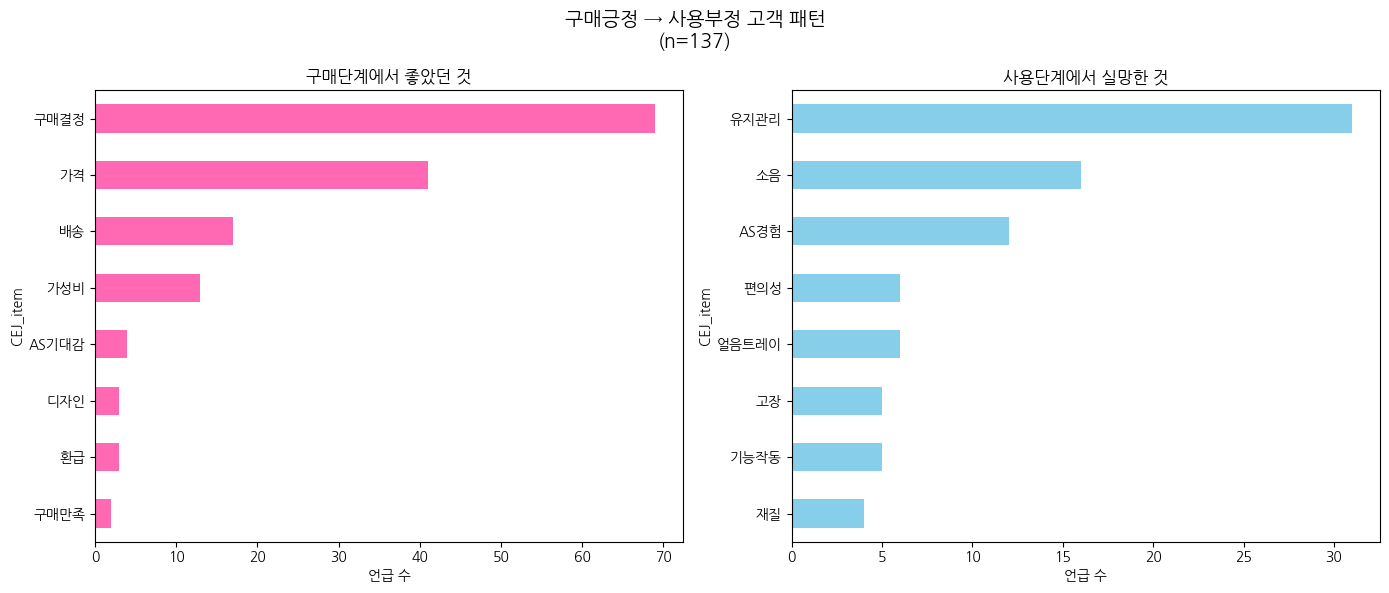


=== 구매긍정→사용부정 리뷰 샘플 ===

[review_id: 416264]
새 아파트에 입주한다고 가전 싹 바꾸면서 LG 냉장고 사러 현대백화점 갔다가 그 당시 소지섭 씨를 내세워 위니아에서 밀던 4룸 프라우드 냉장고에 혹 해서 주문했다가 2년 후부터 냉장실 소음에 대형 얼음 생기고 물 나오고 … 12년 동안 얼음 떼느라 내 팔뚝 개고생!ㅠㅠ 이번에 냉장고 바꾸면서는 첨부터 LG 모델만 검색해서 주문! 1등급 10% 환급대상 제품에 군더더기 없는 심플한 스타일의 냉장고라 너무 마음에 들어요! 고장 없이 오래오래 함께 했으면 좋겠어요!💙
--------------------------------------------------

[review_id: 569352]
너무 이뻐요 😍 김치냉장고도 바꾸고 싶네요 설치는 빠르게 해주셨습니다. 일주일도 안되서 설치 했네요 냉장 높이는 전에 쓰던 냉장고 보다 낮은감있네요~~ 냉동용기 어여 사야겠어요~~
--------------------------------------------------

[review_id: 477203]
시골에 엘지 양문형 냉장고를 구입하고 15년을 썼더니 콤프레샤가 나갔네요 ㅠㅠ 급하게 알아보고 구입했는데 빨리 배송이 와서 깜짝 놀랬어요 ㅎㅎ 오랫동안 고장없이 잘 썼음 좋겠습니다 ~~
--------------------------------------------------


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('구매긍정 → 사용부정 고객 패턴\n(n=137)', fontsize=14)

# 구매단계 긍정
buy_counts = buy_pos['CEJ_item'].value_counts().head(8)
buy_counts.sort_values().plot(
    kind='barh', ax=axes[0], color='#FF69B4'
)
axes[0].set_title('구매단계에서 좋았던 것')
axes[0].set_xlabel('언급 수')

# 사용단계 부정
use_counts = use_neg['CEJ_item'].value_counts().head(8)
use_counts.sort_values().plot(
    kind='barh', ax=axes[1], color='#87CEEB'
)
axes[1].set_title('사용단계에서 실망한 것')
axes[1].set_xlabel('언급 수')

plt.tight_layout()
plt.show()

# 실제 리뷰 샘플
print("\n=== 구매긍정→사용부정 리뷰 샘플 ===")
sample_ids = list(target_ids)[:3]
for rid in sample_ids:
    review = text_df[text_df['review_id'] == rid]['review_text'].iloc[0]
    print(f"\n[review_id: {rid}]")
    print(review[:300])
    print("-"*50)

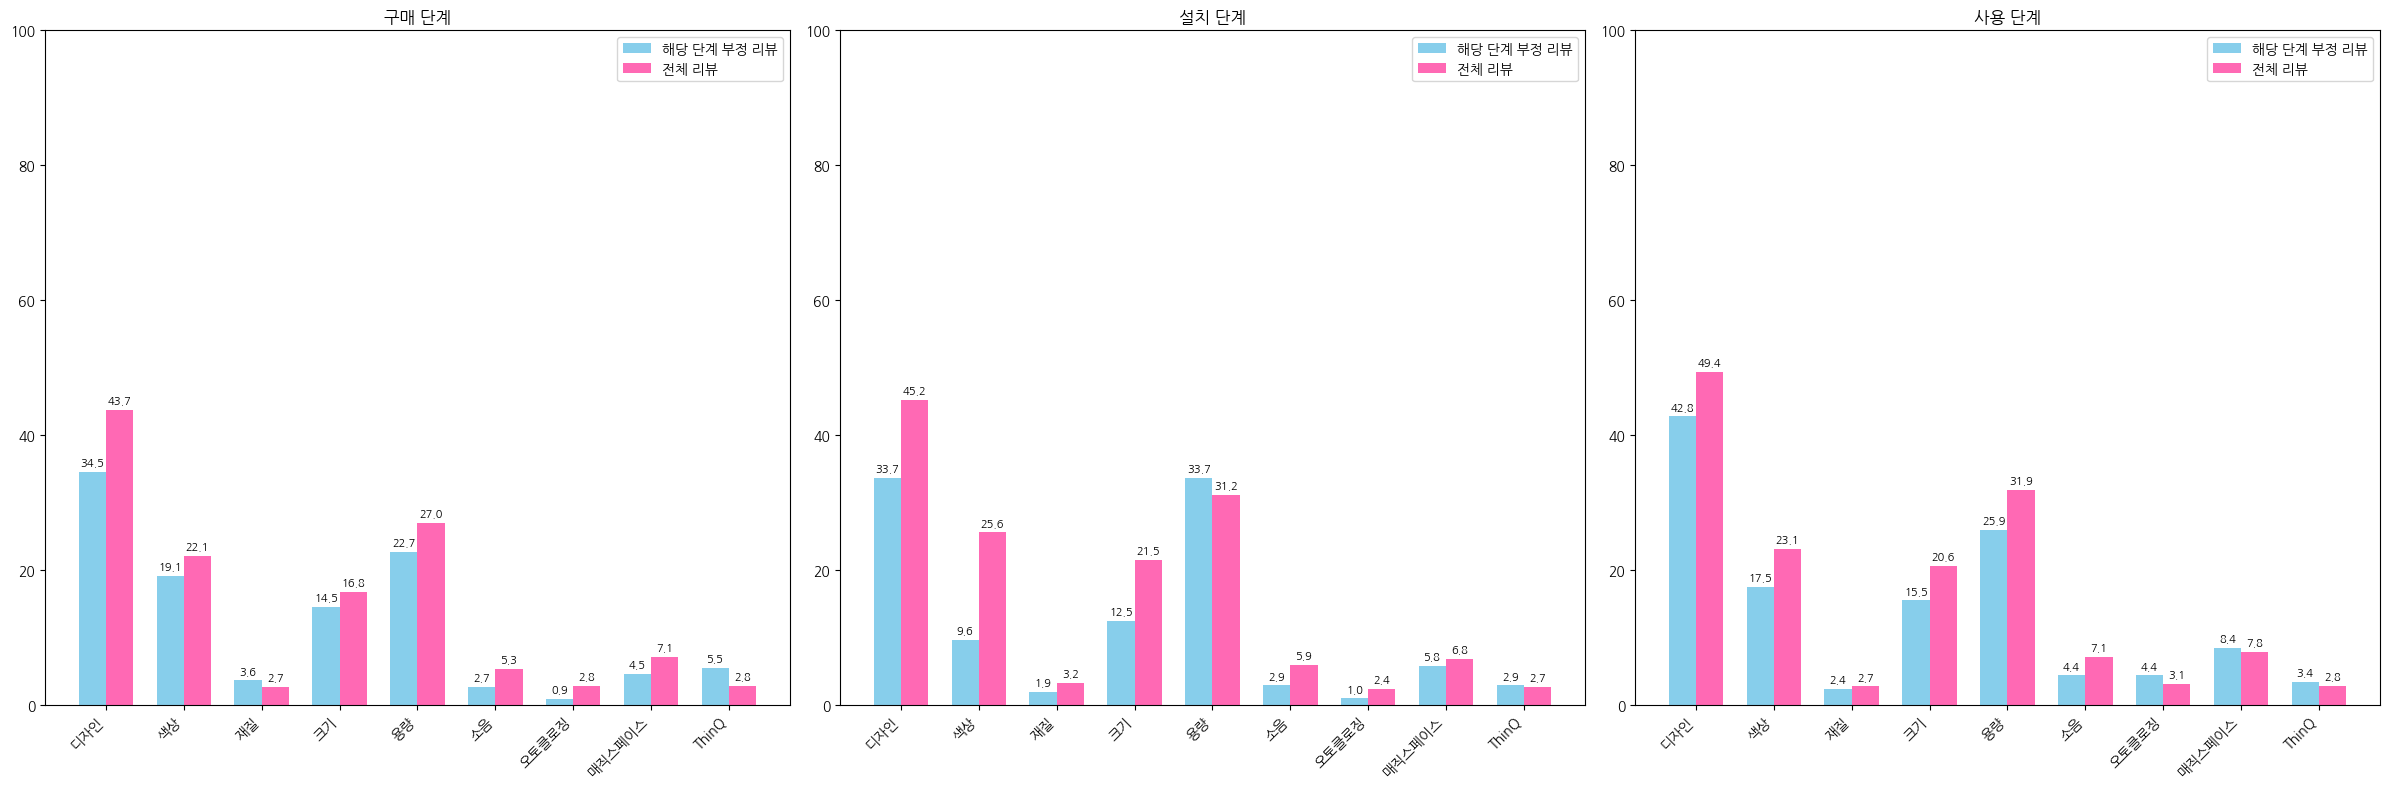

    단계      사양  전체 긍정비율(%)  부정리뷰 긍정비율(%)
0   구매     디자인        43.7          34.5
1   구매      색상        22.1          19.1
2   구매      재질         2.7           3.6
3   구매      크기        16.8          14.5
4   구매      용량        27.0          22.7
5   구매      소음         5.3           2.7
6   구매   오토클로징         2.8           0.9
7   구매  매직스페이스         7.1           4.5
8   구매   ThinQ         2.8           5.5
9   설치     디자인        45.2          33.7
10  설치      색상        25.6           9.6
11  설치      재질         3.2           1.9
12  설치      크기        21.5          12.5
13  설치      용량        31.2          33.7
14  설치      소음         5.9           2.9
15  설치   오토클로징         2.4           1.0
16  설치  매직스페이스         6.8           5.8
17  설치   ThinQ         2.7           2.9
18  사용     디자인        49.4          42.8
19  사용      색상        23.1          17.5
20  사용      재질         2.7           2.4
21  사용      크기        20.6          15.5
22  사용      용량        31.9          25.9
23  사용      소음  

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

spec_cols = ['디자인','색상','재질','크기','용량','소음','오토클로징','매직스페이스','ThinQ']
stages = ['구매','설치','사용']

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
results = []

for i, stage in enumerate(stages):

    all_df = text_df[text_df['CEJ_stage'] == stage].drop_duplicates('review_id')

    neg_ids = text_df[
        (text_df['CEJ_stage'] == stage) &
        (text_df['CEJ_sentiment'] == 'negative')
    ]['review_id'].unique()

    neg_df = text_df[
        (text_df['review_id'].isin(neg_ids)) &
        (text_df['CEJ_stage'] == stage)
    ].drop_duplicates('review_id')

    all_n, neg_n = len(all_df), len(neg_df)

    all_rates, neg_rates = [], []

    for spec in spec_cols:
        m_col = f'{spec}_mentioned'
        s_col = f'{spec}_sentiment'

        all_rate = (
            all_df[(all_df[m_col]==True) & (all_df[s_col]=='positive')].shape[0] / all_n * 100
            if all_n > 0 else 0
        )

        neg_rate = (
            neg_df[(neg_df[m_col]==True) & (neg_df[s_col]=='positive')].shape[0] / neg_n * 100
            if neg_n > 0 else 0
        )

        all_rates.append(all_rate)
        neg_rates.append(neg_rate)

        results.append([stage, spec, round(all_rate,1), round(neg_rate,1)])

    x = np.arange(len(spec_cols))
    width = 0.35

    axes[i].bar(x - width/2, neg_rates, width, color='#87CEEB', label='해당 단계 부정 리뷰')
    axes[i].bar(x + width/2, all_rates, width, color='#FF69B4', label='전체 리뷰')

    axes[i].set_title(f'{stage} 단계')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(spec_cols, rotation=45, ha='right')
    axes[i].set_ylim(0, 100)

    for xi, val in zip(x - width/2, neg_rates):
        axes[i].text(xi, val+1, f'{val:.1f}', ha='center', fontsize=8)

    for xi, val in zip(x + width/2, all_rates):
        axes[i].text(xi, val+1, f'{val:.1f}', ha='center', fontsize=8)

    axes[i].legend()

plt.tight_layout()
plt.show()

result_df = pd.DataFrame(
    results,
    columns=['단계','사양','전체 긍정비율(%)','부정리뷰 긍정비율(%)']
)

print(result_df)

---

## 설치 단계

In [ ]:
# 설치 단계만 필터링
install_df = text_df[text_df['CEJ_stage'] == '설치'].copy()
print(f"설치 단계 행 수: {len(install_df)}")
print(f"설치 단계 unique 리뷰 수: {install_df['review_id'].nunique()}")

# CEJ_item 분포
print("\n=== 설치 단계 CEJ_item 분포 ===")
print(install_df['CEJ_item'].value_counts())

# sentiment 분포
print("\n=== 설치 단계 sentiment 분포 ===")
print(install_df['CEJ_sentiment'].value_counts())

설치 단계 행 수: 434
설치 단계 unique 리뷰 수: 296

=== 설치 단계 CEJ_item 분포 ===
CEJ_item
공간배치         90
설치           82
설치기사         74
초기세팅         17
이사           13
             ..
친절한 기사님들      1
새아파트 입주       1
사이즈도 잘 맞고     1
설치기사 설명       1
수거            1
Name: count, Length: 99, dtype: int64

=== 설치 단계 sentiment 분포 ===
CEJ_sentiment
positive    332
neutral      63
negative     28
mixed         3
Name: count, dtype: int64


In [ ]:
# 1. 항목별 sentiment 분포 (CS 점수 계산)
print("=== 항목별 CS 점수 ===")
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1, 'mixed': 0}

top_items = install_df['CEJ_item'].value_counts().head(10).index

summary = []
for item in top_items:
    subset = install_df[install_df['CEJ_item'] == item]
    attention = len(subset) / len(install_df)
    score = subset['CEJ_sentiment'].map(sentiment_map).mean()
    cs = attention * score
    summary.append({
        'item': item,
        '언급수': len(subset),
        '언급률': round(attention, 3),
        '만족도': round(score, 3),
        'CS점수': round(cs, 3)
    })

summary_df = pd.DataFrame(summary).sort_values('CS점수')
print(summary_df.to_string(index=False))

# 2. 부정 리뷰 evidence 보기
print("\n=== 부정 리뷰 Top 항목별 evidence ===")
for item in summary_df.head(3)['item']:
    neg = install_df[
        (install_df['CEJ_item'] == item) &
        (install_df['CEJ_sentiment'] == 'negative')
    ]['CEJ_evidence'].dropna().tolist()
    print(f"\n[{item}] 부정 {len(neg)}개")
    for t in neg[:5]:
        print(f"  - {t}")

=== 항목별 CS 점수 ===
item  언급수   언급률   만족도  CS점수
초기세팅   17 0.039 0.000 0.000
  이사   13 0.030 0.000 0.000
  반입   11 0.025 0.273 0.007
  크기   11 0.025 0.455 0.012
  배송   10 0.023 0.800 0.018
  설명    9 0.021 1.000 0.021
설치과정   12 0.028 0.909 0.025
공간배치   90 0.207 0.722 0.150
  설치   82 0.189 0.844 0.159
설치기사   74 0.171 0.959 0.164

=== 부정 리뷰 Top 항목별 evidence ===

[초기세팅] 부정 6개
  - 제품등록 하고 있네요
  - 선반 높낮이 조절이 어려운 것이 조금 아쉬워요
  - 처음에 선반 하나가 유격이 안맞아서 애먹었지만
  - 상부 도어 벌어짐이 다르네요
  - 안에 있던 음식물들을 꺼내놓고 다시 넣는데

[이사] 부정 0개

[반입] 부정 3개
  - 방문 폭을 잘못 측정해서 반품했는데
  - 아파트 현관문으로 못들어와
  - 비가 퍼붓는 날인데도


In [ ]:
# 수동 그룹핑
def group_item(item):
    if any(k in item for k in ['설치기사', '기사', '친절']):
        return '설치기사 경험'
    elif any(k in item for k in ['설치과정', '설치', '초기세팅', '제품설치']):
        return '설치 과정'
    elif any(k in item for k in ['공간배치', '공간', '크기', '배치']):
        return '공간/환경'
    elif any(k in item for k in ['배송', '시간', '일정', '약속']):
        return '배송/일정'
    else:
        return '기타'

install_df['item_group'] = install_df['CEJ_item'].apply(group_item)
print(install_df['item_group'].value_counts())

item_group
설치 과정      131
공간/환경      109
설치기사 경험    101
기타          80
배송/일정       13
Name: count, dtype: int64


In [ ]:
# 기타에 뭐가 있는지 확인
print(install_df[install_df['item_group'] == '기타']['CEJ_item'].value_counts().head(20))

CEJ_item
이사               13
반입               11
설명                9
이사하면서             3
교체                2
냉동고가 하부로 이동       1
상 하단 나뉘어져 있어서     1
꼼꼼하게 봐주셨어요        1
상하단 분리            1
새로 받았어요           1
AS                1
새집이사              1
미리 날짜 지정          1
재질                1
더편하고              1
인테리어 하면서 바꿨는데     1
아파트               1
AS/사후관리           1
가전 맞추기            1
사전 점검             1
Name: count, dtype: int64


In [ ]:
# 긍정/부정 분리
install_pos = install_df[install_df['CEJ_sentiment'] == 'positive']
install_neg = install_df[install_df['CEJ_sentiment'].isin(['negative', 'mixed'])]

print(f"긍정: {len(install_pos)}개")
print(f"부정: {len(install_neg)}개")

# evidence 샘플 확인
print("\n=== 긍정 evidence 샘플 ===")
for t in install_pos['CEJ_evidence'].dropna().sample(10).values:
    print(f"- {t}")

print("\n=== 부정 evidence 샘플 ===")
for t in install_neg['CEJ_evidence'].dropna().sample(10).values:
    print(f"- {t}")

긍정: 332개
부정: 31개

=== 긍정 evidence 샘플 ===
- 상담도 친절하시고
- 그 부분까지 손봐주실 정도로 세심하게 챙겨주셨어요
- 안전하게 설치해주셔서 만족합니다
- 문제 없이 설치 해주셨습니다
- 빠르고 안전한 배송
- 설명도 잘 해주셨습니다
- 작동법 친절히 설명해주셨ㅇ어요
- 어느 자리에 설치하면 좋을지 두곳을 비교하면서 설명해주셨고 최종 선택한 장소에 잘 설치해주셨습니다
- 기사님이 장 라인까지 맞춰주셨어요
- 친절하시구요

=== 부정 evidence 샘플 ===
- 제품등록 하고 있네요
- 4도어가 처음이신 어머님은 큰 통 보관은 좀 힘들겠다며
- 테이프 떼는거 빡세더라구요
- 깊이감이 있어 평균적인 할머니 키에는 불편함이 있습니다
- 냉장고자리에 딱 맞는건 아니라 아쉽긴 하지만
- 놓으려고 했던 공간은 놓지 못하고 다른 위치에 놓았습니다
- 비가 퍼붓는 날인데도
- 아파트 현관문으로 못들어와
- 처음에 선반 하나가 유격이 안맞아서 애먹었지만
- 우리 수납장이 비해 너무 큰 사이즈로 앞으로 돌출되어 있는 점이 아쉽네요


In [ ]:
# 설치 단계 긍정/부정 evidence 전체 단어 빈도 확인
from collections import Counter
import re

def get_word_freq(texts):
    words = []
    for text in texts.dropna():
        # 공백으로 분리
        words.extend(text.split())
    return Counter(words).most_common(30)

# 긍정 evidence 단어 빈도
pos_texts = install_df[install_df['CEJ_sentiment'] == 'positive']['CEJ_evidence']
neg_texts = install_df[install_df['CEJ_sentiment'].isin(['negative', 'mixed'])]['CEJ_evidence']

print(f"긍정 evidence 수: {len(pos_texts.dropna())}")
print(f"부정 evidence 수: {len(neg_texts.dropna())}")

print("\n=== 긍정 자주 나오는 단어 Top 30 ===")
for word, count in get_word_freq(pos_texts):
    print(f"  {word}: {count}")

print("\n=== 부정 자주 나오는 단어 Top 30 ===")
for word, count in get_word_freq(neg_texts):
    print(f"  {word}: {count}")

긍정 evidence 수: 332
부정 evidence 수: 31

=== 긍정 자주 나오는 단어 Top 30 ===
  설치: 39
  잘: 39
  너무: 28
  설치도: 26
  친절하게: 21
  친절하시고: 20
  기사님도: 17
  해주셨어요: 13
  친절하고: 12
  배송: 9
  설치해: 8
  기사님들도: 8
  냉장고: 8
  빠르게: 8
  해주시고: 8
  주시고: 7
  설치기사님도: 7
  설명도: 6
  꼼꼼하게: 6
  설명: 6
  오셔서: 6
  공간: 6
  해주셨습니다: 5
  잘해주셨어요: 5
  기사님: 5
  빠르고: 5
  깔끔하게: 5
  좋았습니다: 5
  기사님들: 5
  들어가서: 5

=== 부정 자주 나오는 단어 Top 30 ===
  있네요: 2
  선반: 2
  조금: 2
  잘못: 2
  설치: 2
  빼고: 2
  앞으로: 2
  너무: 2
  아쉽네요: 2
  많이: 2
  큰: 2
  제품등록: 1
  하고: 1
  높낮이: 1
  조절이: 1
  어려운: 1
  것이: 1
  아쉬워요: 1
  이건: 1
  as받으려규요: 1
  방문: 1
  폭을: 1
  측정해서: 1
  반품했는데: 1
  냉장고자리에: 1
  딱: 1
  맞는건: 1
  아니라: 1
  아쉽긴: 1
  하지만: 1


In [ ]:
print("=== 부정 evidence 전체 ===")
for text in neg_texts.dropna():
    print(f"- {text}")

=== 부정 evidence 전체 ===
- 제품등록 하고 있네요
- 선반 높낮이 조절이 어려운 것이 조금 아쉬워요
- 이건 as받으려규요
- 방문 폭을 잘못 측정해서 반품했는데
- 냉장고자리에 딱 맞는건 아니라 아쉽긴 하지만
- 설치 공간을 넉넉히 봐야
- 문 여닫는 동선이나 손잡이 위치는 집 구조에 따라 호불호
- 아파트 현관문으로 못들어와
- 설치 후 전원 불량
- 처음에 선반 하나가 유격이 안맞아서 애먹었지만
- 상·하 칸 간격이 넓지 않아
- 문짝 수납 한 칸을 빼고 사용하고 있으며
- 앞으로 튀어나와
- 기사님이 그냥 다들 그렇다고;;
- 상부 도어 벌어짐이 다르네요
- 시간 지정을 할수 없는게 너무 아쉽네요
- 냉장고장 가운데 막이가 완성돼진 않아서 빈공간이 있지만
- 수납공간이 기존과 달라서 수납에 어려움이 있네요
- 많이 튀어나올까 걱정했는데 생각보다 덜나와서 만족스럽습니다
- 칸이  높이가 낮아
- 테이프 떼는거 빡세더라구요
- 아예 서랍을 다 빼고 제거해야해서 손이 많이 가요
- 4도어가 처음이신 어머님은 큰 통 보관은 좀 힘들겠다며
- 놓으려고 했던 공간은 놓지 못하고 다른 위치에 놓았습니다
- 깊이감이 있어 평균적인 할머니 키에는 불편함이 있습니다
- 붙박이에 조금 튀어나오지만
- 비가 퍼붓는 날인데도
- 안에 있던 음식물들을 꺼내놓고 다시 넣는데
- 처음 전원을켰을때
- 설치장소를 잘못 선택해서 옮겨야 하는데
- 우리 수납장이 비해 너무 큰 사이즈로 앞으로 돌출되어 있는 점이 아쉽네요


In [ ]:
PAIN_INSTALL = {
    "공간/크기문제": ["튀어나", "사이즈", "깊이", "공간", "좁", "돌출", "차지", "안맞", "크다"],
    "설치품질": ["단차", "기울", "잘못", "대충", "덜렁", "흠집", "문짝"],
    "테이프/보호필름": ["테이프", "비닐", "보호필름", "스티커", "떼"],
    "기사태도/소통": ["통보", "연락", "나몰라", "그냥", "맘에안들"],
    "배송/일정지연": ["미뤄", "늦", "지연", "오래걸", "날짜"],
    "제품하자": ["코팅손상", "벌어짐", "불량", "교체", "수리", "AS"],
}

GAIN_INSTALL = {
    "기사친절": ["친절", "꼼꼼", "감사", "프로", "잘해"],
    "빠른설치": ["빠르게", "신속", "금방", "당일"],
    "깔끔한설치": ["깔끔", "완벽", "완료", "잘"],
    "폐가전수거": ["폐가전", "수거", "가져"],
    "설명충실": ["설명", "알려", "안내"],
}

def classify_pain(text, pain_dict):
    if not isinstance(text, str):
        return []
    found = []
    for category, keywords in pain_dict.items():
        if any(k in text for k in keywords):
            found.append(category)
    return found

install_df["pain_install"] = install_df["CEJ_evidence"].apply(
    lambda x: classify_pain(x, PAIN_INSTALL)
)
install_df["gain_install"] = install_df["CEJ_evidence"].apply(
    lambda x: classify_pain(x, GAIN_INSTALL)
)

pain_counts = Counter([p for plist in install_df["pain_install"] for p in plist])
gain_counts = Counter([p for plist in install_df["gain_install"] for p in plist])

print("=== 설치 단계 페인포인트 ===")
for k, v in pain_counts.most_common():
    print(f"  {k}: {v}건")

print("\n=== 설치 단계 게인포인트 ===")
for k, v in gain_counts.most_common():
    print(f"  {k}: {v}건")

=== 설치 단계 페인포인트 ===
  공간/크기문제: 45건
  제품하자: 7건
  배송/일정지연: 5건
  설치품질: 4건
  기사태도/소통: 1건
  테이프/보호필름: 1건

=== 설치 단계 게인포인트 ===
  기사친절: 112건
  깔끔한설치: 75건
  설명충실: 22건
  빠른설치: 13건
  폐가전수거: 3건


In [ ]:
from collections import Counter

# =========================
# 1. 키워드 사전
# =========================
PAIN_INSTALL = {
    "공간/크기문제": ["튀어나", "사이즈", "깊이", "공간", "좁", "돌출", "차지", "안맞", "크다"],
    "설치품질": ["단차", "기울", "잘못", "대충", "덜렁", "흠집", "문짝"],
    "테이프/보호필름": ["테이프", "비닐", "보호필름", "스티커", "떼"],
    "기사태도/소통": ["통보", "연락", "나몰라", "그냥", "맘에안들"],
    "배송/일정지연": ["미뤄", "늦", "지연", "오래걸", "날짜"],
    "제품하자": ["코팅손상", "벌어짐", "불량", "교체", "수리", "AS"],
}

GAIN_INSTALL = {
    "기사친절": ["친절", "꼼꼼", "감사", "프로", "잘해"],
    "빠른설치": ["빠르게", "신속", "금방", "당일"],
    "깔끔한설치": ["깔끔", "완벽", "완료", "잘"],
    "폐가전수거": ["폐가전", "수거", "가져"],
    "설명충실": ["설명", "알려", "안내"],
}


# =========================
# 2. 분류 함수
# =========================
def classify_keywords(text, category_dict):
    if not isinstance(text, str):
        return []

    found = []

    for category, keywords in category_dict.items():
        if any(keyword in text for keyword in keywords):
            found.append(category)

    return found


# =========================
# 3. sentiment 기준 분리
# =========================
install_neg = install_df[
    install_df["CEJ_sentiment"].str.lower() == "negative"
].copy()

install_pos = install_df[
    install_df["CEJ_sentiment"].str.lower() == "positive"
].copy()


# =========================
# 4. negative → pain 분석
# =========================
install_neg["pain_install"] = install_neg["CEJ_evidence"].apply(
    lambda x: classify_keywords(x, PAIN_INSTALL)
)


# =========================
# 5. positive → gain 분석
# =========================
install_pos["gain_install"] = install_pos["CEJ_evidence"].apply(
    lambda x: classify_keywords(x, GAIN_INSTALL)
)


# =========================
# 6. 카운트 집계
# =========================
pain_counts = Counter(
    pain
    for pain_list in install_neg["pain_install"]
    for pain in pain_list
)

gain_counts = Counter(
    gain
    for gain_list in install_pos["gain_install"]
    for gain in gain_list
)


# =========================
# 7. 결과 출력
# =========================
print("=== 설치 단계 NEGATIVE 기반 페인포인트 ===")
print(f"negative 행 수: {len(install_neg)}")
print(f"negative unique 리뷰 수: {install_neg['review_id'].nunique()}")

if pain_counts:
    for category, count in pain_counts.most_common():
        print(f"  {category}: {count}건")
else:
    print("  해당 키워드 없음")


print("\n=== 설치 단계 POSITIVE 기반 게인포인트 ===")
print(f"positive 행 수: {len(install_pos)}")
print(f"positive unique 리뷰 수: {install_pos['review_id'].nunique()}")

if gain_counts:
    for category, count in gain_counts.most_common():
        print(f"  {category}: {count}건")
else:
    print("  해당 키워드 없음")

=== 설치 단계 NEGATIVE 기반 페인포인트 ===
negative 행 수: 28
negative unique 리뷰 수: 23
  공간/크기문제: 8건
  설치품질: 3건
  제품하자: 2건
  기사태도/소통: 1건
  테이프/보호필름: 1건

=== 설치 단계 POSITIVE 기반 게인포인트 ===
positive 행 수: 332
positive unique 리뷰 수: 223
  기사친절: 112건
  깔끔한설치: 73건
  설명충실: 22건
  빠른설치: 12건
  폐가전수거: 3건


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("설치 단계 게인/페인포인트", fontsize=14)

# 게인포인트 (positive 기반)
pd.Series(dict(gain_counts)).sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="#FF69B4"
)
axes[0].set_title("설치 단계 게인포인트 (Positive)")
axes[0].set_xlabel("언급 수")

# 페인포인트 (negative 기반)
pd.Series(dict(pain_counts)).sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#87CEEB"
)
axes[1].set_title("설치 단계 페인포인트 (Negative)")
axes[1].set_xlabel("언급 수")

plt.tight_layout()
plt.show()


# =========================
# 샘플 텍스트
# =========================
print("\n=== 설치 단계 게인포인트 샘플 (Positive만) ===")
for category in GAIN_INSTALL.keys():

    samples = install_pos[
        install_pos["gain_install"].apply(lambda x: category in x)
    ]["CEJ_evidence"].dropna().head(2)

    if len(samples) > 0:
        print(f"\n[{category}]")
        for s in samples:
            print(f"  - {s[:100]}")


print("\n=== 설치 단계 페인포인트 샘플 (Negative만) ===")
for category in PAIN_INSTALL.keys():

    samples = install_neg[
        install_neg["pain_install"].apply(lambda x: category in x)
    ]["CEJ_evidence"].dropna().head(2)

    if len(samples) > 0:
        print(f"\n[{category}]")
        for s in samples:
            print(f"  - {s[:100]}")

In [ ]:

print("\n=== 설치 단계 게인포인트 샘플 (전체 리뷰 / Positive만) ===")
for category in GAIN_INSTALL.keys():

    samples = install_pos[
        install_pos["gain_install"].apply(lambda x: category in x)
    ].drop_duplicates("review_id").head(2)

    if len(samples) > 0:
        print(f"\n[{category}]")
        for _, row in samples.iterrows():
            print(f"  - {row['review_text'][:200]}")
            print()


print("\n=== 설치 단계 페인포인트 샘플 (전체 리뷰 / Negative만) ===")
for category in PAIN_INSTALL.keys():

    samples = install_neg[
        install_neg["pain_install"].apply(lambda x: category in x)
    ].drop_duplicates("review_id").head(2)

    if len(samples) > 0:
        print(f"\n[{category}]")
        for _, row in samples.iterrows():
            print(f"  - {row['review_text'][:200]}")
            print()


=== 설치 단계 게인포인트 샘플 (전체 리뷰 / Positive만) ===

[기사친절]
  - 사용중이던 냉장고에 문제가 생겨 A/S를 받을까 하다가 구입한지 오래되었기에 바꾸게되었습니다 배송도 빠르고 설치 기사님들도 친절하여 리뷰남김니다

  - 내부 공간 넓도, 4도어라 냉장 냉동실 구분이 잘 되어 있어 편리합니다:) 배송 및 설치와 안내도 친절하고 원활했습니다!


[빠른설치]
  - 금방 설치해 주시고, 크기고 크고 너무 만조스럽습니다

  - 일단 설치기사님이 너무 신속, 정확, 친절하셨고요ㅎ 무엇보다 냉장고가 디자인도 깔끔하고 성능도 너무나 뛰어나네요ㅎㅎㅎ 오토클로징, 매직스페이스 등 부가기능이 많지도, 적지도 않고 딱 좋습니다!! 생활가전은 LG인거 아시죠ㅎㅎ


[깔끔한설치]
  - 내부 공간 넓도, 4도어라 냉장 냉동실 구분이 잘 되어 있어 편리합니다:) 배송 및 설치와 안내도 친절하고 원활했습니다!

  - 좁은 공간에도 잘 어울립니다. 역시 가전은 엘쥐 아니겠습니까


[폐가전수거]
  - 제품도 좋고 냉장고 설치및 폐가전 수거도 잘하시고 만족합니다

  - 부모님 냉장고 교체를 위해 홈페이지에서 주문하였습니다. 주문과 동시에 배송일정과 관련 내용을 문자로 안내 받을 수 있어서 부모님께 사전에 알려드릴 수 있어서 좋았네요. 배송 전날이 일요일이었는데도 배송 시간 안내를 위해 설치기사님이 전화를 주셨고, 배송 당일 방문전 전화를 주셔서 미리 준비를 할 수 있어서 좋았습니다. 설치후 가전 수거도 완벽하게 해 주셨고


[설명충실]
  - 내부 공간 넓도, 4도어라 냉장 냉동실 구분이 잘 되어 있어 편리합니다:) 배송 및 설치와 안내도 친절하고 원활했습니다!

  - 설치도 꼼꼼히 잘해주시고 설명도 잘해주십니다. 다음번에도 엘지로 선택할것 같아요^^


=== 설치 단계 페인포인트 샘플 (전체 리뷰 / Negative만) ===

[공간/크기문제]
  - LG 디오스 냉장고를 써보니 “정리와 보관이 편한 냉장고”라는 느낌이 확실했습니다. 냉

In [ ]:
# 공간/크기 문제 리뷰 전체 확인 (Negative만)
space_reviews = install_neg[
    install_neg["pain_install"].apply(lambda x: "공간/크기문제" in x)
].drop_duplicates("review_id")

print(f"공간/크기 문제 리뷰 수 (Negative): {len(space_reviews)}개")
print("\n=== 공간/크기 문제 전체 리뷰 ===")

for i, (_, row) in enumerate(space_reviews.iterrows(), start=1):
    print(f"\n[{i}] review_id: {row['review_id']}")
    print(row["review_text"])
    print("-" * 50)

공간/크기 문제 리뷰 수 (Negative): 8개

=== 공간/크기 문제 전체 리뷰 ===

[1] review_id: 616072
LG 디오스 냉장고를 써보니 “정리와 보관이 편한 냉장고”라는 느낌이 확실했습니다. 냉장실 수납 구조가 잘 나뉘어 있어 자주 쓰는 반찬이나 음료를 한눈에 찾기 쉽고, 서랍이 부드럽게 열려서 재료 꺼낼 때 스트레스가 없어요. 냉기가 균일하게 도는 편이라 채소나 과일이 금방 무르지 않고, 냄새 섞임도 덜한 게 체감됩니다. 특히 문 쪽 수납이 넉넉해 우유·물병·소스류를 세워 넣기 좋아서 공간 활용이 잘 되고요. 소음은 조용한 편이라 밤에도 거슬리지 않았습니다. 다만 큰 용량 모델일수록 설치 공간을 넉넉히 봐야 하고, 문 여닫는 동선이나 손잡이 위치는 집 구조에 따라 호불호가 있을 수 있어요. 전반적으로 가정에서 매일 쓰기 좋은, 만족도 높은 냉장고였습니다.
--------------------------------------------------

[2] review_id: 590296
냉장고 너무 잘 샀어요! 1등급으로 사길 잘 한 것 같구, 용량도 꽤 넉넉해서 잘쓰고 있어요. 처음에 선반 하나가 유격이 안맞아서 애먹었지만 서비스센터 직원분께서 마지막까지 잘 도와주셨네요! 제품은 정말 만족해요 굿굿
--------------------------------------------------

[3] review_id: 569588
기존에 쓰던 삼성냉장고가 20년이 되가다보니 냉장고 실내공간이 작게 느껴져서 공간 넓고 전기효율 1등급이라 구입했습니다. 설치후 사용하다보니 기존냉장고에비해 앞으로 튀어나와 냉장고 사용공간이 가로는 기존냉장고와 같고 세로 깊이 면에서 공간이 더 넓어졌습니다. 그래서 음식 꺼낼때 안쪽에있는거는 손을 깊이넣어야해서 다소 불편하지만 곧 적응될거라 생각되네요. 좋은점이라면 1. 냉장고 사용공간이 넓어진점 2. 냉장고 전기효율이 1등급이라는 점이구요 아쉬운점은 1. 오토글로징 기능이 냉장부분만이라는점 2. 매직스페

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

spec_cols_vis = ['디자인', '색상', '재질', '크기', '용량', '소음', '매직스페이스']


# =========================
# 페인포인트별 히트맵 (Negative만)
# =========================
pain_matrix = {}

for pain_cat in PAIN_INSTALL.keys():

    pain_ids = install_neg[
        install_neg["pain_install"].apply(lambda x: pain_cat in x)
    ]["review_id"].unique()

    if len(pain_ids) == 0:
        continue

    subset = text_df[
        text_df["review_id"].isin(pain_ids)
    ].drop_duplicates("review_id")

    pain_matrix[pain_cat] = {
        spec: (
            subset[f"{spec}_mentioned"].sum() / len(subset) * 100
            if f"{spec}_mentioned" in subset.columns else 0
        )
        for spec in spec_cols_vis
    }


# =========================
# 게인포인트별 히트맵 (Positive만)
# =========================
gain_matrix = {}

for gain_cat in GAIN_INSTALL.keys():

    gain_ids = install_pos[
        install_pos["gain_install"].apply(lambda x: gain_cat in x)
    ]["review_id"].unique()

    if len(gain_ids) == 0:
        continue

    subset = text_df[
        text_df["review_id"].isin(gain_ids)
    ].drop_duplicates("review_id")

    gain_matrix[gain_cat] = {
        spec: (
            subset[f"{spec}_mentioned"].sum() / len(subset) * 100
            if f"{spec}_mentioned" in subset.columns else 0
        )
        for spec in spec_cols_vis
    }


# =========================
# DataFrame 변환
# =========================
pain_df = pd.DataFrame(pain_matrix).T.fillna(0)
gain_df = pd.DataFrame(gain_matrix).T.fillna(0)


# =========================
# 시각화
# =========================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("설치 단계 페인/게인포인트 × 사양 언급 비율", fontsize=16)


# -------------------------
# 페인포인트 히트맵
# -------------------------
im1 = axes[0].imshow(pain_df.values, cmap='Blues', aspect='auto')

axes[0].set_xticks(range(len(pain_df.columns)))
axes[0].set_xticklabels(pain_df.columns, rotation=45, ha='right')

axes[0].set_yticks(range(len(pain_df.index)))
axes[0].set_yticklabels(pain_df.index)

axes[0].set_title('페인포인트 × 사양 언급 비율 (%) [Negative]')

for i in range(len(pain_df.index)):
    for j in range(len(pain_df.columns)):
        axes[0].text(
            j, i,
            f'{pain_df.values[i, j]:.0f}%',
            ha='center',
            va='center',
            fontsize=9
        )

plt.colorbar(im1, ax=axes[0])


# -------------------------
# 게인포인트 히트맵
# -------------------------
im2 = axes[1].imshow(gain_df.values, cmap='RdPu', aspect='auto')

axes[1].set_xticks(range(len(gain_df.columns)))
axes[1].set_xticklabels(gain_df.columns, rotation=45, ha='right')

axes[1].set_yticks(range(len(gain_df.index)))
axes[1].set_yticklabels(gain_df.index)

axes[1].set_title('게인포인트 × 사양 언급 비율 (%) [Positive]')

for i in range(len(gain_df.index)):
    for j in range(len(gain_df.columns)):
        axes[1].text(
            j, i,
            f'{gain_df.values[i, j]:.0f}%',
            ha='center',
            va='center',
            fontsize=9
        )

plt.colorbar(im2, ax=axes[1])


plt.tight_layout()
plt.show()

In [ ]:
# 기사태도 페인포인트 + 용량 언급 리뷰 직접 보기
attitude_ids = install_df[
    install_df["pain_install"].apply(lambda x: "기사태도/소통" in x)
]['review_id'].unique()

subset = text_df[
    (text_df['review_id'].isin(attitude_ids)) &
    (text_df['용량_mentioned'] == True)
].drop_duplicates('review_id')

for _, row in subset.iterrows():
    print(row['review_text'][:300])
    print("-"*50)

공간이 넓어요. 안에 넣는 물건 그대로인데 텅텅 비네요. 이전 냉장고도 19년 사용했어요. 이번 냉장고도 오래 사용하길 기대합니다. 역시 가전은 lg. 고장 안 났지만 바꿀까 고민하다 바뀠는데 좋고요.기존처럼 양문형 쓸까도 고민했는데 4도어 생각보다 편해요. 그런데 상부 도어 벌어짐이 다르네요. 기사님이 그냥 다들 그렇다고;; 그건 별로였어요. 물건 넣으면 괜찮아진다는데 오히려 균형 안맞네요.
--------------------------------------------------


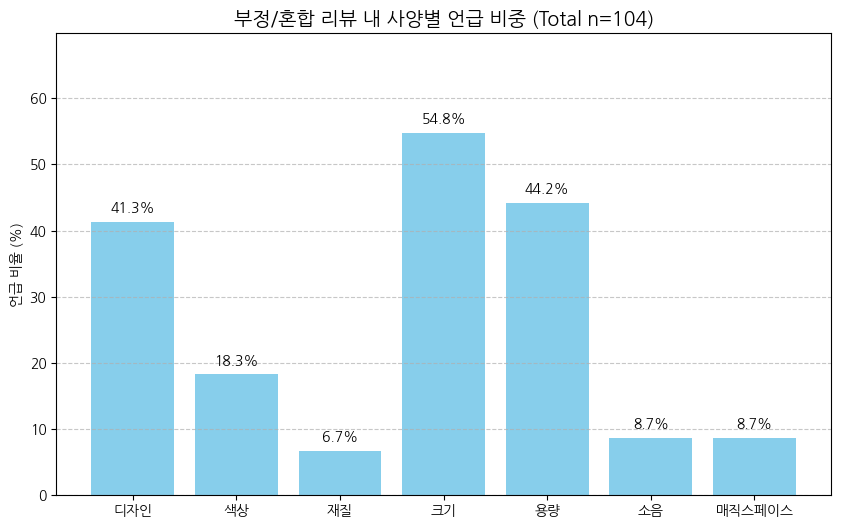

=== 부정 리뷰 중 언급 비중이 높은 사양 샘플 ===
가장 많이 언급된 부정 사양: [크기]
1. 에너지효율등급 1등급이라 그런지 전기세 걱정없이 잘 사용하고 있습니다. 묵직해서 처음엔 불편했는데 내부가 넓고 냉동실도 좌우 구분되어 에너지 절약도 되는갓 같네요 냉장실 벽이 없다...
2. 사용한지 14년이 넘은 본가 냉장고를 바꿔드렸어요. 제품 좋은건 뭐 다 아시는 얘기고, 사기전부터 비슷한 모델이 많아서 차이점 등등 좀 귀찮게 물어봤는데도 최선을 다해서 대응하시는...
3. 16년전 구매한 보석? 박혀있는 LG디오스 냉장고, 고장없이 사용하다가 냉동실 패킹이 문제되어 부품이 없는 관계로 바꾸게 되었네요. 그런데 냉장고 틀에 여유 없이 너무  딱맞아서 ...
4. 깔끔하고 냉장고 성능이 귯굿 기존 사용하던 제품보다 커서 너무 좋구여 신혼가구 13년 쓰고 바꾼거라 만족 합니다 다만 냉장고 맨 위칸이 키170인 여성인데도 맨 위에 안쪽은 조금 ...
5. LG 디오스 냉장고를 써보니 “정리와 보관이 편한 냉장고”라는 느낌이 확실했습니다. 냉장실 수납 구조가 잘 나뉘어 있어 자주 쓰는 반찬이나 음료를 한눈에 찾기 쉽고, 서랍이 부드럽...


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 분석 대상 사양 리스트
spec_cols_vis = ['디자인', '색상', '재질', '크기', '용량', '소음', '매직스페이스']

# 2. 부정/혼합 리뷰(install_neg)에서의 사양 언급 분석
# install_neg에는 이미 CEJ_sentiment가 negative, mixed인 것만 들어있다고 가정
neg_ids = install_neg['review_id'].unique()
subset_neg = text_df[text_df['review_id'].isin(neg_ids)].drop_duplicates('review_id')

# 사양별 언급 비율 계산 (전체 부정 리뷰 수 대비)
total_neg = len(subset_neg)
spec_neg_counts = {}

for spec in spec_cols_vis:
    mentioned_col = f'{spec}_mentioned'
    if mentioned_col in subset_neg.columns:
        count = subset_neg[mentioned_col].sum()
        ratio = (count / total_neg * 100) if total_neg > 0 else 0
        spec_neg_counts[spec] = ratio

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
bars = plt.bar(spec_neg_counts.keys(), spec_neg_counts.values(), color='#87CEEB')

# 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title(f'부정/혼합 리뷰 내 사양별 언급 비중 (Total n={total_neg})', fontsize=14)
plt.ylabel('언급 비율 (%)')
plt.ylim(0, max(spec_neg_counts.values()) + 15) # 여유 공간 확보
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. (추가) 부정 사양 중 실제 원문 확인을 위한 샘플링
print(f"=== 부정 리뷰 중 언급 비중이 높은 사양 샘플 ===")
top_spec = max(spec_neg_counts, key=spec_neg_counts.get)
print(f"가장 많이 언급된 부정 사양: [{top_spec}]")

sample_reviews = subset_neg[subset_neg[f'{top_spec}_mentioned'] == True]['review_text'].sample(min(5, len(subset_neg)))
for i, txt in enumerate(sample_reviews):
    print(f"{i+1}. {txt[:100]}...") # 긴 리뷰는 자름

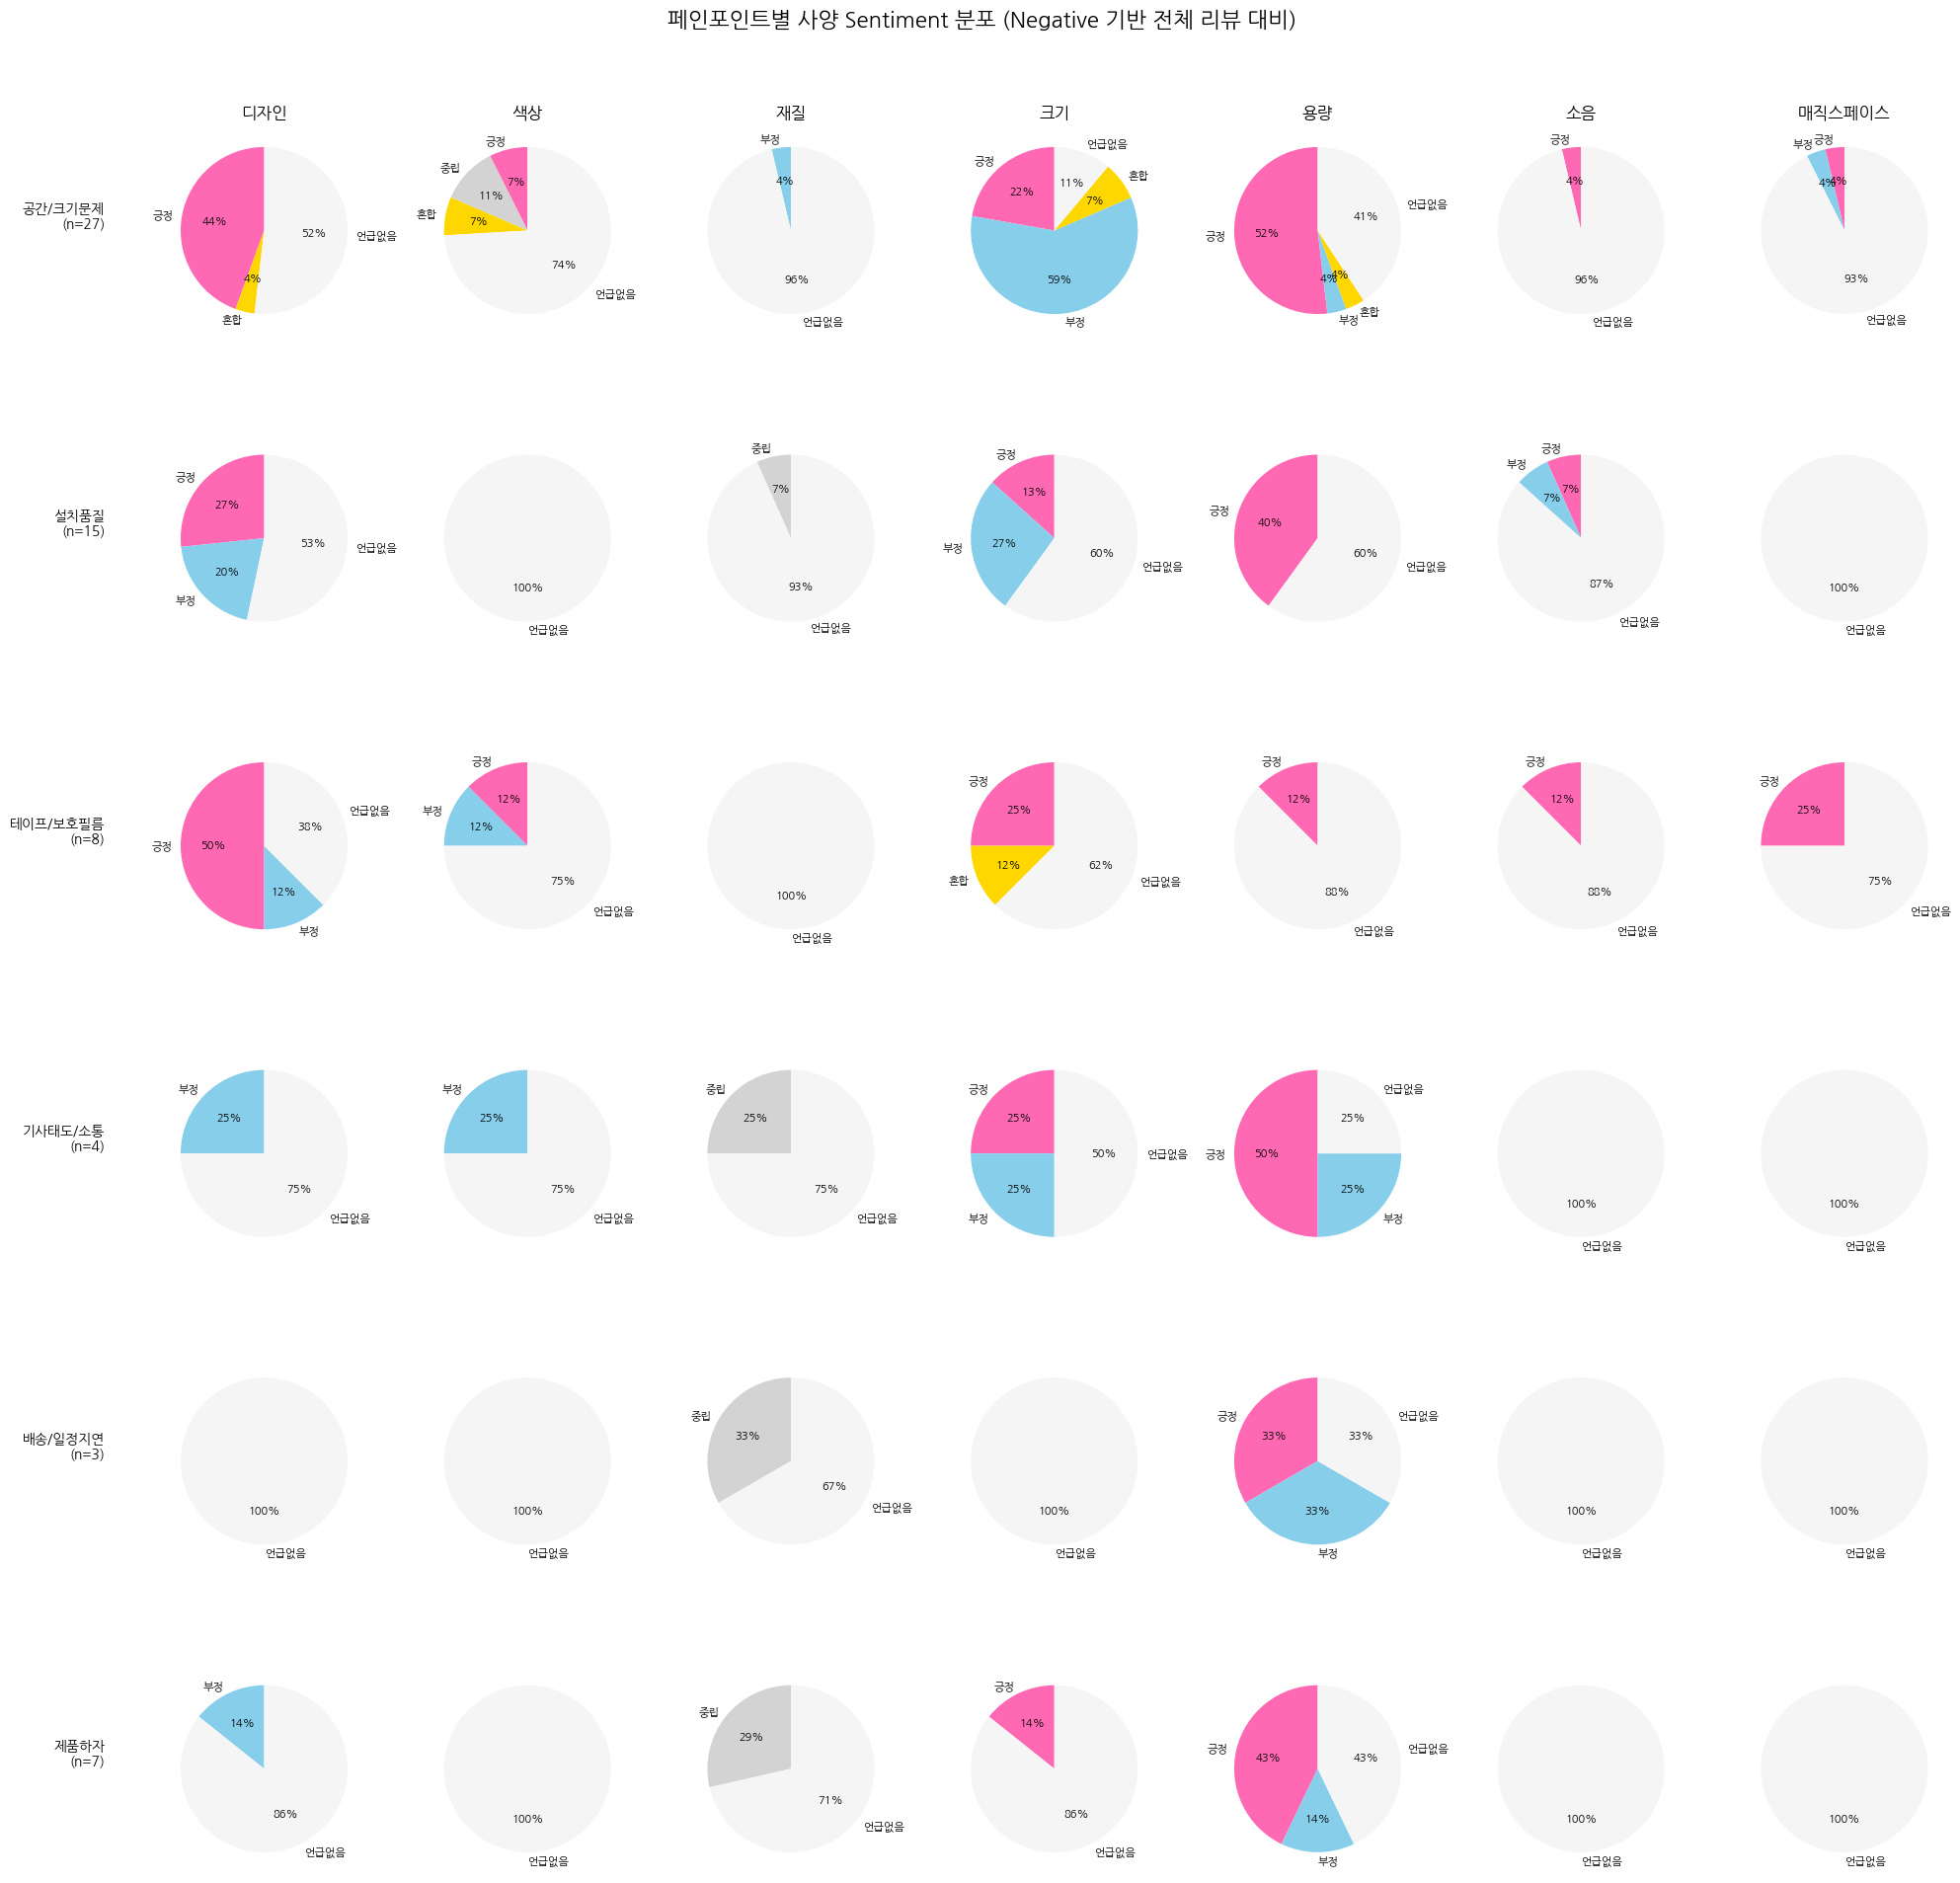

In [ ]:
# =========================
# pain포인트별 사양 sentiment 교차분석
# Negative 기반 pain review만 사용
# =========================

fig, axes = plt.subplots(
    len(PAIN_INSTALL),
    len(spec_cols_vis),
    figsize=(20, 20)
)

fig.suptitle(
    '페인포인트별 사양 Sentiment 분포 (Negative 기반 전체 리뷰 대비)',
    fontsize=16
)


for i, pain_cat in enumerate(PAIN_INSTALL.keys()):

    # negative에서 해당 pain포인트 포함 review_id 추출
    pain_ids = install_neg[
        install_neg["pain_install"].apply(
            lambda x: pain_cat in x if isinstance(x, list) else False
        )
    ]["review_id"].unique()

    # review 단위 중복 제거
    subset = text_df[
        text_df["review_id"].isin(pain_ids)
    ].drop_duplicates("review_id")

    total = len(subset)

    for j, spec in enumerate(spec_cols_vis):

        ax = axes[i][j]

        # 리뷰 없으면 빈칸
        if total == 0:
            ax.axis("off")
            continue

        sentiment_col = f"{spec}_sentiment"
        mentioned_col = f"{spec}_mentioned"

        # 컬럼 없으면 skip
        if sentiment_col not in subset.columns or mentioned_col not in subset.columns:
            ax.axis("off")
            continue

        # sentiment별 count
        pos = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "positive")
        ].shape[0]

        neg = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "negative")
        ].shape[0]

        neu = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "neutral")
        ].shape[0]

        mix = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "mixed")
        ].shape[0]

        not_mentioned = total - pos - neg - neu - mix


        # pie chart 데이터
        values = [pos, neg, neu, mix, not_mentioned]
        labels = ['긍정', '부정', '중립', '혼합', '언급없음']
        colors = ['#FF69B4', '#87CEEB', '#D3D3D3', '#FFD700', '#F5F5F5']


        # 0 제거
        filtered = [
            (v, l, c)
            for v, l, c in zip(values, labels, colors)
            if v > 0
        ]


        # 전부 0이면 언급없음
        if not filtered:
            ax.pie(
                [total],
                labels=['언급없음'],
                colors=['#F5F5F5'],
                autopct='%1.0f%%',
                textprops={'fontsize': 8}
            )

        else:
            v, l, c = zip(*filtered)

            ax.pie(
                v,
                labels=l,
                colors=c,
                autopct='%1.0f%%',
                textprops={'fontsize': 8},
                startangle=90
            )


        # 상단 spec 제목
        if i == 0:
            ax.set_title(
                spec,
                fontsize=12,
                fontweight='bold'
            )


        # 좌측 pain category
        if j == 0:
            ax.set_ylabel(
                f'{pain_cat}\n(n={total})',
                fontsize=10,
                rotation=0,
                labelpad=40,
                ha='right'
            )


plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

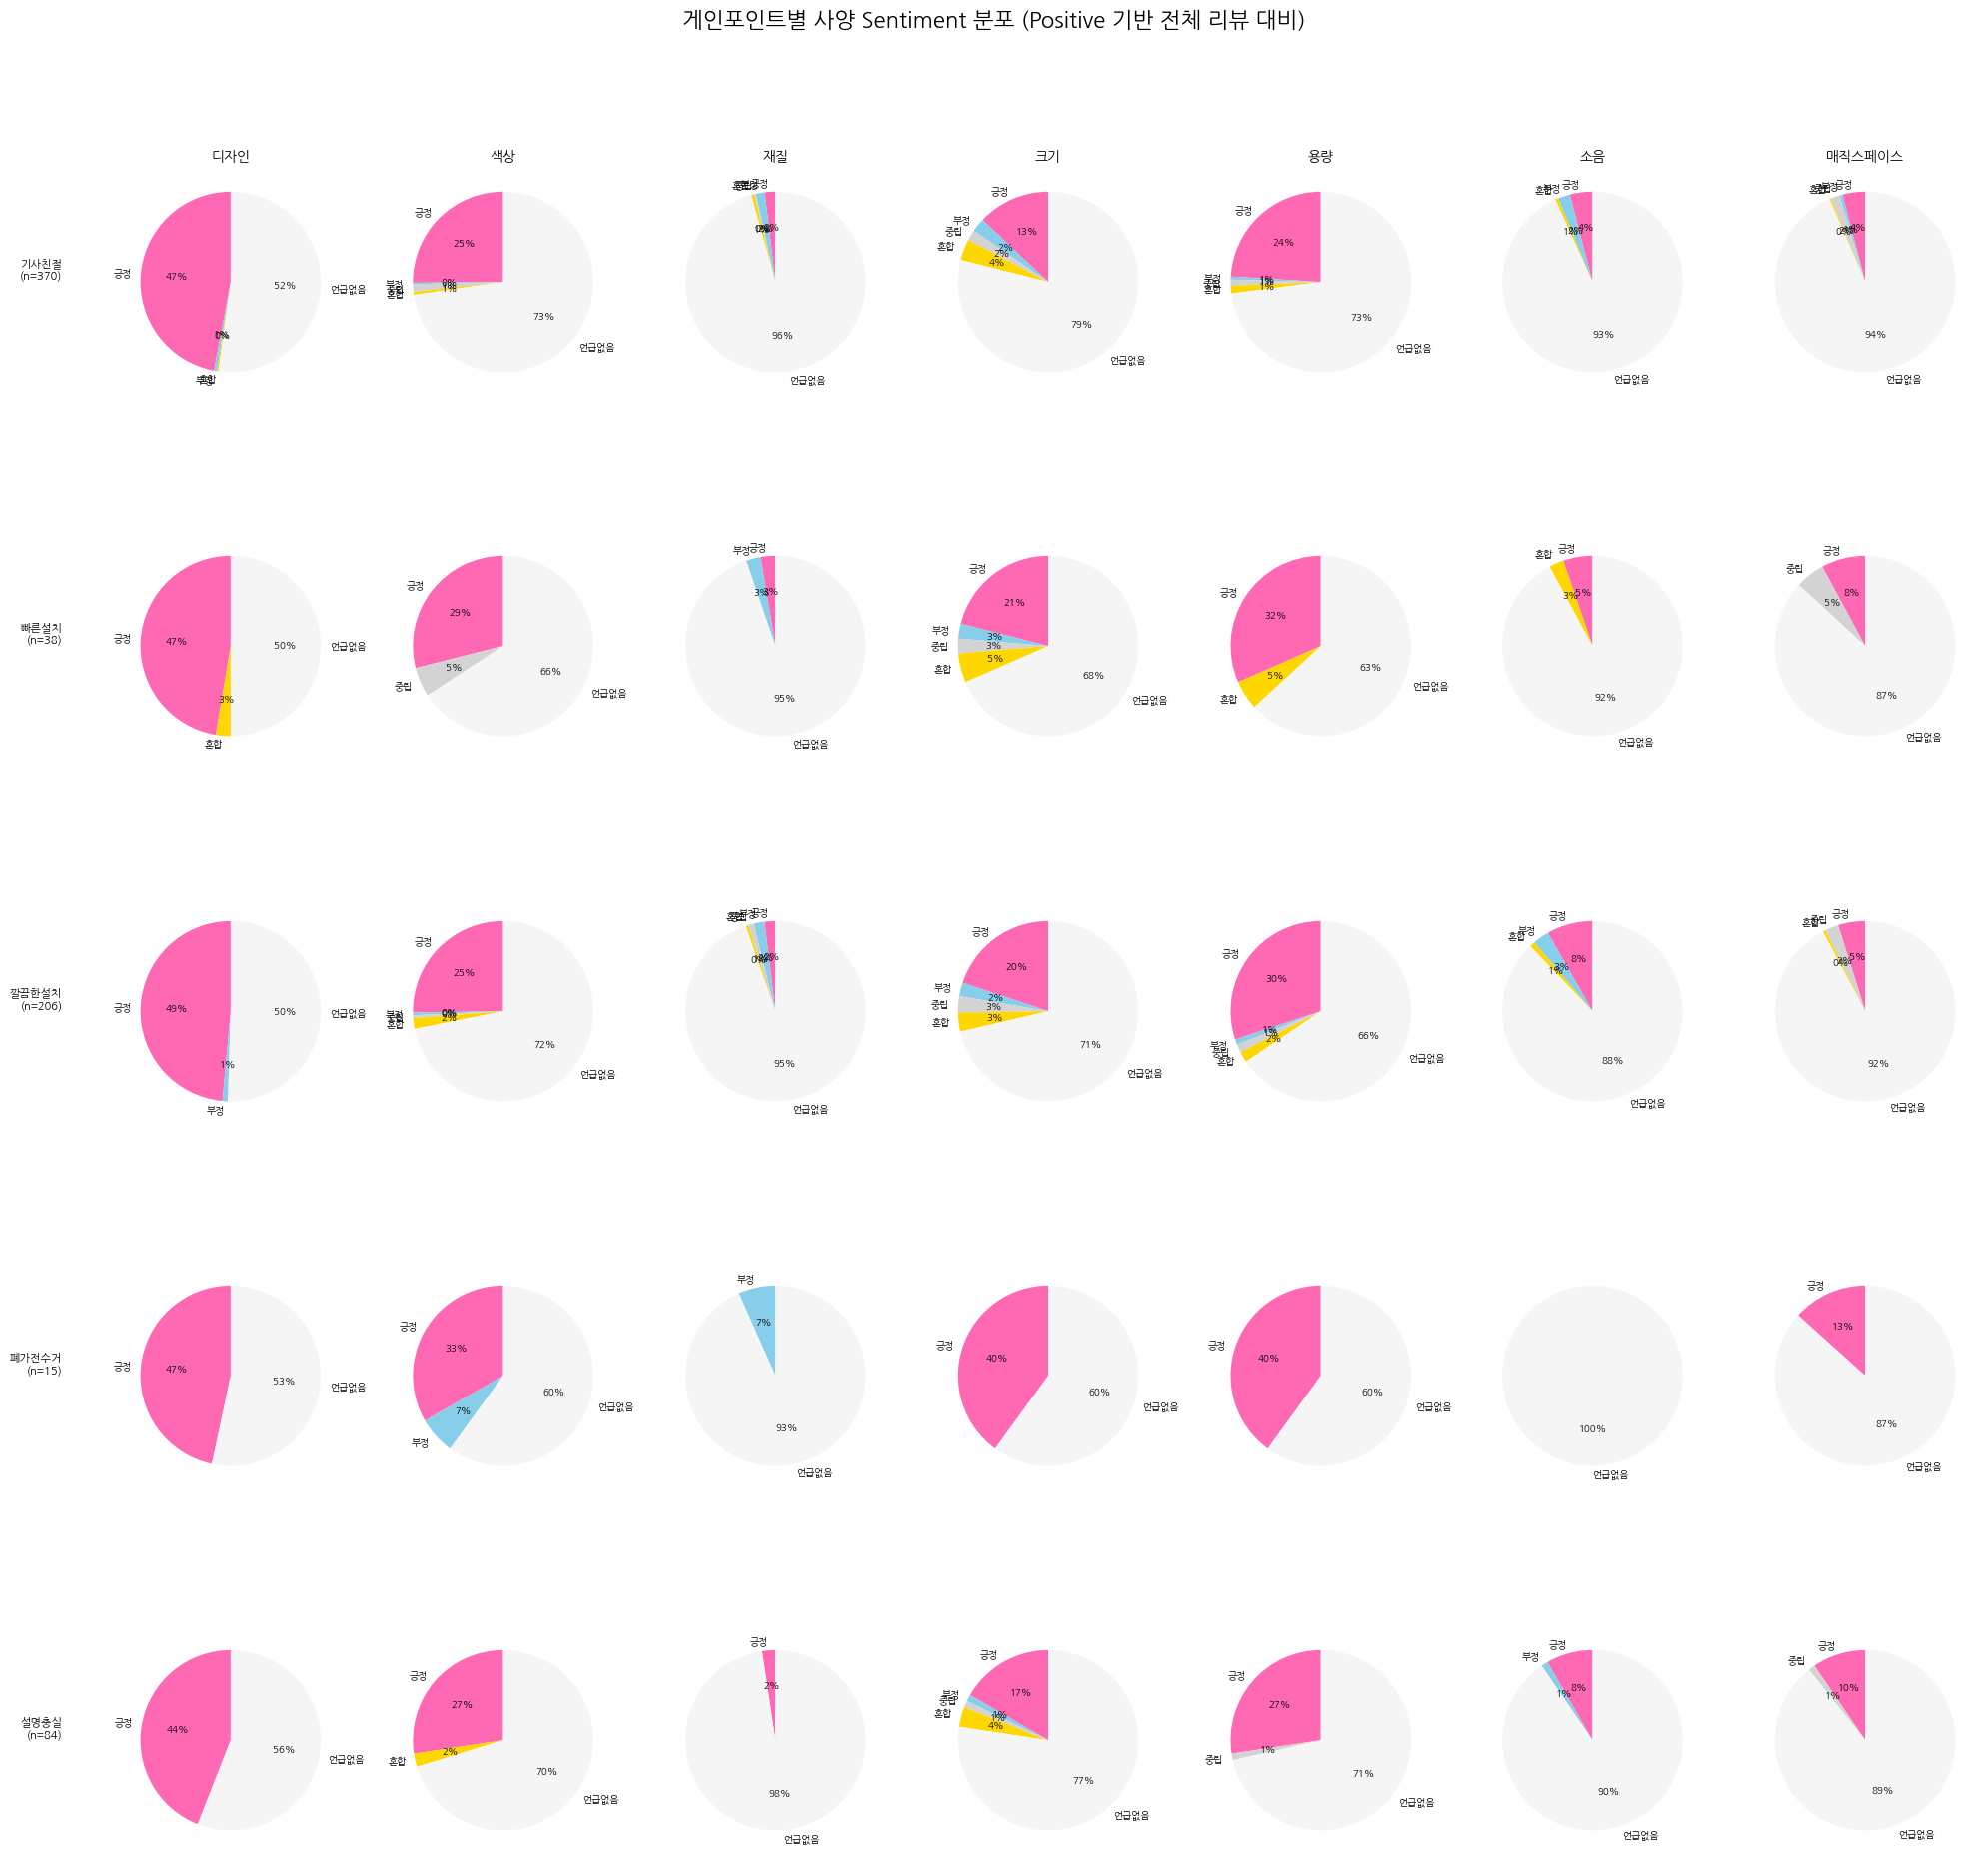

In [ ]:
# =========================
# 게인포인트별 사양 sentiment 교차분석
# Positive 기반 gain review만 사용
# =========================

fig, axes = plt.subplots(
    len(GAIN_INSTALL),
    len(spec_cols_vis),
    figsize=(20, 20)
)

fig.suptitle(
    '게인포인트별 사양 Sentiment 분포 (Positive 기반 전체 리뷰 대비)',
    fontsize=16
)


for i, gain_cat in enumerate(GAIN_INSTALL.keys()):

    # positive에서 해당 gain포인트 포함 review_id 추출
    gain_ids = install_pos[
        install_pos["gain_install"].apply(
            lambda x: gain_cat in x if isinstance(x, list) else False
        )
    ]["review_id"].unique()

    # review 단위 중복 제거
    subset = text_df[
        text_df["review_id"].isin(gain_ids)
    ].drop_duplicates("review_id")

    total = len(subset)

    for j, spec in enumerate(spec_cols_vis):

        ax = axes[i][j]

        # 리뷰 없으면 빈칸
        if total == 0:
            ax.axis("off")
            continue

        sentiment_col = f"{spec}_sentiment"
        mentioned_col = f"{spec}_mentioned"

        # 컬럼 없으면 skip
        if sentiment_col not in subset.columns or mentioned_col not in subset.columns:
            ax.axis("off")
            continue


        # sentiment별 count
        pos = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "positive")
        ].shape[0]

        neg = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "negative")
        ].shape[0]

        neu = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "neutral")
        ].shape[0]

        mix = subset[
            (subset[mentioned_col] == True) &
            (subset[sentiment_col] == "mixed")
        ].shape[0]

        not_mentioned = total - pos - neg - neu - mix


        # pie chart 데이터
        values = [pos, neg, neu, mix, not_mentioned]
        labels = ['긍정', '부정', '중립', '혼합', '언급없음']
        colors = ['#FF69B4', '#87CEEB', '#D3D3D3', '#FFD700', '#F5F5F5']


        # 0 제거
        filtered = [
            (v, l, c)
            for v, l, c in zip(values, labels, colors)
            if v > 0
        ]


        # 전부 0이면 언급없음
        if not filtered:
            ax.pie(
                [total],
                labels=['언급없음'],
                colors=['#F5F5F5'],
                autopct='%1.0f%%',
                textprops={'fontsize': 8}
            )

        else:
            v, l, c = zip(*filtered)

            ax.pie(
                v,
                labels=l,
                colors=c,
                autopct='%1.0f%%',
                textprops={'fontsize': 7},
                startangle=90
            )


        # 상단 spec 제목
        if i == 0:
            ax.set_title(
                spec,
                fontsize=10,
                fontweight='bold'
            )


        # 좌측 gain category
        if j == 0:
            ax.set_ylabel(
                f'{gain_cat}\n(n={total})',
                fontsize=8,
                rotation=0,
                labelpad=40,
                ha='right'
            )


plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [ ]:
# =========================
# '테이프/보호필름' 페인포인트 (Negative 기반) 중
# 디자인 언급 + 디자인 긍정 리뷰 확인
# =========================

target_pain = '테이프/보호필름'

# 1. negative install 리뷰에서 해당 pain 포함 review_id 추출
target_ids = install_neg[
    install_neg["pain_install"].apply(
        lambda x: target_pain in x if isinstance(x, list) else False
    )
]["review_id"].unique()


# 2. text_df에서 디자인 언급 + 디자인 positive
design_positive_reviews = text_df[
    (text_df["review_id"].isin(target_ids)) &
    (text_df["디자인_mentioned"] == True) &
    (text_df["디자인_sentiment"] == "positive")
].drop_duplicates("review_id")


# 3. 결과 출력
print(f"조회된 리뷰 수: {len(design_positive_reviews)}건\n")

for idx, (_, row) in enumerate(
    design_positive_reviews.head(10).iterrows(),
    start=1
):
    print(f"[{idx}] review_id: {row['review_id']}")
    print(row["review_text"])
    print("-" * 50)

조회된 리뷰 수: 4건

[1] review_id: 264613
결혼하며 샀던 냉장고 고장으로 매장에서 구매하려고 상품선택중 웹에서 사는게 더 저렴하여 선택했습니다.냉장고에 비해 집으로 들어올수 있는 모든 문들이 작아 설치기사님께 동영상으로 설치가능한지 미리 보내드리며,노심초사 구매한 냉장고가 설치가 어려워 취소해야될지 걱정이 많았답니다.감사하게도 친절한 설치기사님들께서 베란다창문,방창문,방문까지 떼어내는 번거로움을 감수하시며 예쁘게 설치해 주셔서 너무나 감사했답니다.넓은 공간과 깔끔한 디자인,좋은 성능 만족하며 사용하고 있답니다. 좋은 제품뿐 아니라 친절하신 설치기사님들께 깊이 감사드립니다💕💕💕
--------------------------------------------------
[2] review_id: 242577
아직 본격적으로 사용 전입니다만, 외관이나 설치 서비스는 대만족입니다. 다만 냉장고 안에 보호필름이나 스티커 떼는 데 좀 애먹었습니다. 최고예요~~
--------------------------------------------------
[3] review_id: 365855
제품은 별5개인데 설치과정이 맘에 안들어 별하나 빼요. 15년이상 쓰던 양문형냉장고가 고장나서 급하게 알아보다 딱 맘에 드는 제품 발견..냉동실 얼음 메이커가 엄청 작은거만 빼고 디자인, 가격, 성능, 홈바, 컴프레서 모두 괜찮아서 결정했어요...4도어 냉장고는 처음이라 불편하면 어쩌나 고민 많이 했는데 오히려 냉장실이 가로로 넓어져서 활용도가 훨씬 많고 냉장실을 자주 이용하는 집이라면 훨씨 편하고 좋네요..돌아가는 소리도 아주 조용하고 앱이랑 연결되서 전기요금이랑 이것저것 조절할수 있는 편리함도 좋아요... UP가전이라 기능업그레이드도 가능하고 아주 맘에 들어요..다만 설치기사님들이 설치과정에서  조금 더 조심히 다루어 주었으면 좋겠어요..냉장고 문짝 떼고 집에 들여서 다시 문짝 조립하는 과정에서 문짝에 볼펜으로 그은듯한 기스가 3,4군데 나고 문짝조립되는 볼트있

In [ ]:
# 기사친절 게인포인트 고객 vs 전체 고객 사양 만족도 비교
gain_ids = install_df[
    install_df["gain_install"].apply(lambda x: "기사친절" in x)
]['review_id'].unique()

gain_subset = text_df[text_df['review_id'].isin(gain_ids)].drop_duplicates('review_id')
all_subset = text_df.drop_duplicates('review_id')

print(f"기사친절 게인포인트 고객: {len(gain_subset)}명")
print(f"전체 고객: {len(all_subset)}명")

print("\n=== 사양별 긍정률 비교 ===")
print(f"{'사양':<12} {'기사친절고객':>12} {'전체고객':>10} {'차이':>8}")
print("-"*45)

for spec in ['디자인', '색상', '크기', '용량', '소음']:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    if mentioned_col not in gain_subset.columns:
        continue

    # 기사친절 고객
    g_total = gain_subset[gain_subset[mentioned_col]==True].shape[0]
    g_pos = gain_subset[(gain_subset[mentioned_col]==True) & (gain_subset[sentiment_col]=='positive')].shape[0]
    g_rate = g_pos/g_total*100 if g_total > 0 else 0

    # 전체 고객
    a_total = all_subset[all_subset[mentioned_col]==True].shape[0]
    a_pos = all_subset[(all_subset[mentioned_col]==True) & (all_subset[sentiment_col]=='positive')].shape[0]
    a_rate = a_pos/a_total*100 if a_total > 0 else 0

    diff = g_rate - a_rate
    direction = "↑" if diff > 0 else "↓"
    print(f"{spec:<12} {g_rate:>10.1f}% {a_rate:>9.1f}% {direction}{abs(diff):>5.1f}%p")

기사친절 게인포인트 고객: 371명
전체 고객: 2827명

=== 사양별 긍정률 비교 ===
사양                 기사친절고객       전체고객       차이
---------------------------------------------
디자인                98.3%      97.2% ↑  1.1%p
색상                 92.1%      88.4% ↑  3.7%p
크기                 61.5%      76.2% ↓ 14.6%p
용량                 89.0%      93.0% ↓  4.0%p
소음                 60.0%      76.2% ↓ 16.2%p


In [ ]:
# 설치 단계 부정 vs 설치 전체 사양 비교
install_neg_subset = install_df[
    install_df['CEJ_sentiment'].isin(['negative', 'mixed'])
].drop_duplicates('review_id')

install_all_subset = install_df.drop_duplicates('review_id')

print(f"설치 부정 리뷰: {len(install_neg_subset)}명")
print(f"설치 전체 리뷰: {len(install_all_subset)}명")

print(f"\n{'사양':<12} {'부정리뷰':>10} {'전체리뷰':>10} {'차이':>8}")
print("-"*45)

for spec in ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    if mentioned_col not in install_neg_subset.columns:
        continue

    neg_ids = install_neg_subset['review_id'].unique()
    all_ids = install_all_subset['review_id'].unique()

    # 부정 리뷰 사양 긍정률
    neg_spec = text_df[text_df['review_id'].isin(neg_ids)].drop_duplicates('review_id')
    neg_total = neg_spec[neg_spec[mentioned_col]==True].shape[0]
    neg_pos = neg_spec[
        (neg_spec[mentioned_col]==True) &
        (neg_spec[sentiment_col]=='positive')
    ].shape[0]
    neg_rate = neg_pos/neg_total*100 if neg_total > 0 else 0

    # 전체 리뷰 사양 긍정률
    all_spec = text_df[text_df['review_id'].isin(all_ids)].drop_duplicates('review_id')
    all_total = all_spec[all_spec[mentioned_col]==True].shape[0]
    all_pos = all_spec[
        (all_spec[mentioned_col]==True) &
        (all_spec[sentiment_col]=='positive')
    ].shape[0]
    all_rate = all_pos/all_total*100 if all_total > 0 else 0

    diff = neg_rate - all_rate
    direction = "↑" if diff > 0 else "↓"
    print(f"{spec:<12} {neg_rate:>9.1f}% {all_rate:>9.1f}% {direction}{abs(diff):>5.1f}%p")

설치 부정 리뷰: 116명
설치 전체 리뷰: 966명

사양                 부정리뷰       전체리뷰       차이
---------------------------------------------
디자인               81.6%      96.7% ↓ 15.0%p
색상                42.3%      86.7% ↓ 44.4%p
재질                33.3%      48.4% ↓ 15.1%p
크기                19.4%      63.8% ↓ 44.4%p
용량                76.4%      90.1% ↓ 13.8%p
소음                45.5%      67.9% ↓ 22.4%p
오토클로징             60.0%      79.3% ↓ 19.3%p
매직스페이스            66.7%      74.2% ↓  7.5%p
ThinQ             80.0%      96.3% ↓ 16.3%p


In [ ]:
install_neg_subset = install_df[
    install_df['CEJ_sentiment'].isin(['negative', 'mixed'])
].drop_duplicates('review_id')

install_all_subset = install_df.drop_duplicates('review_id')

print(f"설치 부정 리뷰: {len(install_neg_subset)}명")
print(f"설치 전체 리뷰: {len(install_all_subset)}명")

print(f"\n{'사양':<12} {'부정리뷰':>10} {'전체리뷰':>10} {'차이':>8}")
print("-"*45)

for spec in ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']:

    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    if mentioned_col not in install_neg_subset.columns:
        continue

    neg_ids = install_neg_subset['review_id'].unique()
    all_ids = install_all_subset['review_id'].unique()

    # 설치 부정 고객의 사양 부정률
    neg_spec = text_df[text_df['review_id'].isin(neg_ids)].drop_duplicates('review_id')
    neg_total = neg_spec[neg_spec[mentioned_col] == True].shape[0]
    neg_negative = neg_spec[
        (neg_spec[mentioned_col] == True) &
        (neg_spec[sentiment_col] == 'negative')
    ].shape[0]

    neg_rate = neg_negative / neg_total * 100 if neg_total > 0 else 0

    # 설치 전체 고객의 사양 부정률
    all_spec = text_df[text_df['review_id'].isin(all_ids)].drop_duplicates('review_id')
    all_total = all_spec[all_spec[mentioned_col] == True].shape[0]
    all_negative = all_spec[
        (all_spec[mentioned_col] == True) &
        (all_spec[sentiment_col] == 'negative')
    ].shape[0]

    all_rate = all_negative / all_total * 100 if all_total > 0 else 0

    diff = neg_rate - all_rate
    direction = "↑" if diff > 0 else "↓"

    print(f"{spec:<12} {neg_rate:>9.1f}% {all_rate:>9.1f}% {direction}{abs(diff):>5.1f}%p")

설치 부정 리뷰: 116명
설치 전체 리뷰: 966명

사양                 부정리뷰       전체리뷰       차이
---------------------------------------------
디자인               12.2%       1.8% ↑ 10.5%p
색상                11.5%       1.8% ↑  9.8%p
재질                22.2%      26.6% ↓  4.3%p
크기                50.7%      15.0% ↑ 35.7%p
용량                18.2%       4.8% ↑ 13.4%p
소음                54.5%      22.6% ↑ 31.9%p
오토클로징             40.0%       6.9% ↑ 33.1%p
매직스페이스            25.0%       5.6% ↑ 19.4%p
ThinQ             20.0%       3.7% ↑ 16.3%p


In [ ]:
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1, 'mixed': -0.5}

spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

print("=== CEJ 단계별 사양 CS 점수 ===")
print(f"{'사양':<12} {'구매':>8} {'설치':>8} {'사용':>8}")
print("-"*40)

for spec in spec_cols:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    scores = []
    for stage in ['구매', '설치', '사용']:
        subset = text_df[
            text_df['CEJ_stage'] == stage
        ].drop_duplicates('review_id')

        attention = subset[mentioned_col].sum() / len(subset)
        score = subset[subset[mentioned_col]==True][sentiment_col].map(sentiment_map).mean()

        if pd.isna(score):
            scores.append('N/A')
        else:
            cs = round(attention * score, 3)
            scores.append(cs)

    print(f"{spec:<12} {str(scores[0]):>8} {str(scores[1]):>8} {str(scores[2]):>8}")

=== CEJ 단계별 사양 CS 점수 ===
사양                 구매       설치       사용
----------------------------------------
디자인             0.427    0.442    0.485
색상              0.209    0.242     0.22
재질              0.008     0.01    0.012
크기              0.126    0.142    0.167
용량              0.256    0.289    0.304
소음              0.032    0.035    0.052
오토클로징           0.025     0.02    0.028
매직스페이스           0.07    0.065    0.077
ThinQ           0.026    0.026    0.027


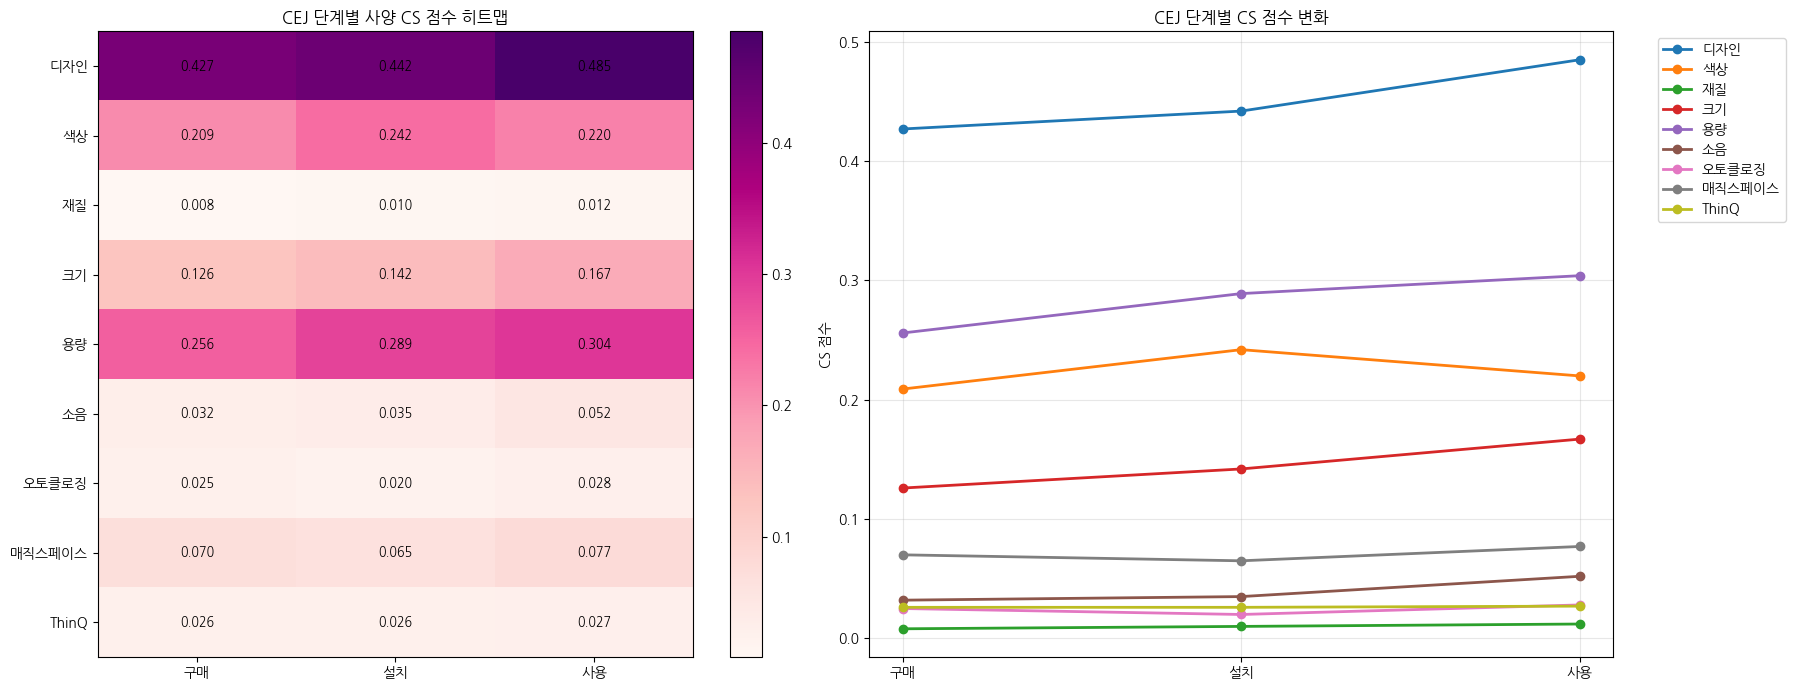

In [ ]:
import numpy as np

cs_data = {
    '디자인':     [0.427, 0.442, 0.485],
    '색상':       [0.209, 0.242, 0.220],
    '재질':       [0.008, 0.010, 0.012],
    '크기':       [0.126, 0.142, 0.167],
    '용량':       [0.256, 0.289, 0.304],
    '소음':       [0.032, 0.035, 0.052],
    '오토클로징':  [0.025, 0.020, 0.028],
    '매직스페이스': [0.070, 0.065, 0.077],
    'ThinQ':     [0.026, 0.026, 0.027]
}

cs_df = pd.DataFrame(cs_data, index=['구매', '설치', '사용']).T

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. 히트맵
im = axes[0].imshow(cs_df.values, cmap='RdPu', aspect='auto')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['구매', '설치', '사용'])
axes[0].set_yticks(range(len(cs_df)))
axes[0].set_yticklabels(cs_df.index)
axes[0].set_title('CEJ 단계별 사양 CS 점수 히트맵')
for i in range(len(cs_df)):
    for j in range(3):
        axes[0].text(j, i, f'{cs_df.values[i,j]:.3f}',
                    ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0])

# 2. 라인차트 (단계별 변화)
for spec in cs_df.index:
    axes[1].plot(['구매', '설치', '사용'], cs_df.loc[spec],
                marker='o', label=spec, linewidth=2)
axes[1].set_title('CEJ 단계별 CS 점수 변화')
axes[1].set_ylabel('CS 점수')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# 색상: 설치 vs 사용 단계 만족도 차이 검정
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1, 'mixed': -0.5}

for spec in ['색상', '오토클로징', '매직스페이스']:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    install_scores = text_df[
        (text_df['CEJ_stage'] == '설치') &
        (text_df[mentioned_col] == True)
    ][sentiment_col].map(sentiment_map).dropna()

    use_scores = text_df[
        (text_df['CEJ_stage'] == '사용') &
        (text_df[mentioned_col] == True)
    ][sentiment_col].map(sentiment_map).dropna()

    if len(install_scores) < 5 or len(use_scores) < 5:
        continue

    stat, p = stats.mannwhitneyu(install_scores, use_scores, alternative='two-sided')
    sig = "✅ 유의미" if p < 0.05 else "❌ 유의미하지 않음"

    print(f"\n[{spec}] 설치 vs 사용")
    print(f"  설치 평균: {install_scores.mean():.3f} (n={len(install_scores)})")
    print(f"  사용 평균: {use_scores.mean():.3f} (n={len(use_scores)})")
    print(f"  p-value: {p:.4f} → {sig}")



[색상] 설치 vs 사용
  설치 평균: 0.793 (n=437)
  사용 평균: 0.844 (n=1648)
  p-value: 0.0528 → ❌ 유의미하지 않음

[오토클로징] 설치 vs 사용
  설치 평균: 0.574 (n=54)
  사용 평균: 0.749 (n=289)
  p-value: 0.1030 → ❌ 유의미하지 않음

[매직스페이스] 설치 vs 사용
  설치 평균: 0.686 (n=140)
  사용 평균: 0.809 (n=690)
  p-value: 0.0049 → ✅ 유의미


In [ ]:
from scipy import stats

sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1, 'mixed': -0.5}

spec_cols = ['디자인', '색상', '재질', '크기', '용량', '소음',
             '오토클로징', '매직스페이스', 'ThinQ']

stage_pairs = [('구매', '설치'), ('설치', '사용'), ('구매', '사용')]

print(f"{'사양':<12} {'구매vs설치':>15} {'설치vs사용':>15} {'구매vs사용':>15}")
print("-"*60)

for spec in spec_cols:
    mentioned_col = f'{spec}_mentioned'
    sentiment_col = f'{spec}_sentiment'

    results = []
    for stage1, stage2 in stage_pairs:
        s1 = text_df[
            (text_df['CEJ_stage'] == stage1) &
            (text_df[mentioned_col] == True)
        ][sentiment_col].map(sentiment_map).dropna()

        s2 = text_df[
            (text_df['CEJ_stage'] == stage2) &
            (text_df[mentioned_col] == True)
        ][sentiment_col].map(sentiment_map).dropna()

        if len(s1) < 5 or len(s2) < 5:
            results.append('N/A')
            continue

        stat, p = stats.mannwhitneyu(s1, s2, alternative='two-sided')
        sig = "✅" if p < 0.05 else "❌"
        results.append(f"{sig} p={p:.3f}")

    print(f"{spec:<12} {results[0]:>15} {results[1]:>15} {results[2]:>15}")

사양                    구매vs설치          설치vs사용          구매vs사용
------------------------------------------------------------
디자인                ❌ p=0.389       ✅ p=0.033       ❌ p=0.177
색상                 ❌ p=0.923       ❌ p=0.053       ✅ p=0.026
재질                 ❌ p=0.988       ✅ p=0.030       ✅ p=0.005
크기                 ✅ p=0.003       ✅ p=0.000       ✅ p=0.002
용량                 ❌ p=0.882       ❌ p=0.051       ✅ p=0.030
소음                 ❌ p=0.929       ✅ p=0.001       ✅ p=0.000
오토클로징              ❌ p=0.236       ❌ p=0.103       ❌ p=0.705
매직스페이스             ❌ p=0.495       ✅ p=0.005       ✅ p=0.009
ThinQ              ❌ p=0.303       ✅ p=0.016       ❌ p=0.224


---

In [ ]:
# 구매 단계만 필터링
buy_df = text_df[text_df['CEJ_stage'] == '구매'].copy()
print(f"구매 단계 행 수: {len(buy_df)}")
print(f"구매 단계 unique 리뷰 수: {buy_df['review_id'].nunique()}")

# CEJ_item 분포
print("\n=== 구매 단계 CEJ_item 분포 ===")
print(buy_df['CEJ_item'].value_counts().head(20))

# 구매 이유 관련 evidence 보기
print("\n=== 구매 결정 관련 evidence ===")
buy_reason = buy_df[buy_df['CEJ_item'].isin(['구매결정', '구매이유', '교체이유', '구매동기'])]
for text in buy_reason['CEJ_evidence'].dropna().head(20):
    print(f"- {text}")

구매 단계 행 수: 2751
구매 단계 unique 리뷰 수: 1768

=== 구매 단계 CEJ_item 분포 ===
CEJ_item
구매결정     917
가격       386
배송       231
구입       107
가성비       95
구매        69
AS기대감     44
만족        35
환급        29
용량        26
색상        21
교체        19
LG        15
할인        15
추천        14
디자인       13
선물        13
1등급       11
AS        10
구매만족       9
Name: count, dtype: int64

=== 구매 결정 관련 evidence ===
- 급하게 구입했습니다
- 제가 선택한 냉장고입니다
- 마음 편하게 공홈에서 구매하세요
- 발견했네요
- 질렀어요
- 구매하게 됬어요
- 가감없이 바꾸었습니다
- LG냉장고가 디자인이나 성능면에서 나은거 같아 선택하게 됐습니다
- 잘 선택한건 같습니다
- 14년만에 구입이라 너무 좋으네요
- 바로 엘지 전자 구매 어플 받았어요
- LG로 사야겠다 생각하여
- 그냥 믿고 엘지닷컴으로 주문했어요
- 주문하게 되었습니다
- 정말 적당한 기회에 좋은 제품 만나서 잘 바꿨습니다
- 너무 만족한 구매입니다
- 구매하였는데
- 가성비 제품으로 좋은것 같습니다
- 기존 LG냉장고가 수명을 다하여 바꾸었습니다
- 라이브방송때 구매
